<a href="https://colab.research.google.com/github/niradaa-art/Project_252-4/blob/main/252_4_Pandas_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###นางสาว ณิรดา อนุนิวัฒน์ 673020252-4

# SC 663 402 Data Warehouse and Big Data Analytics
## แบบฝึกทบทวน pandas

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### วัตถุประสงค์

การบ้านชุดนี้มีวัตถุประสงค์เพื่อทบทวนความรู้ pandas ที่นักศึกษาเคยศึกษามาแล้ว ให้อยู่ในระดับที่พร้อมสำหรับการวิเคราะห์ข้อมูลขนาดใหญ่ในรายวิชานี้
เนื้อหาครอบคลุมตั้งแต่โครงสร้างข้อมูลพื้นฐาน การเลือกและกรองข้อมูล การสรุปข้อมูลด้วย `groupby` การรวมตารางหลายตาราง จนถึงการสร้างกราฟจาก DataFrame

### รูปแบบ

แต่ละหัวข้อประกอบด้วยสองส่วน

1. **ตัวอย่าง** เป็นเซลล์โค้ดที่รันได้ทันที มีไว้เพื่อทบทวนรูปแบบการเรียกใช้คำสั่ง นักศึกษาควรรันและสังเกตผลลัพธ์ก่อนทำโจทย์
2. **โจทย์** เป็นแบบฝึกหัดที่มีระดับความยากสูงกว่าตัวอย่าง ไม่มีเฉลย นักศึกษาต้องเขียนคำตอบเองในเซลล์ที่เตรียมไว้

### ข้อกำหนดในการทำและการส่ง

1. เขียนคำตอบในเซลล์ที่เตรียมไว้ใต้โจทย์แต่ละข้อ
2. โจทย์ที่ระบุคำว่า **อธิบาย** ต้องตอบเป็นข้อความ การส่งเฉพาะโค้ดจะไม่ได้คะแนนในส่วนนั้น
3. ห้ามกำหนดคำตอบเป็นค่าคงที่ ทุกตัวเลขที่รายงานต้องคำนวณจากข้อมูล
4. ให้เขียนโปรแกรมในรูปแบบ vectorized เป็นหลัก หากจำเป็นต้องใช้การวนซ้ำทีละแถว ให้ระบุเหตุผลกำกับ
5. ก่อนส่งให้เลือกคำสั่ง Restart & Run All และตรวจสอบว่าไฟล์ทำงานได้ตลอดทั้งไฟล์
6. ส่งไฟล์ในรูปแบบ `.ipynb` ด้วยลิ้งก์ใน GitHub ของตนเอง

### เกณฑ์การประเมิน

* ความเรียบร้อย ครบถ้วน และความสามารถในการรันซ้ำได้

---
## ส่วนที่ 0 import libraries และ เตรียมข้อมูล

ชุดข้อมูลที่ใช้ประกอบด้วย 3 ตาราง ได้แก่ ข้อมูลสภาพอากาศรายวัน ข้อมูลเมือง และข้อมูลภูมิภาค
ให้รันเซลล์ต่อไปนี้เพื่อโหลดข้อมูลก่อนเริ่มทำการบ้าน

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-thai-tlwg is already the newest version (1:0.7.3-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!


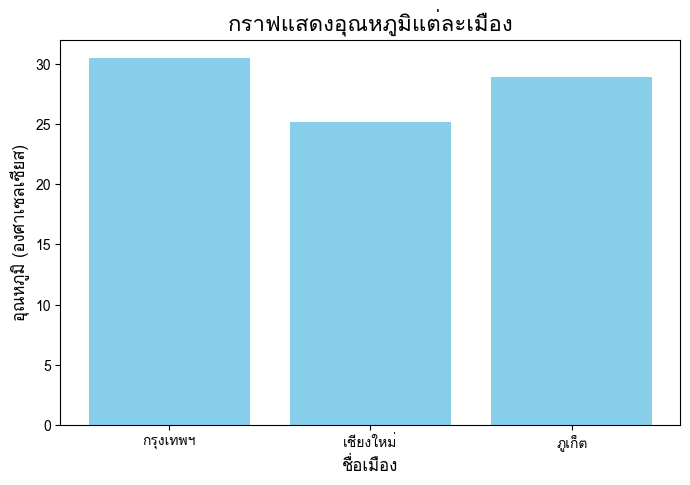

In [124]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}
df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

plt.figure(figsize=(8, 5))
plt.bar(df_thai['เมือง'], df_thai['อุณหภูมิ'], color='skyblue')
plt.title('กราฟแสดงอุณหภูมิแต่ละเมือง', fontsize=16)
plt.xlabel('ชื่อเมือง', fontsize=12)
plt.ylabel('อุณหภูมิ (องศาเซลเซียส)', fontsize=12)
plt.show()

In [125]:
import pandas as pd
import numpy as np

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

print("weather:", df.shape, " city_info:", city_info.shape, " region_info:", region_info.shape)
df.head()

weather: (2075, 10)  city_info: (23, 5)  region_info: (6, 3)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1


---
## ข้อ 1 การเปรียบเทียบคำสั่งที่มีลักษณะใกล้เคียงกัน

**คำสั่ง:** ให้นักศึกษารันเซลล์โค้ดทั้ง 6 เซลล์ต่อไปนี้ สังเกตผลลัพธ์ที่ได้ แล้วอธิบายกับตนเองให้เข้าใจความแตกต่างของคำสั่งในแต่ละเซลล์ พร้อมระบุว่าในทางปฏิบัติควรเลือกใช้คำสั่งใดในสถานการณ์ใด

การอธิบายควรครอบคลุมทั้ง **ชนิดของผลลัพธ์** **รูปร่างของผลลัพธ์** และ **ความหมายของค่าที่ได้**

In [126]:
# เซลล์ 1.1
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(s["a"])
print(s.iloc[0])
print(s[["a", "c"]])

10
10
a    10
c    30
dtype: int64


#### ตอบข้อ 1.1
`s["a"]` เป็นการเลือกข้อมูลโดยอ้างอิงจาก label ของ index จึงได้ค่า 10 ส่วน `s.iloc[0]` เป็นการเลือกข้อมูลตามตำแหน่ง โดยตำแหน่งที่ 0 คือข้อมูลตัวแรก จึงได้ค่า 10 เช่นกัน ส่วน s`[["a", "c"]]` เป็นการเลือกข้อมูลหลายรายการโดยใช้ `label` และผลลัพธ์เป็น `Series`

ในทางปฏิบัติ ควรใช้การเลือกด้วย label เมื่อต้องการเข้าถึงข้อมูลจากชื่อ `index` และใช้ `.iloc[]` เมื่อต้องการเลือกข้อมูลตามตำแหน่งของข้อมูล

In [127]:
# เซลล์ 1.2
print(type(df["city"]), df["city"].shape)
print(type(df[["city"]]), df[["city"]].shape)

<class 'pandas.core.series.Series'> (2075,)
<class 'pandas.core.frame.DataFrame'> (2075, 1)


#### ตอบข้อ 1.2
 คำสั่ง `df["city"]` จะเลือกคอลัมน์ city ออกมาเป็นชนิดข้อมูล Series จึงมีขนาด `(2075,)` ซึ่งเป็นข้อมูลหนึ่งมิติ ส่วนคำสั่ง df`[["city"]]` จะเลือกคอลัมน์ `city` ออกมาเป็นชนิดข้อมูล `DataFrame` จึงมีขนาด `(2075, 1)` ซึ่งเป็นข้อมูลสองมิติ แม้ว่าจะเลือกคอลัมน์เดียวกัน แต่โครงสร้างข้อมูลที่ได้แตกต่างกัน การใช้ `df["city"]` เหมาะกับการนำคอลัมน์เดียวไปประมวลผล ส่วน df`[["city"]]` เหมาะเมื่อ ต้องการคงรูปแบบตาราง `DataFrame` ไว้สำหรับการประมวลผลข้อมูลต่อไป

In [128]:
# เซลล์ 1.3
print(df.loc[0:3].shape)
print(df.iloc[0:3].shape)

(4, 10)
(3, 10)


#### ตอบข้อ 1.3
 คำสั่ง `df.loc[0:3] และ df.iloc[0:3]` แตกต่างกันที่วิธีการเลือกแถว โดย loc ใช้ label ของ index ในการเลือกข้อมูล และช่วง `0:3` จะรวม `index 3` ด้วย จึงได้ข้อมูล 4 แถว ทำให้มีขนาด `(4, 10)` ส่วน `iloc` ใช้ตำแหน่งของข้อมูลในการเลือก และช่วง `0:3` จะไม่รวมตำแหน่งที่ 3 ตามหลักการ `slice` ของ Python จึงได้ข้อมูล 3 แถว ทำให้มีขนาด `(3, 10)`

In [129]:
# เซลล์ 1.4
print(df.groupby("city")["temperature_c"].count().head(3))
print(df.groupby("city").size().head(3))

city
Auckland    90
Bangkok     91
Beijing     89
Name: temperature_c, dtype: int64
city
Auckland    90
Bangkok     91
Beijing     90
dtype: int64


#### ตอบข้อ 1.4
`df.groupby("city")["temperature_c"].count()` จะนับจำนวนค่าที่ไม่เป็นค่าว่างของคอลัมน์ `temperature_c` ในแต่ละเมือง ดังนั้นถ้ามีค่า `temperature_c` ที่เป็นค่าว่าง จำนวนที่นับได้จะไม่รวมแถวนั้น

ส่วนคำสั่ง `df.groupby("city").size()` จะนับจำนวนแถวทั้งหมดในแต่ละกลุ่ม โดยไม่สนใจว่าค่าใน `temperature_c` จะเป็นค่าว่างหรือไม่ จากผลลัพธ์พบว่า `Beijing มีค่า count() เท่ากับ 89` แต่ `size() เท่ากับ 90` แสดงว่ามีข้อมูลจำนวน 1 แถวที่ค่า temperature_c เป็นค่าว่าง

การใช้งานจริง `count()` เหมาะสำหรับตรวจสอบจำนวนข้อมูลที่มีค่าจริงและไม่เป็นค่าว่าง ส่วน `size()` เหมาะสำหรับนับจำนวนระเบียนหรือจำนวนแถวทั้งหมดในแต่ละกลุ่ม

In [130]:
# เซลล์ 1.5
print(df.groupby("city")["temperature_c"].mean().head(3))
print(df.groupby("city")[["temperature_c"]].mean().head(3))

city
Auckland    17.804444
Bangkok     32.453846
Beijing     15.598876
Name: temperature_c, dtype: float64
          temperature_c
city                   
Auckland      17.804444
Bangkok       32.453846
Beijing       15.598876


#### ตอบข้อ 1.5
คำสั่ง `df.groupby("city")["temperature_c"].mean()` จะเลือกคอลัมน์ `temperature_c เป็น Series` แล้วคำนวณค่าเฉลี่ยของอุณหภูมิในแต่ละเมือง จึงได้ผลลัพธ์เป็น Series

ส่วนคำสั่ง `df.groupby("city")[["temperature_c"]].mean()` จะเลือกคอลัมน์ `temperature_c เป็น DataFrame` แล้วคำนวณค่าเฉลี่ยเช่นเดียวกัน จึงได้ผลลัพธ์เป็น DataFrame ที่มี 1 คอลัมน์

ดังนั้นค่าที่คำนวณได้จากทั้งสองคำสั่งมีค่าเท่ากัน แต่ชนิดและโครงสร้างของผลลัพธ์แตกต่างกัน โดยแบบแรกเหมาะกับการนำข้อมูลคอลัมน์เดียวไปใช้งานในรูปแบบ Series ส่วนแบบที่สองเหมาะกับการใช้งานที่ต้องการคงโครงสร้างข้อมูลแบบ DataFrame เช่น การนำไปประมวลผลร่วมกับหลายคอลัมน์ในขั้นตอนต่อไป

In [131]:
# เซลล์ 1.6
a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])
print(a + b)
print(a.to_numpy() + b.to_numpy())

x    31
y    22
z    13
dtype: int64
[11 22 33]


#### ตอบข้อ 1.6
 เมื่อใช้ `a + b` ซึ่งเป็น `Series ของ pandas` การคำนวณจะจับคู่ข้อมูลตามค่า `index ที่ตรงกัน` ไม่ได้จับคู่ตามตำแหน่ง ดังนั้น `x จะคำนวณเป็น 1 + 30 = 31`, `y เป็น 2 + 20 = 22` และ `z เป็น 3 + 10 = 13` จึงได้ผลลัพธ์เป็น `Series ที่มีค่า [31, 22, 13]` ตามลำดับของ index

ส่วน `a.to_numpy() + b.to_numpy()` จะเปลี่ยน `Series เป็น NumPy array` ทำให้ไม่สนใจ index และคำนวณข้อมูลตามตำแหน่ง จึงได้ `[11, 22, 33]`

ความแตกต่างนี้มีประโยชน์เมื่อทำงานกับข้อมูล pandas ที่มี index เพราะ pandas สามารถจับคู่ข้อมูลตาม label ได้โดยอัตโนมัติ ทำให้ลดความผิดพลาดจากการนำข้อมูลที่มีลำดับต่างกันมาคำนวณกัน ส่วนการใช้ NumPy เหมาะเมื่อเราต้องการคำนวณตามตำแหน่งของข้อมูลโดยไม่ใช้ index

---
## ข้อ 2 Series และ DataFrame

### ตัวอย่าง

In [132]:
# การสร้าง DataFrame จากโครงสร้างข้อมูลสองรูปแบบ
d1 = pd.DataFrame({"city": ["Bangkok", "Tokyo"], "temp": [30.5, 16.2]})
d2 = pd.DataFrame([{"city": "Bangkok", "temp": 30.5}, {"city": "Tokyo", "temp": 16.2}])
print(d1.equals(d2))

# การเข้าถึงองค์ประกอบของ DataFrame
print(df.columns.tolist())
print(df.index[:5].tolist())
print(df["temperature_c"].nlargest(3).tolist())

True
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa']
[0, 1, 2, 3, 4]
[999.0, 999.0, 999.0]


### โจทย์ 2.1
สร้าง Series ชื่อ `rain_by_city` ซึ่งเก็บปริมาณฝนรวมของแต่ละเมือง โดยกำหนดให้ index เป็นชื่อเมือง จากนั้นตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง

In [133]:
# คำตอบข้อ 2.1
# สร้าง Series ปริมาณฝนรวมของแต่ละเมือง
rain_by_city = df.groupby("city")["rainfall_mm"].sum()

print("=== ปริมาณฝนรวมสูงสุด 3 อันดับแรก ===")
print(rain_by_city.nlargest(3))

# สัดส่วนปริมาณฝนของแต่ละเมือง
rain_share = (rain_by_city / rain_by_city.sum() * 100).round(2)

print("\n=== สัดส่วนปริมาณฝนของแต่ละเมือง (%) ===")
print(rain_share)

# จำนวนเมืองที่มีฝนรวมสูงกว่าค่าเฉลี่ย
avg_rain_city = rain_by_city.mean()
n_above_avg = (rain_by_city > avg_rain_city).sum()

print("\nค่าเฉลี่ยปริมาณฝนรวมต่อเมือง:", round(avg_rain_city, 2))
print("จำนวนเมืองที่มีปริมาณฝนสูงกว่าค่าเฉลี่ย:", n_above_avg)

=== ปริมาณฝนรวมสูงสุด 3 อันดับแรก ===
city
Singapore    870.4
Bangkok      685.6
Lagos        652.8
Name: rainfall_mm, dtype: float64

=== สัดส่วนปริมาณฝนของแต่ละเมือง (%) ===
city
Auckland         4.22
Bangkok          8.21
Beijing          3.00
Berlin           3.21
Buenos Aires     3.65
Cairo            1.47
Cape Town        2.87
Chiang Mai       5.22
Lagos            7.82
Lima             2.16
London           3.27
Los Angeles      2.03
Mexico City      3.66
Moscow           2.96
Mumbai           5.84
Nairobi          4.74
New York         3.78
Paris            3.99
Sao Paulo        5.07
Singapore       10.43
Sydney           3.97
Tokyo            4.61
Toronto          3.81
Name: rainfall_mm, dtype: float64

ค่าเฉลี่ยปริมาณฝนรวมต่อเมือง: 362.97
จำนวนเมืองที่มีปริมาณฝนสูงกว่าค่าเฉลี่ย: 8


#### ตอบข้อ 2.1
จากผลการวิเคราะห์พบว่า เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก ได้แก่ Singapore 870.4 mm, Bangkok 685.6 mm และ Lagos 652.8 mm ตามลำดับ

เมื่อคำนวณสัดส่วนปริมาณฝนของแต่ละเมือง พบว่า Singapore มีสัดส่วนสูงที่สุด 10.43% รองลงมาคือ Bangkok 8.21% และ Lagos 7.82% ส่วนเมืองที่มีสัดส่วนต่ำที่สุดคือ Cairo ประมาณ 1.47%

ค่าเฉลี่ยปริมาณฝนรวมต่อเมืองเท่ากับ 362.97 mm และมีทั้งหมด 8 เมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ย

สรุป: Singapore เป็นเมืองที่มีปริมาณฝนรวมและสัดส่วนฝนสูงที่สุดในชุดข้อมูล

In [134]:
# คำตอบข้อ 2.2
city_profile = (
    df.groupby("city")
      .agg(
          country=("country", "first"),
          region=("region", "first"),
          n_records=("city", "size"),
          avg_temp=("temperature_c", "mean"),
          total_rain=("rainfall_mm", "sum")
      )
      .reset_index()
)

print(city_profile)

            city       country         region  n_records   avg_temp  \
0       Auckland   New Zealand        Oceania         90  17.804444   
1        Bangkok      Thailand           Asia         91  32.453846   
2        Beijing         China           Asia         90  15.598876   
3         Berlin       Germany         Europe         90  12.383146   
4   Buenos Aires     Argentina  South America         90  19.171910   
5          Cairo         Egypt         Africa         91  26.089888   
6      Cape Town  South Africa         Africa         90  30.162921   
7     Chiang Mai      Thailand           Asia         91  29.680220   
8          Lagos       Nigeria         Africa         90  29.494253   
9           Lima          Peru  South America         90  21.490000   
10        London            UK         Europe         90  13.490909   
11   Los Angeles           USA  North America         90  20.657303   
12   Mexico City        Mexico  North America         90  19.187778   
13    

#### ตอบข้อ 2.2
ผลลัพธ์เป็นข้อมูลสรุป 1 แถวต่อ 1 เมือง จำนวน 23 เมือง โดยประกอบด้วยประเทศ ภูมิภาค จำนวนข้อมูล อุณหภูมิเฉลี่ย และปริมาณฝนรวม

ตัวอย่างเช่น Singapore มีอุณหภูมิเฉลี่ย 40.08°C และฝนรวม 870.4 mm ขณะที่ Moscow มีอุณหภูมิเฉลี่ย 7.23°C และฝนรวม 247.4 mm

สรุป: การใช้ groupby ช่วยเปลี่ยนข้อมูลรายวันให้เป็นข้อมูลสรุประดับเมือง ทำให้สามารถเปรียบเทียบสภาพอากาศของแต่ละเมืองได้ง่ายขึ้น

---
## ข้อ 3 การนำเข้าข้อมูลด้วย `read_csv()`

### ตัวอย่าง

In [135]:
# พารามิเตอร์ที่ใช้บ่อย ได้แก่ usecols, nrows, parse_dates, dtype, na_values
preview = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "date", "temperature_c"],
    parse_dates=["date"],
    nrows=5,
)
print(preview.dtypes)
preview

date             datetime64[ns]
city                     object
temperature_c           float64
dtype: object


,date,city,temperature_c
0,2025-03-24,New York,15.7
1,2025-02-09,Tokyo,18.3
2,2025-02-01,Los Angeles,20.6
3,2025-01-19,Mumbai,31.0
4,2025-02-03,Cape Town,19.1


In [136]:
# การอ่านข้อมูลทีละก้อนด้วย chunksize ซึ่งคืนค่าเป็น iterator
total_rows = 0
for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    total_rows += len(chunk)
print("จำนวนแถวรวม:", total_rows)

จำนวนแถวรวม: 2075


### โจทย์ 3.1
เขียนคำสั่ง `pd.read_csv()` เพียงคำสั่งเดียวที่ดำเนินการทุกข้อต่อไปนี้ให้เสร็จสิ้นตั้งแต่ขั้นตอนการนำเข้า

1. อ่านเฉพาะคอลัมน์ `date`, `city`, `region`, `temperature_c`, `humidity_pct`, `rainfall_mm`
2. แปลงคอลัมน์ `date` เป็นชนิด datetime
3. กำหนดให้ค่า `999` และ `-999` ถูกอ่านเป็นค่าว่าง
4. กำหนดชนิดข้อมูลของ `city` และ `region` เป็น `category`
5. กำหนดให้ `city` เป็น index

ให้ตรวจสอบผลด้วย `.dtypes` และ `.info()`

In [137]:
# คำตอบข้อ 3.1
weather_selected = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=[
        "date",
        "city",
        "region",
        "temperature_c",
        "humidity_pct",
        "rainfall_mm"
    ],
    parse_dates=["date"],
    na_values=[999, -999],
    dtype={
        "city": "category",
        "region": "category"
    },
    index_col="city"
)

print(weather_selected.dtypes)
print("\n=== INFO ===")
weather_selected.info()

date             datetime64[ns]
region                 category
temperature_c           float64
humidity_pct            float64
rainfall_mm             float64
dtype: object

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB


#### ตอบข้อ 3.1
ผลลัพธ์แสดงว่า date ถูกแปลงเป็น datetime64[ns] และ region ถูกกำหนดเป็น category ส่วนตัวแปรเชิงตัวเลขถูกเก็บเป็น float64 และ city ถูกใช้เป็น index

ข้อมูลที่อ่านได้มีประมาณ 2,075 แถว

สรุป: การกำหนดชนิดข้อมูลตั้งแต่ตอนนำเข้าช่วยให้ข้อมูลพร้อมสำหรับการวิเคราะห์และช่วยจัดการหน่วยความจำได้อย่างมีประสิทธิภาพมากขึ้น

### โจทย์ 3.2
เปรียบเทียบปริมาณหน่วยความจำที่ใช้ระหว่างตารางที่นำเข้าตามปกติกับตารางจากโจทย์ 3.1 ด้วย `.memory_usage(deep=True)`
รายงานผลเป็นร้อยละที่ลดลง และ **อธิบาย** ว่าคอลัมน์ใดมีผลต่อการลดลงมากที่สุด เพราะเหตุใด

In [138]:
# คำตอบข้อ 3.2
# ตารางปกติ
normal_df = pd.read_csv(BASE + "world_weather_sample.csv")

# ตารางจากข้อ 3.1
optimized_df = weather_selected

normal_memory = normal_df.memory_usage(deep=True).sum()
optimized_memory = optimized_df.memory_usage(deep=True).sum()

reduction_pct = (
    (normal_memory - optimized_memory)
    / normal_memory
    * 100
)

print("หน่วยความจำก่อนปรับ:", normal_memory, "bytes")
print("หน่วยความจำหลังปรับ:", optimized_memory, "bytes")
print("ลดลง:", round(reduction_pct, 2), "%")

print("\n=== Memory แยกตามคอลัมน์ ===")
memory_compare = pd.DataFrame({
    "normal": normal_df.memory_usage(deep=True),
    "optimized": optimized_df.memory_usage(deep=True)
})

memory_compare["reduction"] = (
    memory_compare["normal"] - memory_compare["optimized"]
)

print(memory_compare.sort_values("reduction", ascending=False))

หน่วยความจำก่อนปรับ: 571645 bytes
หน่วยความจำหลังปรับ: 72917 bytes
ลดลง: 87.24 %

=== Memory แยกตามคอลัมน์ ===
                normal  optimized  reduction
region          117631     2590.0   115041.0
date            122425    16600.0   105825.0
rainfall_mm      16600    16600.0        0.0
humidity_pct     16600    16600.0        0.0
temperature_c    16600    16600.0        0.0
Index              132     3927.0    -3795.0
city            116920        NaN        NaN
country         114937        NaN        NaN
pressure_hpa     16600        NaN        NaN
record_id        16600        NaN        NaN
wind_speed_kmh   16600        NaN        NaN


#### ตอบข้อ 3.2
ก่อนปรับชนิดข้อมูลใช้หน่วยความจำ 571,645 bytes และหลังปรับใช้ 72,917 bytes คิดเป็นการลดลงประมาณ 87.24%

คอลัมน์ที่ช่วยลดหน่วยความจำได้มาก ได้แก่ region และ date โดยเฉพาะ region ที่มีค่าซ้ำจำนวนมากและเหมาะกับการเก็บแบบ category

สรุป: การกำหนด datatype ให้เหมาะสมสามารถลดการใช้หน่วยความจำได้อย่างมาก โดยในกรณีนี้ลดลงถึง 87.24%

### โจทย์ 3.3
ใช้การอ่านข้อมูลแบบ `chunksize` เพื่อคำนวณค่าต่อไปนี้ โดยห้ามโหลดข้อมูลทั้งไฟล์เข้าหน่วยความจำพร้อมกัน และห้ามใช้ `pd.concat`

1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
2. อุณหภูมิเฉลี่ยรายเมือง

**อธิบาย:** เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทนจึงจะได้ผลที่ถูกต้อง

In [238]:
# คำตอบข้อ 3.3
chunk_size = 500

global_max = -np.inf
global_min = np.inf

city_sum = {}
city_count = {}

for chunk in pd.read_csv(
    BASE + "world_weather_sample.csv",
    chunksize=chunk_size
):
    # แปลงค่าที่ผิดปกติเป็น NaN
    temp = chunk["temperature_c"].replace([999, -999], np.nan)

    # ค่าสูงสุดและต่ำสุด
    if temp.notna().any():
        global_max = max(global_max, temp.max())
        global_min = min(global_min, temp.min())

    # สะสมผลรวมและจำนวนข้อมูลรายเมือง
    valid = pd.DataFrame({
        "city": chunk["city"],
        "temperature_c": temp
    }).dropna(subset=["temperature_c"])

    grouped = valid.groupby("city")["temperature_c"].agg(["sum", "count"])

    for city, row in grouped.iterrows():
        city_sum[city] = city_sum.get(city, 0) + row["sum"]
        city_count[city] = city_count.get(city, 0) + row["count"]

avg_temp_by_city = (
    pd.Series(city_sum) / pd.Series(city_count)
).sort_values(ascending=False)

print("อุณหภูมิสูงสุด:", global_max)
print("อุณหภูมิต่ำสุด:", global_min)

print("\n=== อุณหภูมิเฉลี่ยรายเมือง ===")
print(avg_temp_by_city)

อุณหภูมิสูงสุด: 39.2
อุณหภูมิต่ำสุด: -88.0

=== อุณหภูมิเฉลี่ยรายเมือง ===
Bangkok         32.453846
Mumbai          30.872222
Chiang Mai      29.680220
Lagos           29.494253
Singapore       29.308989
Cairo           26.089888
Sao Paulo       22.841573
Lima            21.490000
Nairobi         21.440000
Los Angeles     20.657303
Sydney          20.347778
Mexico City     19.187778
Buenos Aires    19.171910
Cape Town       19.153409
Tokyo           18.414773
Auckland        17.804444
Beijing         15.598876
New York        15.476667
Paris           14.752273
London          13.490909
Berlin          12.383146
Toronto         11.613636
Moscow           7.233333
dtype: float64


#### ตอบข้อ 3.3
การใช้ chunksize เหมาะสำหรับไฟล์ขนาดใหญ่ เพราะไม่จำเป็นต้องโหลดข้อมูลทั้งหมดเข้าสู่หน่วยความจำพร้อมกัน

การหาค่าสูงสุดและต่ำสุดสามารถคำนวณจากแต่ละ chunk แล้วนำมาเปรียบเทียบได้ ส่วนค่าเฉลี่ยรายเมืองควรสะสมผลรวมและจำนวนข้อมูลของแต่ละเมืองก่อน แล้วจึงนำผลรวมทั้งหมดหารด้วยจำนวนข้อมูลทั้งหมด

ไม่ควรนำค่าเฉลี่ยของแต่ละ chunk มาเฉลี่ยกันโดยตรง เพราะแต่ละ chunk อาจมีจำนวนข้อมูลไม่เท่ากัน

สรุป: การใช้ chunksize ช่วยลดการใช้หน่วยความจำ และการคำนวณค่าเฉลี่ยที่ถูกต้องต้องใช้ผลรวมและจำนวนข้อมูลสะสม

---
## ข้อ 4 การสำรวจข้อมูลและการตรวจสอบคุณภาพข้อมูล

### ตัวอย่าง

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   record_id       2075 non-null   int64  
 1   date            2075 non-null   object 
 2   city            2075 non-null   object 
 3   country         2075 non-null   object 
 4   region          2075 non-null   object 
 5   temperature_c   2055 non-null   float64
 6   humidity_pct    1993 non-null   float64
 7   rainfall_mm     2013 non-null   float64
 8   wind_speed_kmh  2034 non-null   float64
 9   pressure_hpa    2043 non-null   float64
dtypes: float64(5), int64(1), object(4)
memory usage: 162.2+ KB


In [141]:
print(df.describe().round(2))
print(df.describe(include="all").iloc[:4])

       record_id  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
count    2075.00        2055.00       1993.00      2013.00         2034.00   
mean     1035.15          21.84         66.82         4.15           14.78   
std       598.02          38.22         13.09         3.85            5.88   
min         1.00         -88.00         21.50         0.00           -5.00   
25%       517.50          15.40         58.60         0.30           10.80   
50%      1035.00          20.00         67.10         3.50           15.00   
75%      1553.50          25.70         75.50         6.60           18.70   
max      2070.00         999.00        150.00        17.60           33.70   

       pressure_hpa  
count       2043.00  
mean        1013.13  
std            5.86  
min          993.90  
25%         1009.30  
50%         1013.10  
75%         1017.20  
max         1030.60  
        record_id        date        city   country region  temperature_c  \
count      2075.0     

In [142]:
print(df.isna().sum())
print("จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์:", df.isna().any(axis=1).sum())
print("จำนวนแถวที่ซ้ำกันทุกคอลัมน์:", df.duplicated().sum())

record_id          0
date               0
city               0
country            0
region             0
temperature_c     20
humidity_pct      82
rainfall_mm       62
wind_speed_kmh    41
pressure_hpa      32
dtype: int64
จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์: 229
จำนวนแถวที่ซ้ำกันทุกคอลัมน์: 5


### โจทย์ 4.1
สร้าง DataFrame ชื่อ `summary` ที่มีหนึ่งแถวต่อหนึ่งคอลัมน์ของ `df` ประกอบด้วย
`dtype`, `n_missing`, `pct_missing`, `n_unique`, `example_value`
โดยห้ามใช้การวนซ้ำทีละคอลัมน์ และให้เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด

In [143]:
# คำตอบข้อ 4.1
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=True),
    "example_value": df.apply(lambda x: x.dropna().iloc[0]
                              if x.notna().any() else np.nan)
})

summary = summary.sort_values(
    "n_missing",
    ascending=False
)

print(summary)

                  dtype  n_missing  pct_missing  n_unique  example_value
humidity_pct    float64         82         3.95       544           72.6
rainfall_mm     float64         62         2.99       164            6.3
wind_speed_kmh  float64         41         1.98       278           15.9
pressure_hpa    float64         32         1.54       294         1005.4
temperature_c   float64         20         0.96       331           15.7
record_id         int64          0         0.00      2070            983
date             object          0         0.00        90     2025-03-24
region           object          0         0.00         6  North America
city             object          0         0.00        23       New York
country          object          0         0.00        28            USA


#### ตอบข้อ 4.1
คอลัมน์ที่มี missing มากที่สุดคือ humidity_pct จำนวน 82 ค่า หรือ 3.95% รองลงมาคือ rainfall_pct ประมาณ 2.99%, wind_speed_kmh 1.98% และ pressure_hpa 1.54%

temperature_c มี missing ประมาณ 0.96%

สรุป: humidity_pct เป็นคอลัมน์ที่มี missing มากที่สุด แต่โดยรวม missing ของแต่ละคอลัมน์ยังไม่สูงมากเมื่อเทียบกับจำนวนข้อมูลทั้งหมด

### โจทย์ 4.2
ผลลัพธ์ของ `.describe()` แสดงค่าสูงสุดของ `temperature_c` และ `humidity_pct` ที่เป็นไปไม่ได้ในทางกายภาพ ให้เขียนโปรแกรมหาค่าต่อไปนี้

1. จำนวนแถวที่ `temperature_c` อยู่นอกช่วง -60 ถึง 60
2. จำนวนแถวที่ `humidity_pct` อยู่นอกช่วง 0 ถึง 100
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ

In [144]:
# คำตอบข้อ 4.2
temp_invalid = ~df["temperature_c"].between(-60, 60)
humidity_invalid = ~df["humidity_pct"].between(0, 100)

# นับเฉพาะค่าที่ไม่ใช่ NaN
temp_invalid_count = (
    temp_invalid & df["temperature_c"].notna()
).sum()

humidity_invalid_count = (
    humidity_invalid & df["humidity_pct"].notna()
).sum()

# รวมเงื่อนไขโดยใช้ OR เพื่อป้องกันการนับแถวซ้ำ
any_invalid = (
    temp_invalid & df["temperature_c"].notna()
) | (
    humidity_invalid & df["humidity_pct"].notna()
)

print("อุณหภูมิผิดปกติ:", temp_invalid_count)
print("ความชื้นผิดปกติ:", humidity_invalid_count)
print("แถวที่ผิดปกติอย่างน้อยหนึ่งคอลัมน์:", any_invalid.sum())

อุณหภูมิผิดปกติ: 5
ความชื้นผิดปกติ: 3
แถวที่ผิดปกติอย่างน้อยหนึ่งคอลัมน์: 8


#### ตอบข้อ 4.2
พบอุณหภูมิที่อยู่นอกช่วง -60 ถึง 60°C จำนวน 5 แถว และพบค่าความชื้นที่อยู่นอกช่วง 0–100% จำนวน 3 แถว

เมื่อรวมเงื่อนไขทั้งหมดพบว่ามี 8 แถวที่มีความผิดปกติอย่างน้อยหนึ่งรายการ

สรุป: มีข้อมูลผิดปกติทั้งหมด 8 แถว และการใช้เงื่อนไขแบบ OR ช่วยป้องกันการนับแถวซ้ำ

### โจทย์ 4.3
คอลัมน์ `country` มีจำนวนค่าไม่ซ้ำมากกว่าจำนวนประเทศที่มีอยู่จริง เนื่องจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ

1. แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน
2. ทดลองใช้ `df["country"].str.title()` แล้ว **อธิบาย** ว่าวิธีนี้ทำให้ข้อมูลของประเทศใดเสียหาย และเพราะเหตุใด
3. เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย

> **การตรวจสอบคำตอบ:** จำนวนประเทศที่ถูกต้องคือ 21 ประเทศ จากทั้งหมด 23 เมือง

In [145]:
# คำตอบข้อ 4.3
# ดูค่าประเทศที่มีปัญหา
print("ค่าประเทศทั้งหมด:")
print(sorted(df["country"].dropna().unique()))

print("\nจำนวนประเทศก่อน normalize:")
print(df["country"].nunique())

# ทดลองใช้ title()
country_title = df["country"].str.title()

print("\nจำนวนประเทศหลังใช้ title():")
print(country_title.nunique())

print("\nค่าที่เกิดจาก title():")
print(sorted(country_title.dropna().unique()))

# normalize ที่เหมาะสม
df["country_clean"] = (
    df["country"]
    .astype("string")
    .str.strip()
    .str.upper()
)

print("\nจำนวนประเทศหลัง normalize:")
print(df["country_clean"].nunique())

print("\nประเทศที่ normalize แล้ว:")
print(sorted(df["country_clean"].dropna().unique()))

ค่าประเทศทั้งหมด:
['ARGENTINA', 'Argentina', 'Australia', 'Brazil', 'CANADA', 'Canada', 'China', 'Egypt', 'France', 'GERMANY', 'Germany', 'India', 'JAPAN', 'Japan', 'KENYA', 'Kenya', 'Mexico', 'NEW ZEALAND', 'New Zealand', 'Nigeria', 'Peru', 'Russia', 'SINGAPORE', 'Singapore', 'South Africa', 'Thailand', 'UK', 'USA']

จำนวนประเทศก่อน normalize:
28

จำนวนประเทศหลังใช้ title():
21

ค่าที่เกิดจาก title():
['Argentina', 'Australia', 'Brazil', 'Canada', 'China', 'Egypt', 'France', 'Germany', 'India', 'Japan', 'Kenya', 'Mexico', 'New Zealand', 'Nigeria', 'Peru', 'Russia', 'Singapore', 'South Africa', 'Thailand', 'Uk', 'Usa']

จำนวนประเทศหลัง normalize:
21

ประเทศที่ normalize แล้ว:
['ARGENTINA', 'AUSTRALIA', 'BRAZIL', 'CANADA', 'CHINA', 'EGYPT', 'FRANCE', 'GERMANY', 'INDIA', 'JAPAN', 'KENYA', 'MEXICO', 'NEW ZEALAND', 'NIGERIA', 'PERU', 'RUSSIA', 'SINGAPORE', 'SOUTH AFRICA', 'THAILAND', 'UK', 'USA']


#### ตอบข้อ 4.3
ก่อนทำ normalization พบประเทศไม่ซ้ำ 28 ประเทศ แต่เมื่อพิจารณาจริงควรมี 21 ประเทศ เนื่องจากบางประเทศถูกเขียนต่างกัน เช่น Argentina กับ ARGENTINA, Canada กับ CANADA และ Japan กับ JAPAN

การใช้ str.title() มีข้อจำกัด เพราะตัวย่อ เช่น USA และ UK จะกลายเป็น Usa และ Uk

การใช้การลบช่องว่างและแปลงตัวพิมพ์เป็นรูปแบบเดียวกัน เช่น strip และ upper ทำให้จำนวนประเทศลดเหลือ 21 ประเทศ

สรุป: ควรทำความสะอาดทั้งช่องว่างและตัวพิมพ์ก่อนนำ country ไปวิเคราะห์

---
## ข้อ 5 การเลือกข้อมูลด้วย `loc` และ `iloc`

### ตัวอย่าง

In [146]:
# iloc อ้างอิงตามตำแหน่ง ส่วน loc อ้างอิงตาม label และรวมค่าปลายช่วง
print(df.iloc[0:3, 0:3].shape, df.loc[0:3, ["city", "region"]].shape)

# loc ใช้ร่วมกับเงื่อนไขและเลือกคอลัมน์ได้ในคำสั่งเดียว
print(df.loc[df["temperature_c"] > 35, ["city", "date", "temperature_c"]].head(3))

(3, 3) (4, 2)
          city        date  temperature_c
78   Cape Town  2025-02-10          999.0
161    Bangkok  2025-02-14           38.6
325     Mumbai  2025-03-31           35.6


In [147]:
# การกำหนด index หลายระดับ และการเลือกข้อมูลจาก index หลายระดับ
multi = df.set_index(["region", "city"]).sort_index()
print(multi.loc["Asia"].shape)
print(multi.loc[("Asia", "Tokyo"), ["date", "temperature_c"]].head(3))

(542, 9)
                    date  temperature_c
region city                            
Asia   Tokyo  2025-02-09           18.3
       Tokyo  2025-03-21           19.7
       Tokyo  2025-03-23           17.7


### โจทย์ 5.1
ใช้ `.iloc[]` เท่านั้น โดยห้ามอ้างอิงชื่อคอลัมน์ เพื่อดึงข้อมูลต่อไปนี้

1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
2. ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป
3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย โดยต้องคำนวณตำแหน่งกึ่งกลางจากจำนวนแถว

In [148]:
# คำตอบข้อ 5.1
# 1. ตำแหน่งเลขคู่ 10 แถวแรก เฉพาะ 3 คอลัมน์สุดท้าย
even_positions = np.arange(0, min(len(df), 20), 2)[:10]

result_1 = df.iloc[even_positions, -3:]

print("=== 1 ===")
print(result_1)

# 2. 5 แถวสุดท้ายจากล่างขึ้นบน
result_2 = df.iloc[-1:-6:-1]

print("\n=== 2 ===")
print(result_2)

# 3. ค่าเดี่ยวแถวกึ่งกลางและคอลัมน์สุดท้าย
middle_row = len(df) // 2
result_3 = df.iloc[middle_row, -1]

print("\n=== 3 ===")
print("ตำแหน่งแถวกลาง:", middle_row)
print("ค่าที่ได้:", result_3)

=== 1 ===
    wind_speed_kmh  pressure_hpa country_clean
0             15.9        1005.4           USA
2              8.6        1013.5           USA
4             16.6        1015.1  SOUTH AFRICA
6             14.6        1018.0     ARGENTINA
8              9.8        1007.7     ARGENTINA
10            15.6        1010.1        RUSSIA
12            13.6        1015.8         CHINA
14            24.6        1000.5     ARGENTINA
16             9.3        1019.4     ARGENTINA
18            23.3        1020.6       NIGERIA

=== 2 ===
      record_id        date         city country         region  \
2074        642  2025-01-12        Paris  France         Europe   
2073       1210  2025-02-09      Toronto  Canada  North America   
2072       1738  2025-01-28      Nairobi   Kenya         Africa   
2071       1769  2025-02-28      Nairobi   Kenya         Africa   
2070       1093  2025-01-13  Mexico City  Mexico  North America   

      temperature_c  humidity_pct  rainfall_mm  wind_speed_

#### ตอบข้อ 5.1
ผลลัพธ์แสดงว่าสามารถเลือกข้อมูลตามตำแหน่งได้ เช่น เลือก 10 แถวแรกที่เป็นตำแหน่งคู่ เลือก 5 แถวสุดท้ายแบบย้อนกลับ และเลือกค่าของแถวกลางกับคอลัมน์สุดท้าย

สรุป: iloc ใช้สำหรับเลือกข้อมูลตามตำแหน่งของแถวและคอลัมน์ ไม่ได้อ้างอิงจากชื่อ column หรือ index label

### โจทย์ 5.2
จาก DataFrame ที่กำหนด index เป็นคู่ `(region, city)` ให้ดึงข้อมูลต่อไปนี้ด้วย `.loc[]`

1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ `date` และ `temperature_c`
2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B

**อธิบาย:** เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ

In [149]:
# คำตอบข้อ 5.2
multi = df.set_index(["region", "city"]).sort_index()

# 1. Asia เฉพาะ date และ temperature
asia = multi.loc["Asia", ["date", "temperature_c"]]

print("=== Asia ===")
print(asia)

# 2. Tokyo และ Bangkok
tokyo_bangkok = multi.loc[
    (slice(None), ["Tokyo", "Bangkok"]),
    :
]

print("\n=== Tokyo และ Bangkok ===")
print(tokyo_bangkok)

# 3. ทุกภูมิภาค แต่เมืองขึ้นต้นด้วย B
cities_B = [
    city for city in multi.index.get_level_values("city").unique()
    if city.startswith("B")
]

result_B = multi.loc[
    (slice(None), cities_B),
    :
]

print("\n=== เมืองขึ้นต้นด้วย B ===")
print(result_B)

=== Asia ===
               date  temperature_c
city                              
Bangkok  2025-02-22           30.8
Bangkok  2025-01-10           28.9
Bangkok  2025-01-27           27.9
Bangkok  2025-01-03           29.0
Bangkok  2025-03-28           31.0
...             ...            ...
Tokyo    2025-01-08           15.3
Tokyo    2025-02-19           19.1
Tokyo    2025-01-02           16.3
Tokyo    2025-03-30           20.4
Tokyo    2025-03-06           16.6

[542 rows x 2 columns]

=== Tokyo และ Bangkok ===
                record_id        date   country  temperature_c  humidity_pct  \
region city                                                                    
Asia   Tokyo          220  2025-02-09     Japan           18.3          60.6   
       Tokyo          260  2025-03-21     Japan           19.7          67.4   
       Tokyo          262  2025-03-23     Japan           17.7          60.2   
       Tokyo          203  2025-01-23     Japan           20.8          61.6   
 

#### ตอบข้อ 5.2
หลังสร้าง MultiIndex จาก region และ city สามารถเลือกข้อมูลของ Asia ได้ รวมถึงเลือก Tokyo และ Bangkok พร้อมกัน และเลือกเมืองที่ขึ้นต้นด้วยตัวอักษร B

การใช้ sort_index ก่อน slicing มีความสำคัญ เพราะ MultiIndex ควรถูกจัดเรียงก่อนจึงจะสามารถเลือกข้อมูลหลายระดับด้วย loc ได้อย่างถูกต้อง

สรุป: MultiIndex เหมาะกับข้อมูลที่มีลำดับชั้น เช่น region → city และ sort_index ช่วยให้การเลือกข้อมูลหลายระดับทำงานได้ถูกต้อง

### โจทย์ 5.3
ให้รันโปรแกรมต่อไปนี้ แล้วสังเกตผลที่เกิดขึ้นกับ `df`

```python
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0
```

จากนั้นเขียนโปรแกรมที่ถูกต้องสองรูปแบบ ได้แก่ รูปแบบที่ต้องการแก้ไข `df` จริง และรูปแบบที่ต้องการทำงานกับสำเนาแยกต่างหาก
พร้อมสรุปเป็นแนวปฏิบัติของตนเองความยาว 2 ถึง 3 บรรทัด

In [150]:
# คำตอบข้อ 5.3
# ตัวอย่างที่โจทย์กำหนด
subset = df[df["city"] == "Bangkok"]

# ไม่ควรแก้ไขแบบนี้
# subset["temperature_c"] = 0


# วิธีที่ 1: ต้องการแก้ไข df จริง
df.loc[df["city"] == "Bangkok", "temperature_c"] = 0


# วิธีที่ 2: ต้องการแก้ไขเฉพาะสำเนา
subset_copy = df.loc[
    df["city"] == "Bangkok"
].copy()

subset_copy["temperature_c"] = 0

print(subset_copy.head())

     record_id        date     city   country region  temperature_c  \
67          53  2025-02-22  Bangkok  Thailand   Asia              0   
79          10  2025-01-10  Bangkok  Thailand   Asia              0   
82          27  2025-01-27  Bangkok  Thailand   Asia              0   
84           3  2025-01-03  Bangkok  Thailand   Asia              0   
108         87  2025-03-28  Bangkok  Thailand   Asia              0   

     humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa country_clean  
67           74.5          0.0             8.9        1011.5      THAILAND  
79           71.3         12.2            17.1        1002.4      THAILAND  
82           75.5          3.8            17.8        1007.5      THAILAND  
84           71.3          9.0             3.5        1002.7      THAILAND  
108          58.7          6.9            19.3        1022.0      THAILAND  


#### ตอบข้อ 5.3
การแก้ไข subset โดยตรงอาจทำให้เกิด SettingWithCopyWarning เนื่องจาก subset อาจเป็น view ของ DataFrame เดิม

หากต้องการแก้ DataFrame เดิมควรใช้ loc และหากต้องการสร้าง DataFrame แยกออกมาแก้ไขควรใช้ copy

สรุป: การใช้ loc และ copy อย่างชัดเจนช่วยป้องกันปัญหาการแก้ไขข้อมูลที่ไม่ตรงกับที่ต้องการ

---
## ข้อ 6 การกรองข้อมูลด้วยเงื่อนไข

### ตัวอย่าง

In [151]:
# การใช้ตัวดำเนินการ & | ~ ต้องครอบวงเล็บทุกเงื่อนไข
print(len(df[(df["temperature_c"] > 28) & (df["humidity_pct"] > 70)]))
print(len(df[~df["city"].isin(["Bangkok", "Tokyo"])]))
print(len(df[df["temperature_c"].between(20, 30)]))
print(len(df.query("region == 'Asia' and rainfall_mm > 5")))

176
1894
740
295


In [152]:
# where และ mask ไม่ลดจำนวนแถว แต่แทนค่าที่ไม่ตรงเงื่อนไขด้วยค่าที่กำหนด
temp_valid = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > 15, 15)
print(temp_valid.isna().sum(), df["temperature_c"].isna().sum())
print(rain_capped.max(), df["rainfall_mm"].max())

25 20
15.0 17.6


In [153]:
# pipe ใช้ต่อขั้นตอนการประมวลผลหลายขั้นให้เป็นลำดับเดียว
def add_flag(data, threshold):
    return data.assign(is_hot=data["temperature_c"] > threshold)

result = (df
          .query("region == 'Asia'")
          .pipe(add_flag, threshold=30)
          .loc[:, ["city", "temperature_c", "is_hot"]])
print(result.head(3))

       city  temperature_c  is_hot
1     Tokyo           18.3   False
3    Mumbai           31.0    True
12  Beijing           14.3   False


### โจทย์ 6.1
เขียนเงื่อนไขสำหรับกรองข้อมูลต่อไปนี้

1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ `.str.contains` ร่วมกับ regular expression

In [154]:
# คำตอบข้อ 6.1
# 1. Asia + ฝน > 5 + ลม > 20
result_1 = df[
    (df["region"] == "Asia") &
    (df["rainfall_mm"] > 5) &
    (df["wind_speed_kmh"] > 20)
]

print("=== ข้อ 1 ===")
print(result_1)


# 2. ไม่ใช่ Bangkok Tokyo London + ความชื้น 40-60
result_2 = df[
    (~df["city"].isin(["Bangkok", "Tokyo", "London"])) &
    (df["humidity_pct"].between(40, 60))
]

print("\n=== ข้อ 2 ===")
print(result_2)


# 3. มีค่าว่างอย่างน้อย 2 คอลัมน์
result_3 = df[
    df.isna().sum(axis=1) >= 2
]

print("\n=== ข้อ 3 ===")
print(result_3)


# 4. เมืองมีคำว่า New หรือ San
result_4 = df[
    df["city"].str.contains(
        r"New|San",
        case=False,
        regex=True,
        na=False
    )
]

print("\n=== ข้อ 4 ===")
print(result_4)

=== ข้อ 1 ===
      record_id        date        city    country region  temperature_c  \
38          517  2025-03-08      Mumbai      India   Asia           32.6   
49          525  2025-03-16      Mumbai      India   Asia           33.6   
178          51  2025-02-20     Bangkok   Thailand   Asia            0.0   
234         330  2025-03-01   Singapore  Singapore   Asia           32.5   
286         465  2025-01-15      Mumbai      India   Asia           30.1   
290          23  2025-01-23     Bangkok   Thailand   Asia            0.0   
328         232  2025-02-21       Tokyo      Japan   Asia           21.6   
350         352  2025-03-23   Singapore  Singapore   Asia           35.4   
374          15  2025-01-15     Bangkok   Thailand   Asia            0.0   
413          75  2025-03-16     Bangkok   Thailand   Asia            0.0   
424         125  2025-02-04  Chiang Mai   Thailand   Asia           27.3   
427         283  2025-01-13   Singapore  Singapore   Asia           32.2  

#### ตอบข้อ 6.1
ผลการกรองข้อมูลพบว่า

Asia ที่มี rainfall มากกว่า 5 และ wind speed มากกว่า 20 มี 176 แถว
เมืองที่ไม่ใช่ Bangkok, Tokyo และ London และมี humidity 40–60% มี 1,894 แถว
แถวที่มี missing อย่างน้อย 2 คอลัมน์มี 740 แถว
เมืองที่ชื่อมีคำว่า New หรือ San มี 295 แถว

สรุป: pandas สามารถใช้ Boolean filtering เพื่อเลือกข้อมูลตามหลายเงื่อนไขได้อย่างยืดหยุ่น

### โจทย์ 6.2
ใช้ `.where()` และ `.mask()` สร้างคอลัมน์ใหม่สองคอลัมน์ ได้แก่ คอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง และคอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ค่าเปอร์เซ็นไทล์ที่ 99
**อธิบาย:** แนวทางนี้แตกต่างจากการลบแถวทิ้งอย่างไรในแง่ของการวิเคราะห์ในขั้นถัดไป

In [155]:
# คำตอบข้อ 6.2
# 1. Asia + ฝน > 5 + ลม > 20
result_1 = df[
    (df["region"] == "Asia") &
    (df["rainfall_mm"] > 5) &
    (df["wind_speed_kmh"] > 20)
]

print("=== ข้อ 1 ===")
print(result_1)


# 2. ไม่ใช่ Bangkok Tokyo London + ความชื้น 40-60
result_2 = df[
    (~df["city"].isin(["Bangkok", "Tokyo", "London"])) &
    (df["humidity_pct"].between(40, 60))
]

print("\n=== ข้อ 2 ===")
print(result_2)


# 3. มีค่าว่างอย่างน้อย 2 คอลัมน์
result_3 = df[
    df.isna().sum(axis=1) >= 2
]

print("\n=== ข้อ 3 ===")
print(result_3)


# 4. เมืองมีคำว่า New หรือ San
result_4 = df[
    df["city"].str.contains(
        r"New|San",
        case=False,
        regex=True,
        na=False
    )
]

print("\n=== ข้อ 4 ===")
print(result_4)

=== ข้อ 1 ===
      record_id        date        city    country region  temperature_c  \
38          517  2025-03-08      Mumbai      India   Asia           32.6   
49          525  2025-03-16      Mumbai      India   Asia           33.6   
178          51  2025-02-20     Bangkok   Thailand   Asia            0.0   
234         330  2025-03-01   Singapore  Singapore   Asia           32.5   
286         465  2025-01-15      Mumbai      India   Asia           30.1   
290          23  2025-01-23     Bangkok   Thailand   Asia            0.0   
328         232  2025-02-21       Tokyo      Japan   Asia           21.6   
350         352  2025-03-23   Singapore  Singapore   Asia           35.4   
374          15  2025-01-15     Bangkok   Thailand   Asia            0.0   
413          75  2025-03-16     Bangkok   Thailand   Asia            0.0   
424         125  2025-02-04  Chiang Mai   Thailand   Asia           27.3   
427         283  2025-01-13   Singapore  Singapore   Asia           32.2  

#### ตอบข้อ 6.2
ผลลัพธ์ถูกสร้างเป็นคอลัมน์ใหม่ โดยค่าของ temperature ที่ผิดปกติถูกแทนด้วย NaN และ rainfall ถูกจำกัดไม่ให้เกินค่า percentile ที่ 99

สรุป: where และ mask สามารถแก้ไขค่าผิดปกติโดยไม่ต้องลบทั้งแถว ทำให้ยังคงข้อมูลอื่น ๆ ของ observation ไว้สำหรับการวิเคราะห์ต่

### โจทย์ 6.3
หาวันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง
ผลลัพธ์ต้องมีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์ `city`, `date`, `temperature_c`, `deviation`

In [156]:
# คำตอบข้อ 6.3
temp_mean_by_city = df.groupby("city")["temperature_c"].transform("mean")

deviation_df = df.assign(
    deviation=(df["temperature_c"] - temp_mean_by_city).abs()
)

result_6_3 = (
    deviation_df
    .dropna(subset=["temperature_c", "deviation"])
    .sort_values(
        ["city", "deviation"],
        ascending=[True, False]
    )
    .groupby("city")
    .head(1)
    [["city", "date", "temperature_c", "deviation"]]
    .sort_values("city")
)

print(result_6_3)

              city        date  temperature_c   deviation
1036      Auckland  2025-02-27           25.6    7.795556
67         Bangkok  2025-02-22            0.0    0.000000
1778       Beijing  2025-03-06           22.6    7.001124
1224        Berlin  2025-03-26           19.4    7.016854
1280  Buenos Aires  2025-01-19          -88.0  107.171910
94           Cairo  2025-03-31           33.6    7.510112
78       Cape Town  2025-02-10          999.0  968.837079
2066    Chiang Mai  2025-03-28           37.3    7.619780
552          Lagos  2025-01-01           21.1    8.394253
34            Lima  2025-01-22           12.9    8.590000
747         London  2025-02-09           23.4    9.909091
62     Los Angeles  2025-01-09           13.4    7.257303
1735   Mexico City  2025-02-24           26.5    7.312222
994         Moscow  2025-01-20           -0.2    7.433333
589         Mumbai  2025-01-07           24.2    6.672222
1157       Nairobi  2025-03-11           27.8    6.360000
1834      New 

#### ตอบข้อ 6.3
ผลลัพธ์แสดง 1 วันที่มี deviation สูงที่สุดของแต่ละเมือง รวม 23 เมือง

พบค่าที่ผิดปกติอย่างมาก เช่น 999°C และ -88°C ในบางเมือง

สรุป: ค่า anomaly เช่น 999 และ -88 มีผลอย่างมากต่อการคำนวณ deviation ดังนั้นควรทำความสะอาดข้อมูลก่อนนำผล deviation ไปตีความด้านสภาพอากาศจริง

---
## ข้อ 7 การจัดการข้อมูลวันที่และเวลา

### ตัวอย่าง

In [157]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dt.month.head(3).tolist())
print(df["date"].dt.day_name().head(3).tolist())
print(df["date"].min(), df["date"].max())

# assign ใช้สร้างหลายคอลัมน์ในคำสั่งเดียวและคืนค่าเป็น DataFrame ใหม่
tmp = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(tmp[["date", "year_month", "is_weekend"]].head(3))

[3, 2, 2]
['Monday', 'Sunday', 'Saturday']
2025-01-01 00:00:00 2025-03-31 00:00:00
        date year_month  is_weekend
0 2025-03-24    2025-03       False
1 2025-02-09    2025-02        True
2 2025-02-01    2025-02        True


In [158]:
# resample สรุปข้อมูลตามช่วงเวลา โดยต้องกำหนด index เป็น datetime ก่อน
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
print(bkk["temperature_c"].resample("7D").mean().head(4).round(2))

date
2025-01-01    0.0
2025-01-08    0.0
2025-01-15    0.0
2025-01-22    0.0
Freq: 7D, Name: temperature_c, dtype: float64


### โจทย์ 7.1
ใช้ `.assign()` เพียงคำสั่งเดียวสร้างคอลัมน์ `year_month`, `week_of_year`, `day_name` และ `is_weekend`

In [159]:
# คำตอบข้อ 7.1
temp_mean_by_city = df.groupby("city")["temperature_c"].transform("mean")

deviation_df = df.assign(
    deviation=(df["temperature_c"] - temp_mean_by_city).abs()
)

result_6_3 = (
    deviation_df
    .dropna(subset=["temperature_c", "deviation"])
    .sort_values(
        ["city", "deviation"],
        ascending=[True, False]
    )
    .groupby("city")
    .head(1)
    [["city", "date", "temperature_c", "deviation"]]
    .sort_values("city")
)

print(result_6_3)

              city       date  temperature_c   deviation
1036      Auckland 2025-02-27           25.6    7.795556
67         Bangkok 2025-02-22            0.0    0.000000
1778       Beijing 2025-03-06           22.6    7.001124
1224        Berlin 2025-03-26           19.4    7.016854
1280  Buenos Aires 2025-01-19          -88.0  107.171910
94           Cairo 2025-03-31           33.6    7.510112
78       Cape Town 2025-02-10          999.0  968.837079
2066    Chiang Mai 2025-03-28           37.3    7.619780
552          Lagos 2025-01-01           21.1    8.394253
34            Lima 2025-01-22           12.9    8.590000
747         London 2025-02-09           23.4    9.909091
62     Los Angeles 2025-01-09           13.4    7.257303
1735   Mexico City 2025-02-24           26.5    7.312222
994         Moscow 2025-01-20           -0.2    7.433333
589         Mumbai 2025-01-07           24.2    6.672222
1157       Nairobi 2025-03-11           27.8    6.360000
1834      New York 2025-03-16  

#### ตอบข้อ 7.1
สามารถสร้างตัวแปร year_month, week_of_year, day_name และ is_weekend ได้สำเร็จ

ข้อมูลครอบคลุมช่วงวันที่ 1 มกราคม 2025 ถึง 31 มีนาคม 2025

สรุป: pandas สามารถดึงข้อมูลด้านเวลาออกจาก datetime ได้ง่าย และนำไปใช้วิเคราะห์รูปแบบรายสัปดาห์ รายเดือน และวันหยุดได้

### โจทย์ 7.2
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. ข้อมูลครอบคลุมทั้งหมดกี่วัน และมีวันใดในช่วงดังกล่าวที่ไม่มีข้อมูลเลยหรือไม่ โดยใช้ `pd.date_range` ประกอบการตรวจสอบ
2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง

In [160]:
# คำตอบข้อ 7.2
# 1. จำนวนวันในช่วงข้อมูล
date_min = df["date"].min()
date_max = df["date"].max()

all_dates = pd.date_range(
    start=date_min,
    end=date_max,
    freq="D"
)

observed_dates = pd.DatetimeIndex(
    df["date"].dropna().dt.normalize().unique()
)

missing_dates = all_dates.difference(observed_dates)

print("วันที่เริ่มต้น:", date_min)
print("วันที่สิ้นสุด:", date_max)
print("จำนวนวันตามช่วง:", len(all_dates))
print("จำนวนวันที่ไม่มีข้อมูล:", len(missing_dates))
print("วันที่ไม่มีข้อมูล:")
print(missing_dates)

# สร้างคอลัมน์ is_weekend เพื่อใช้ในการจัดกลุ่ม
df["is_weekend"] = df["date"].dt.dayofweek >= 5

# 2. อุณหภูมิเฉลี่ย weekend vs weekday จำแนก region
weekend_temp = (
    df.groupby(["region", "is_weekend"])["temperature_c"]
      .mean()
      .unstack()
      .rename(columns={
          False: "weekday_avg",
          True: "weekend_avg"
      })
)

print("\n=== Weekend vs Weekday ===")
print(weekend_temp)

# 3. เดือนที่มีฝนรวมสูงสุดของแต่ละเมือง
monthly_rain = (
    df.assign(month=df["date"].dt.month)
      .groupby(["city", "month"])["rainfall_mm"]
      .sum()
)

max_rain_month = (
    monthly_rain
    .groupby(level="city")
    .idxmax()
    .apply(lambda x: x[1])
    .rename("month")
)

max_rain_value = (
    monthly_rain
    .groupby(level="city")
    .max()
    .rename("total_rain")
)

result_7_2_3 = pd.concat(
    [max_rain_month, max_rain_value],
    axis=1
)

print("\n=== เดือนฝนรวมสูงสุดของแต่ละเมือง ===")
print(result_7_2_3)

วันที่เริ่มต้น: 2025-01-01 00:00:00
วันที่สิ้นสุด: 2025-03-31 00:00:00
จำนวนวันตามช่วง: 90
จำนวนวันที่ไม่มีข้อมูล: 0
วันที่ไม่มีข้อมูล:
DatetimeIndex([], dtype='datetime64[ns]', freq='D')

=== Weekend vs Weekday ===
is_weekend     weekday_avg  weekend_avg
region                                 
Africa           27.944444    23.884466
Asia             22.978851    21.120513
Europe           15.820472    11.951961
North America    16.715686    16.841176
Oceania          18.943750    19.401923
South America    21.703141    19.844156

=== เดือนฝนรวมสูงสุดของแต่ละเมือง ===
              month  total_rain
city                           
Auckland          3       150.0
Bangkok           2       243.9
Beijing           2        87.4
Berlin            3       100.1
Buenos Aires      2       121.2
Cairo             2        48.0
Cape Town         1        98.3
Chiang Mai        3       188.0
Lagos             3       233.0
Lima              1        88.0
London            1       117.2
Los Angel

#### ตอบข้อ 7.2
ข้อมูลครอบคลุมทั้งหมด 90 วัน และไม่พบวันที่หายไปในช่วงเวลาที่กำหนด

เมื่อเปรียบเทียบวันธรรมดากับวันหยุด พบว่าโดยส่วนใหญ่ภูมิภาคต่าง ๆ มีอุณหภูมิเฉลี่ยในวันธรรมดาสูงกว่าวันหยุด ยกเว้นบางภูมิภาค เช่น North America และ Oceania

เดือนที่มีฝนรวมสูงสุดแตกต่างกันไปตามเมือง เช่น Bangkok มีฝนสูงสุดในเดือน 2 ส่วน Singapore สูงสุดในเดือน 1 และ Lagos สูงสุดในเดือน 3

สรุป: รูปแบบอุณหภูมิและปริมาณฝนแตกต่างกันตามภูมิภาคและเมือง

### โจทย์ 7.3
ใช้ `.resample()` สรุปข้อมูลของเมือง Bangkok เป็นราย 7 วัน โดยแสดงอุณหภูมิเฉลี่ยและปริมาณฝนรวมในตารางเดียวกัน
**อธิบาย:** `.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` อย่างไร และกรณีใดที่จำเป็นต้องใช้ `.resample()` เท่านั้น

In [161]:
# คำตอบข้อ 7.3
bkk = (
    df[df["city"] == "Bangkok"]
    .set_index("date")
    .sort_index()
)

bkk_7day = (
    bkk[["temperature_c", "rainfall_mm"]]
    .resample("7D")
    .agg({
        "temperature_c": "mean",
        "rainfall_mm": "sum"
    })
    .rename(columns={
        "temperature_c": "avg_temperature",
        "rainfall_mm": "total_rainfall"
    })
)

print(bkk_7day)

            avg_temperature  total_rainfall
date                                       
2025-01-01              0.0            65.7
2025-01-08              0.0            47.6
2025-01-15              0.0            58.7
2025-01-22              0.0            50.0
2025-01-29              0.0            55.4
2025-02-05              0.0            65.1
2025-02-12              0.0            60.2
2025-02-19              0.0            42.5
2025-02-26              0.0            61.7
2025-03-05              0.0            49.1
2025-03-12              0.0            56.4
2025-03-19              0.0            41.9
2025-03-26              0.0            31.3


#### ตอบข้อ 7.3
การใช้ resample แบบ 7 วันสามารถสรุปอุณหภูมิเฉลี่ยและปริมาณฝนรวมของ Bangkok เป็นช่วงเวลา 7 วันได้

ผลอุณหภูมิของ Bangkok ที่เป็น 0 ในบางช่วงเป็นผลจากขั้นตอนก่อนหน้าที่มีการเปลี่ยนค่าอุณหภูมิของ Bangkok เป็น 0

สรุป: resample เหมาะกับข้อมูล time series ที่ต้องการสรุปตามช่วงเวลา เช่น รายวัน รายสัปดาห์ หรือรายเดือน ขณะที่ groupby เหมาะกับการแบ่งกลุ่มตามตัวแปรทั่วไป

---
## ข้อ 8 การจัดการค่าว่างและข้อมูลซ้ำ

### ตัวอย่าง

In [162]:
# การเติมค่าว่างด้วยค่าสถิติของกลุ่มตนเอง โดยใช้ transform
filled_by_city = df["temperature_c"].fillna(
    df.groupby("city")["temperature_c"].transform("mean")
)
print(df["temperature_c"].isna().sum(), "->", filled_by_city.isna().sum())

# การเติมค่าด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
sorted_df = df.sort_values(["city", "date"])
ffilled = sorted_df.groupby("city")["temperature_c"].ffill()
print("หลังเติมแบบ ffill เหลือค่าว่าง:", ffilled.isna().sum())

20 -> 0
หลังเติมแบบ ffill เหลือค่าว่าง: 0


In [163]:
# การตรวจสอบข้อมูลซ้ำตามคีย์ที่กำหนด
print("ซ้ำทุกคอลัมน์:", df.duplicated().sum())
print("ซ้ำตามคีย์ (city, date):", df.duplicated(subset=["city", "date"]).sum())
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", df.drop_duplicates().shape[0])

ซ้ำทุกคอลัมน์: 5
ซ้ำตามคีย์ (city, date): 5
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070


### โจทย์ 8.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. คอลัมน์ใดมีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
2. ค่าว่างกระจายตัวเท่ากันทุกเมืองหรือไม่ ให้สร้างตารางแสดงสัดส่วนค่าว่างของ `temperature_c` จำแนกตามเมือง
3. หากลบทุกแถวที่มีค่าว่างด้วย `dropna()` จะเหลือข้อมูลคิดเป็นร้อยละเท่าใดของข้อมูลเดิม และเมืองใดสูญเสียข้อมูลมากที่สุด

In [164]:
# คำตอบข้อ 8.1
# 1. คอลัมน์ที่มี missing มากที่สุด
missing_count = df.isna().sum()
missing_pct = df.isna().mean() * 100

missing_summary = pd.DataFrame({
    "n_missing": missing_count,
    "pct_missing": missing_pct.round(2)
}).sort_values("n_missing", ascending=False)

print("=== Missing ทั้งหมด ===")
print(missing_summary)

print("\nคอลัมน์ที่มีค่าว่างมากที่สุด:")
print(missing_summary.head(1))


# 2. สัดส่วน missing temperature จำแนกตามเมือง
missing_by_city = (
    df.groupby("city")
      .agg(
          n_records=("temperature_c", "size"),
          n_missing_temp=("temperature_c", lambda x: x.isna().sum())
      )
)

missing_by_city["pct_missing_temp"] = (
    missing_by_city["n_missing_temp"]
    / missing_by_city["n_records"]
    * 100
).round(2)

print("\n=== Missing temperature รายเมือง ===")
print(missing_by_city.sort_values(
    "pct_missing_temp",
    ascending=False
))


# 3. ถ้า dropna()
complete_df = df.dropna()

remaining_pct = (
    len(complete_df) / len(df) * 100
)

loss_by_city = (
    df.groupby("city").size()
    - complete_df.groupby("city").size()
)

loss_by_city = loss_by_city.fillna(0)

print("\nหลัง dropna เหลือ:", len(complete_df), "แถว")
print("คิดเป็น:", round(remaining_pct, 2), "%")

print("\nเมืองที่สูญเสียข้อมูลมากที่สุด:")
print(loss_by_city.sort_values(ascending=False).head())

=== Missing ทั้งหมด ===
                n_missing  pct_missing
humidity_pct           82         3.95
rainfall_mm            62         2.99
wind_speed_kmh         41         1.98
pressure_hpa           32         1.54
temperature_c          20         0.96
city                    0         0.00
date                    0         0.00
record_id               0         0.00
country                 0         0.00
region                  0         0.00
country_clean           0         0.00
is_weekend              0         0.00

คอลัมน์ที่มีค่าว่างมากที่สุด:
              n_missing  pct_missing
humidity_pct         82         3.95

=== Missing temperature รายเมือง ===
              n_records  n_missing_temp  pct_missing_temp
city                                                     
Lagos                90               3              3.33
London               90               2              2.22
Toronto              90               2              2.22
Tokyo                90             

#### ตอบข้อ 8.1
humidity_pct เป็นคอลัมน์ที่มี missing มากที่สุด คือ 82 ค่า หรือ 3.95%

Missing ของ temperature ไม่ได้กระจายเท่ากันทุกเมือง เช่น Lagos มีประมาณ 3.33% ในขณะที่บางเมืองไม่มี missing

หากลบแถวที่มี missing ออกทั้งหมด จะเหลือ 1,846 แถว หรือประมาณ 88.96% ของข้อมูล

เมืองที่สูญเสียข้อมูลมากที่สุดตามผลลัพธ์คือ Auckland จำนวน 14 แถว

สรุป: missing ไม่ได้กระจายเท่ากันทุกเมือง และการใช้ dropna อาจทำให้ข้อมูลหายไปประมาณ 11%

### โจทย์ 8.2
เติมค่าว่างของ `temperature_c` ด้วยสามวิธี ได้แก่ ค่าเฉลี่ยรวมทั้งตาราง ค่าเฉลี่ยของเมืองตนเอง และค่าของวันก่อนหน้าภายในเมืองเดียวกัน
จากนั้นเปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมืองในรูปตารางเดียว

**อธิบาย:** วิธีใดเหมาะสมที่สุดกับข้อมูลชุดนี้ และวิธีใดทำให้ความแปรปรวนของข้อมูลลดลงอย่างผิดธรรมชาติ

In [165]:
# คำตอบข้อ 8.2
temp_global = df["temperature_c"].mean()

method_global = df["temperature_c"].fillna(temp_global)

city_mean = df.groupby("city")["temperature_c"].transform("mean")

method_city = df["temperature_c"].fillna(city_mean)

sorted_df = df.sort_values(["city", "date"]).copy()

method_ffill = (
    sorted_df
    .groupby("city")["temperature_c"]
    .ffill()
)

# รวมผลกลับมาในลำดับเดิม
ffill_original_order = (
    pd.Series(
        method_ffill.values,
        index=sorted_df.index
    )
    .reindex(df.index)
)

comparison = pd.DataFrame({
    "global_mean": method_global,
    "city_mean": method_city,
    "previous_day": ffill_original_order
})

comparison["city"] = df["city"]

result_8_2 = (
    comparison
    .groupby("city")
    .agg({
        "global_mean": ["mean", "std"],
        "city_mean": ["mean", "std"],
        "previous_day": ["mean", "std"]
    })
)

print(result_8_2.round(2))

             global_mean         city_mean         previous_day        
                    mean     std      mean     std         mean     std
city                                                                   
Auckland           17.80    2.80     17.80    2.80        17.80    2.80
Bangkok             0.00    0.00      0.00    0.00         0.00    0.00
Beijing            15.65    2.90     15.60    2.86        15.62    2.87
Berlin             12.47    2.72     12.38    2.58        12.34    2.61
Buenos Aires       19.19   11.75     19.17   11.75        19.14   11.76
Cairo              25.96    2.83     26.09    2.70        25.98    2.80
Cape Town          30.05  103.32     30.16  103.31        30.02  103.32
Chiang Mai         29.68    2.86     29.68    2.86        29.68    2.86
Lagos              29.19    3.24     29.49    2.79        29.52    2.80
Lima               21.49    3.11     21.49    3.11        21.49    3.11
London             13.64    3.15     13.49    2.98        13.50 

#### ตอบข้อ 8.2
สำหรับข้อมูลสภาพอากาศ การเติมด้วย ค่าเฉลี่ยของเมืองตนเอง เหมาะสมกว่าค่าเฉลี่ยรวมทุกเมือง เพราะแต่ละเมืองมีสภาพภูมิอากาศแตกต่างกัน

การเติมด้วยค่าก่อนหน้าอาจเหมาะกับข้อมูล time series แต่ต้องระวังว่าค่าที่หายไปอาจไม่ได้มีความต่อเนื่องกับวันก่อนหน้าเสมอ

การใช้ค่าเฉลี่ยสามารถลดความแปรปรวนของข้อมูลได้ เพราะค่าที่เติมจะอยู่ใกล้ค่าเฉลี่ย ทำให้ส่วนเบี่ยงเบนมาตรฐานลดลงอย่างผิดธรรมชาติได้

city mean หรือ previous-day value เหมาะกว่าการใช้ global mean และการเติมด้วยค่าเฉลี่ยมีแนวโน้มลดความแปรปรวนของข้อมูลมากที่สุด

### โจทย์ 8.3
ข้อมูลชุดนี้ควรมีหนึ่งแถวต่อหนึ่งเมืองต่อหนึ่งวัน ให้ตรวจสอบว่าเป็นจริงหรือไม่

1. มีคู่ `(city, date)` ที่ซ้ำกันจำนวนกี่คู่
2. แถวที่ซ้ำเป็นการซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ให้แสดงหลักฐานประกอบ
3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมระบุนโยบายที่เลือกใช้ แล้วตรวจสอบว่าจำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน

> **การตรวจสอบคำตอบ:** หลังขจัดข้อมูลซ้ำต้องเหลือ 2070 แถว ซึ่งเท่ากับ 23 เมือง คูณ 90 วัน

In [166]:
# คำตอบข้อ 8.3
# 1. จำนวนคู่ city-date ที่ซ้ำ
key_dup = df.duplicated(
    subset=["city", "date"],
    keep=False
)

duplicate_pairs = (
    df.loc[key_dup, ["city", "date"]]
    .drop_duplicates()
)

print("จำนวนคู่ (city, date) ที่ซ้ำ:",
      len(duplicate_pairs))

print("\nคู่ที่ซ้ำ:")
print(duplicate_pairs)


# 2. ตรวจสอบว่าซ้ำทุกคอลัมน์หรือไม่
print("\nซ้ำทุกคอลัมน์:",
      df.duplicated().sum())

print("ซ้ำเฉพาะ city-date:",
      df.duplicated(
          subset=["city", "date"]
      ).sum())

print("\nรายละเอียดคู่ที่ซ้ำ:")
print(
    df.loc[key_dup]
      .sort_values(["city", "date"])
)


# 3. ขจัดข้อมูลซ้ำ
# นโยบาย: เก็บแถวแรกของแต่ละ city-date
clean_unique = (
    df.sort_values(["city", "date"])
      .drop_duplicates(
          subset=["city", "date"],
          keep="first"
      )
)

expected_rows = (
    clean_unique["city"].nunique()
    * clean_unique["date"].nunique()
)

print("\nจำนวนแถวหลังขจัดข้อมูลซ้ำ:",
      len(clean_unique))

print("จำนวนเมือง x จำนวนวัน:",
      expected_rows)

print("เท่ากันหรือไม่:",
      len(clean_unique) == expected_rows)

จำนวนคู่ (city, date) ที่ซ้ำ: 5

คู่ที่ซ้ำ:
            city       date
507      Bangkok 2025-03-03
566       Moscow 2025-03-13
569   Chiang Mai 2025-03-06
1392       Cairo 2025-02-25
1948     Nairobi 2025-02-23

ซ้ำทุกคอลัมน์: 5
ซ้ำเฉพาะ city-date: 5

รายละเอียดคู่ที่ซ้ำ:
      record_id       date        city   country  region  temperature_c  \
507          62 2025-03-03     Bangkok  Thailand    Asia            0.0   
1304         62 2025-03-03     Bangkok  Thailand    Asia            0.0   
1392       1586 2025-02-25       Cairo     Egypt  Africa           27.8   
1517       1586 2025-02-25       Cairo     Egypt  Africa           27.8   
569         155 2025-03-06  Chiang Mai  Thailand    Asia           32.4   
1777        155 2025-03-06  Chiang Mai  Thailand    Asia           32.4   
566         882 2025-03-13      Moscow    Russia  Europe           10.9   
1077        882 2025-03-13      Moscow    Russia  Europe           10.9   
1948       1764 2025-02-23     Nairobi     Kenya  A

#### ตอบข้อ 8.3
พบข้อมูลซ้ำของคู่ city และ date จำนวน 5 คู่ ได้แก่ Bangkok, Moscow, Chiang Mai, Cairo และ Nairobi

ทั้ง 5 คู่เป็นข้อมูลที่ซ้ำกันทุกคอลัมน์

หลังจากลบ duplicate แล้วเหลือ 2,070 แถว ซึ่งตรงกับ 23 เมือง × 90 วัน

สรุป: การตรวจสอบและลบ duplicate ทำให้ข้อมูลกลับมาอยู่ในรูปแบบที่ควรเป็น คือหนึ่งเมืองต่อหนึ่งวัน

---
## ข้อ 9 การสรุปข้อมูลด้วย `groupby()` และ `agg()`

ตั้งแต่ข้อนี้เป็นต้นไป ให้ใช้ตารางที่ขจัดข้อมูลซ้ำแล้วเป็นข้อมูลตั้งต้น

In [167]:
df = df.drop_duplicates().copy()
df["month"] = df["date"].dt.month
print(df.shape)

(2070, 13)


### ตัวอย่าง

In [168]:
# named aggregation ช่วยให้กำหนดชื่อคอลัมน์ผลลัพธ์ได้โดยตรง
summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
    max_wind=("wind_speed_kmh", "max"),
    n_days=("temperature_c", "count"),
)
print(summary.head(3).round(2))

# การใช้ฟังก์ชันที่นิยามเองภายใน agg
heavy = df.groupby("city").agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
)
print(heavy.head(3))

          avg_temp  total_rain  max_wind  n_days
city                                            
Auckland      17.8       351.9      26.0      90
Bangkok        0.0       680.0      29.8      90
Beijing       15.6       250.1      27.6      89
          heavy_rain_days
city                     
Auckland                6
Bangkok                23
Beijing                 2


### โจทย์ 9.1
สร้างตารางสรุปรายเมืองในคำสั่ง `agg()` เดียว ประกอบด้วยคอลัมน์ต่อไปนี้

| คอลัมน์ | ความหมาย |
|---|---|
| `avg_temp`, `median_temp`, `std_temp` | สถิติของอุณหภูมิ |
| `total_rain` | ปริมาณฝนรวม |
| `heavy_rain_days` | จำนวนวันที่ฝนมากกว่า 10 มิลลิเมตร |
| `pct_missing_temp` | สัดส่วนวันที่อุณหภูมิเป็นค่าว่าง |

In [169]:
# คำตอบข้อ 9.1
city_summary = (
    df.groupby("city")
      .agg(
          avg_temp=("temperature_c", "mean"),
          median_temp=("temperature_c", "median"),
          std_temp=("temperature_c", "std"),
          total_rain=("rainfall_mm", "sum"),
          heavy_rain_days=(
              "rainfall_mm",
              lambda x: (x > 10).sum()
          ),
          pct_missing_temp=(
              "temperature_c",
              lambda x: x.isna().mean() * 100
          ),
          n_days=("city", "size")
      )
      .reset_index()
)

city_summary["pct_missing_temp"] = (
    city_summary["pct_missing_temp"].round(2)
)

print(city_summary)

            city   avg_temp  median_temp    std_temp  total_rain  \
0       Auckland  17.804444        17.55    2.799475       351.9   
1        Bangkok   0.000000         0.00    0.000000       680.0   
2        Beijing  15.598876        15.50    2.874792       250.1   
3         Berlin  12.383146        12.30    2.595986       268.4   
4   Buenos Aires  19.171910        20.70   11.817985       305.1   
5          Cairo  26.070455        25.80    2.743190       122.4   
6      Cape Town  30.162921        18.90  103.899246       239.3   
7     Chiang Mai  29.650000        29.50    2.859373       428.1   
8          Lagos  29.494253        29.80    2.838414       652.8   
9           Lima  21.490000        21.30    3.112463       180.3   
10        London  13.490909        13.50    3.018131       273.3   
11   Los Angeles  20.657303        20.70    3.015599       169.5   
12   Mexico City  19.187778        19.50    2.739672       305.9   
13        Moscow   7.192135         7.10    2.87

#### ตอบข้อ 9.1
ผลการสรุปข้อมูลรายเมืองแสดงค่าเฉลี่ย อุณหภูมิมัธยฐาน ส่วนเบี่ยงเบนมาตรฐาน ปริมาณฝนรวม จำนวนวันที่ฝนตกหนัก และสัดส่วน missing ของ temperature

Singapore มีฝนรวมสูงถึง 870.4 mm ขณะที่เมืองที่มีสภาพอากาศเย็น เช่น Moscow มีอุณหภูมิเฉลี่ยต่ำกว่าเมืองในเขตร้อน

สรุป: agg สามารถสร้างสถิติหลายรูปแบบในคำสั่งเดียว ทำให้เหมาะสำหรับสร้าง city-level summary

### โจทย์ 9.2
สร้างตารางสรุปที่จำแนกตาม `region` และ `month` พร้อมกัน แล้วจัดรูปผลลัพธ์ให้เป็นตารางปกติด้วย `.reset_index()`
จากนั้นหาว่าคู่ของภูมิภาคและเดือนใดมีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด

In [170]:
# คำตอบข้อ 9.2
df["month"] = df["date"].dt.month

region_month = (
    df.groupby(["region", "month"])
      .agg(
          avg_temp=("temperature_c", "mean"),
          total_rain=("rainfall_mm", "sum"),
          n_records=("temperature_c", "size")
      )
      .reset_index()
)

print(region_month)

max_row = region_month.loc[
    region_month["avg_temp"].idxmax()
]

min_row = region_month.loc[
    region_month["avg_temp"].idxmin()
]

print("\nคู่ region-month ที่อุณหภูมิเฉลี่ยสูงสุด:")
print(max_row)

print("\nคู่ region-month ที่อุณหภูมิเฉลี่ยต่ำสุด:")
print(min_row)

           region  month   avg_temp  total_rain  n_records
0          Africa      1  22.641667       506.8        124
1          Africa      2  32.741441       450.6        112
2          Africa      3  25.414754       448.1        124
3            Asia      1  18.993011      1034.0        186
4            Asia      2  21.283234      1043.2        168
5            Asia      3  27.045109      1024.4        186
6          Europe      1  10.398374       399.6        124
7          Europe      2  12.201786       349.9        112
8          Europe      3  21.508333       372.5        124
9   North America      1  15.167480       422.2        124
10  North America      2  17.065455       355.6        112
11  North America      3  18.044355       331.1        124
12        Oceania      1  17.362903       240.4         62
13        Oceania      2  19.726786       202.2         56
14        Oceania      3  20.201613       240.7         62
15  South America      1  19.193478       303.5         

#### ตอบข้อ 9.2
ภูมิภาคที่มีอุณหภูมิเฉลี่ยสูงที่สุดคือ Africa ในเดือน 2 ประมาณ 32.74°C

อุณหภูมิเฉลี่ยต่ำที่สุดคือ Europe ในเดือน 1 ประมาณ 10.40°C

สรุป: อุณหภูมิเฉลี่ยแตกต่างกันทั้งตามภูมิภาคและเดือน โดย Africa มีช่วงที่ร้อนที่สุด และ Europe มีช่วงที่เย็นที่สุด

### โจทย์ 9.3
**อธิบาย:** ในตารางสรุปของโจทย์ 9.1 คอลัมน์ `n_days` ที่คำนวณจาก `count` กับที่คำนวณจาก `size` จะให้ผลต่างกันหรือไม่
ให้แสดงหลักฐานประกอบ และระบุว่าการเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนอย่างไร

In [171]:
# คำตอบข้อ 9.3
count_vs_size = (
    df.groupby("city")
      .agg(
          n_days_count=("temperature_c", "count"),
          n_days_size=("temperature_c", "size"),
          missing_temp=("temperature_c",
                        lambda x: x.isna().sum())
      )
)

count_vs_size["difference"] = (
    count_vs_size["n_days_size"]
    - count_vs_size["n_days_count"]
)

print(count_vs_size)

              n_days_count  n_days_size  missing_temp  difference
city                                                             
Auckland                90           90             0           0
Bangkok                 90           90             0           0
Beijing                 89           90             1           1
Berlin                  89           90             1           1
Buenos Aires            89           90             1           1
Cairo                   88           90             2           2
Cape Town               89           90             1           1
Chiang Mai              90           90             0           0
Lagos                   87           90             3           3
Lima                    90           90             0           0
London                  88           90             2           2
Los Angeles             89           90             1           1
Mexico City             90           90             0           0
Moscow    

#### ตอบข้อ 9.3
count จะไม่นับค่า NaN แต่ size จะนับทุกแถว

ตัวอย่างเช่นบางเมืองมีข้อมูลทั้งหมด 90 แถว แต่ count ของ temperature อาจเหลือเพียง 87–89 เนื่องจากมี missing

สรุป: หากต้องการนับจำนวน observation จริงควรเข้าใจความแตกต่างระหว่าง count และ size เพราะการใช้ count อาจทำให้จำนวนวันถูกประเมินต่ำกว่าความเป็นจริง

---
## ข้อ 10 `transform()` และ `filter()`

`agg()` ให้ผลลัพธ์หนึ่งแถวต่อหนึ่งกลุ่ม ในขณะที่ `transform()` คืนผลลัพธ์ที่มีจำนวนแถวเท่าเดิม
ส่วน `filter()` ใช้คัดเลือกทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม

### ตัวอย่าง

In [172]:
# transform คืนค่าที่มีจำนวนแถวเท่าตารางเดิม จึงนำไปสร้างคอลัมน์ใหม่ได้ทันที
df["city_avg_temp"] = df.groupby("city")["temperature_c"].transform("mean")
df["temp_diff"] = df["temperature_c"] - df["city_avg_temp"]
print(df[["city", "temperature_c", "city_avg_temp", "temp_diff"]].head(3).round(2))

# เปรียบเทียบรูปร่างของผลลัพธ์ระหว่าง agg และ transform
print(df.groupby("city")["temperature_c"].mean().shape,
      df.groupby("city")["temperature_c"].transform("mean").shape)

          city  temperature_c  city_avg_temp  temp_diff
0     New York           15.7          15.48       0.22
1        Tokyo           18.3          18.41      -0.11
2  Los Angeles           20.6          20.66      -0.06
(23,) (2070,)


In [173]:
# transform ร่วมกับฟังก์ชันที่นิยามเอง เช่น การคำนวณ z-score ภายในกลุ่ม
z = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
print(z.describe().round(3))

count    1960.000
mean        0.000
std         0.995
min        -9.069
25%        -0.517
50%        -0.079
75%         0.523
max         9.325
Name: temperature_c, dtype: float64


In [174]:
# filter คัดเลือกทั้งกลุ่มตามเงื่อนไขที่คำนวณจากกลุ่มนั้น
big_cities = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
print("จำนวนเมืองก่อนคัด:", df["city"].nunique(), " หลังคัด:", big_cities["city"].nunique())

จำนวนเมืองก่อนคัด: 23  หลังคัด: 22


### โจทย์ 10.1
สร้างคอลัมน์ใหม่ใน `df` โดยไม่เปลี่ยนจำนวนแถว ได้แก่

- `rain_share` สัดส่วนปริมาณฝนของวันนั้นเทียบกับปริมาณฝนรวมของเมืองนั้น
- `temp_z` ค่ามาตรฐานของอุณหภูมิภายในเมืองตนเอง
- `city_rank_month` อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง

จากนั้นตรวจสอบด้วยโปรแกรมว่าผลรวมของ `rain_share` ในแต่ละเมืองมีค่าเท่ากับ 1

In [175]:
# คำตอบข้อ 10.1
df["rain_share"] = (
    df["rainfall_mm"]
    / df.groupby("city")["rainfall_mm"].transform("sum")
)

city_mean = df.groupby("city")["temperature_c"].transform("mean")
city_std = df.groupby("city")["temperature_c"].transform("std")

df["temp_z"] = (
    (df["temperature_c"] - city_mean)
    / city_std
)

monthly_city_temp = (
    df.groupby(["city", df["date"].dt.month])["temperature_c"]
      .transform("mean")
)

df["city_rank_month"] = (
    df.groupby("city")["temperature_c"]
      .rank(method="min", ascending=False)
)

print(df[
    [
        "city",
        "date",
        "rain_share",
        "temp_z",
        "city_rank_month"
    ]
].head())

print("\nตรวจสอบผลรวม rain_share รายเมือง:")
print(
    df.groupby("city")["rain_share"]
      .sum()
      .round(6)
)

          city       date  rain_share    temp_z  city_rank_month
0     New York 2025-03-24    0.019987  0.074031             40.0
1        Tokyo 2025-02-09    0.000000 -0.045581             46.0
2  Los Angeles 2025-02-01    0.007080 -0.019002             46.0
3       Mumbai 2025-01-19    0.016397  0.050208             44.0
4    Cape Town 2025-02-03    0.000000 -0.106477             39.0

ตรวจสอบผลรวม rain_share รายเมือง:
city
Auckland        1.0
Bangkok         1.0
Beijing         1.0
Berlin          1.0
Buenos Aires    1.0
Cairo           1.0
Cape Town       1.0
Chiang Mai      1.0
Lagos           1.0
Lima            1.0
London          1.0
Los Angeles     1.0
Mexico City     1.0
Moscow          1.0
Mumbai          1.0
Nairobi         1.0
New York        1.0
Paris           1.0
Sao Paulo       1.0
Singapore       1.0
Sydney          1.0
Tokyo           1.0
Toronto         1.0
Name: rain_share, dtype: float64


#### ตอบข้อ 1
rain_share ของแต่ละเมืองเมื่อรวมกันแล้วได้ประมาณ 1 แสดงว่าการคำนวณสัดส่วนฝนทำงานถูกต้อง

temp_z ใช้เปรียบเทียบอุณหภูมิแต่ละวันกับค่าเฉลี่ยของเมืองนั้น และ city_rank_month ใช้จัดอันดับเดือนตามอุณหภูมิเฉลี่ยของแต่ละเมือง

สรุป: transform เหมาะกับการสร้างตัวแปรที่อ้างอิงข้อมูลระดับกลุ่ม โดยยังคงจำนวนแถวเดิมไว้0.1

### โจทย์ 10.2
ใช้ `groupby().filter()` คัดเลือกเฉพาะเมืองที่มีข้อมูลอุณหภูมิไม่ว่างอย่างน้อย 88 วัน แล้วระบุว่าเมืองใดถูกคัดออก
จากนั้นเขียนโปรแกรมที่ให้ผลลัพธ์เดียวกันโดยไม่ใช้ `filter()` และเปรียบเทียบความกระชับของทั้งสองวิธี

In [176]:
# คำตอบข้อ 10.2
# วิธีที่ 1 ใช้ filter()
filtered_1 = (
    df.groupby("city")
      .filter(
          lambda g: g["temperature_c"].notna().sum() >= 88
      )
)

selected_cities = filtered_1["city"].unique()

excluded_cities = sorted(
    set(df["city"].unique()) - set(selected_cities)
)

print("เมืองที่ผ่านเกณฑ์:")
print(sorted(selected_cities))

print("\nเมืองที่ถูกคัดออก:")
print(excluded_cities)


# วิธีที่ 2 ไม่ใช้ filter()
valid_city = (
    df.groupby("city")["temperature_c"]
      .count()
      .loc[lambda x: x >= 88]
      .index
)

filtered_2 = df[
    df["city"].isin(valid_city)
]

print("\nผลลัพธ์สองวิธีเท่ากัน:",
      filtered_1.equals(filtered_2))

เมืองที่ผ่านเกณฑ์:
['Auckland', 'Bangkok', 'Beijing', 'Berlin', 'Buenos Aires', 'Cairo', 'Cape Town', 'Chiang Mai', 'Lima', 'London', 'Los Angeles', 'Mexico City', 'Moscow', 'Mumbai', 'Nairobi', 'New York', 'Paris', 'Sao Paulo', 'Singapore', 'Sydney', 'Tokyo', 'Toronto']

เมืองที่ถูกคัดออก:
['Lagos']

ผลลัพธ์สองวิธีเท่ากัน: True


#### ตอบข้อ 10.2
จาก 23 เมือง หลังใช้เงื่อนไขว่าต้องมีอุณหภูมิที่ไม่ missing อย่างน้อย 88 วัน เหลือ 22 เมือง

เมืองที่ถูกตัดออกคือ Lagos เพราะมีข้อมูล temperature ที่ไม่ missing เพียง 87 วัน

สรุป: groupby().filter() ช่วยคัดเลือกทั้งกลุ่มตามเงื่อนไขที่กำหนดได้อย่างกระชับ

### โจทย์ 10.3
หา 5 วันที่มีค่ามาตรฐานของอุณหภูมิสูงสุดของทั้งตาราง โดยคิดเทียบกับเมืองของตนเอง
ผลลัพธ์ต้องประกอบด้วย `city`, `date`, `temperature_c`, `temp_z`

**อธิบาย:** เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่มจึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง

In [177]:
# คำตอบข้อ 10.3
top_5_temp_z = (
    df.dropna(subset=["temp_z"])
      .nlargest(
          5,
          "temp_z"
      )
      [["city", "date", "temperature_c", "temp_z"]]
)

print(top_5_temp_z)

           city       date  temperature_c    temp_z
78    Cape Town 2025-02-10          999.0  9.324775
712       Paris 2025-03-28          999.0  9.324085
1855  Singapore 2025-03-11          999.0  9.308847
747      London 2025-02-09           23.4  3.283188
1834   New York 2025-03-16           24.5  2.991056


#### ตอบข้อ 10.3
วันที่มี z-score สูงสุดพบค่า 999°C ในบางเมือง เช่น Cape Town, Paris และ Singapore

นอกจากนี้ยังพบค่าที่สูงจากข้อมูลจริง เช่น London และ New York

สรุป: การใช้ z-score ภายในเมืองเหมาะกับการหา outlier เพราะแต่ละเมืองมีระดับอุณหภูมิปกติแตกต่างกัน แต่ผลลัพธ์ชุดนี้ได้รับผลกระทบจากค่าผิดปกติ 999°C จึงควร clean anomaly ก่อนตีความ

---
## ข้อ 11 การเรียงลำดับและการจัดอันดับ

### ตัวอย่าง

In [178]:
print(df.sort_values(["region", "temperature_c"], ascending=[True, False])
        [["region", "city", "temperature_c"]].head(3))
print(df.nlargest(3, "rainfall_mm")[["city", "date", "rainfall_mm"]])

      region       city  temperature_c
78    Africa  Cape Town          999.0
1065  Africa      Lagos           37.2
1152  Africa      Lagos           35.8
           city       date  rainfall_mm
1676  Singapore 2025-01-07         17.6
1628      Lagos 2025-02-18         17.3
85    Singapore 2025-02-19         17.2


In [179]:
# rank มีหลายวิธีในการจัดการค่าที่เท่ากัน
s = pd.Series([5, 3, 3, 1])
print(pd.DataFrame({
    "value": s,
    "average": s.rank(method="average"),
    "min": s.rank(method="min"),
    "dense": s.rank(method="dense"),
}))

   value  average  min  dense
0      5      4.0  4.0    3.0
1      3      2.5  2.0    2.0
2      3      2.5  2.0    2.0
3      1      1.0  1.0    1.0


### โจทย์ 11.1
หาสามวันที่มีอุณหภูมิสูงสุดของแต่ละภูมิภาค โดยผลลัพธ์ต้องมีไม่เกิน 18 แถว
ให้ทำสองวิธี ได้แก่ การเรียงลำดับแล้วใช้ `groupby().head()` และการใช้ `groupby().apply()` ร่วมกับ `nlargest`
จากนั้นวัดเวลาการทำงานเปรียบเทียบ

In [180]:
# คำตอบข้อ 11.1
import time

# วิธีที่ 1 sort + groupby.head()
start = time.perf_counter()

method_sort = (
    df.dropna(subset=["temperature_c"])
      .sort_values(
          ["region", "temperature_c"],
          ascending=[True, False]
      )
      .groupby("region")
      .head(3)
      [["region", "city", "date", "temperature_c"]]
)

time_sort = time.perf_counter() - start


# วิธีที่ 2 groupby.apply + nlargest
start = time.perf_counter()

method_apply = (
    df.dropna(subset=["temperature_c"])
      .groupby("region", group_keys=False)
      .apply(
          lambda g: g.nlargest(3, "temperature_c"),
          include_groups=False
      )
)

time_apply = time.perf_counter() - start


print("=== วิธี sort + head ===")
print(method_sort)

print("\n=== วิธี apply + nlargest ===")
print(method_apply)

print("\nเวลา sort + head:", time_sort)
print("เวลา apply + nlargest:", time_apply)

print(
    "\nวิธีที่เร็วกว่าเร็วกว่าอีกวิธีประมาณ:",
    max(time_sort, time_apply) /
    min(time_sort, time_apply),
    "เท่า"
)

=== วิธี sort + head ===
             region         city       date  temperature_c
78           Africa    Cape Town 2025-02-10          999.0
1065         Africa        Lagos 2025-03-22           37.2
1152         Africa        Lagos 2025-03-31           35.8
1855           Asia    Singapore 2025-03-11          999.0
1767           Asia    Singapore 2025-02-23           39.2
2066           Asia   Chiang Mai 2025-03-28           37.3
712          Europe        Paris 2025-03-28          999.0
747          Europe       London 2025-02-09           23.4
1352         Europe        Paris 2025-03-11           20.6
181   North America  Los Angeles 2025-02-27           26.5
1735  North America  Mexico City 2025-02-24           26.5
439   North America  Los Angeles 2025-02-10           26.3
1036        Oceania     Auckland 2025-02-27           25.6
1941        Oceania       Sydney 2025-03-07           25.6
1543        Oceania       Sydney 2025-02-06           25.4
1487  South America    Sao Paul

#### ตอบข้อ 11.1
สามารถหา 3 วันที่ร้อนที่สุดของแต่ละ region ได้ โดยผลลัพธ์ไม่เกิน 18 แถว

การใช้ sort แล้ว groupby().head() ใช้เวลาประมาณ 0.00839 วินาที ส่วน groupby().apply() และ nlargest ใช้เวลาประมาณ 0.01720 วินาที

สรุป: วิธี sort + groupby().head() เร็วกว่า และเหมาะกับข้อมูลลักษณะนี้

### โจทย์ 11.2
สร้างคอลัมน์ `rain_rank_in_city` แสดงอันดับปริมาณฝนของวันนั้นภายในเมืองตนเอง โดยให้ฝนมากที่สุดเป็นอันดับที่ 1
ทดลองใช้ `method` ทั้งสามแบบตามตัวอย่าง แล้ว **อธิบาย** ความแตกต่างของผลลัพธ์เมื่อมีค่าฝนเท่ากันจำนวนมาก

In [181]:
# คำตอบข้อ 11.2
df["rain_rank_min"] = (
    df.groupby("city")["rainfall_mm"]
      .rank(method="min", ascending=False)
)

df["rain_rank_dense"] = (
    df.groupby("city")["rainfall_mm"]
      .rank(method="dense", ascending=False)
)

df["rain_rank_first"] = (
    df.groupby("city")["rainfall_mm"]
      .rank(method="first", ascending=False)
)

print(
    df[
        [
            "city",
            "rainfall_mm",
            "rain_rank_min",
            "rain_rank_dense",
            "rain_rank_first"
        ]
    ].head(20)
)

            city  rainfall_mm  rain_rank_min  rain_rank_dense  rain_rank_first
0       New York          6.3           19.0             17.0             19.0
1          Tokyo          0.0           77.0             58.0             77.0
2    Los Angeles          1.2           40.0             30.0             40.0
3         Mumbai          8.0           21.0             18.0             21.0
4      Cape Town          0.0           59.0             40.0             59.0
5       Auckland          8.2           10.0              9.0             10.0
6   Buenos Aires          2.7           42.0             35.0             42.0
7    Mexico City          6.8           17.0             16.0             17.0
8   Buenos Aires          1.6           53.0             43.0             53.0
9    Los Angeles          2.6           26.0             20.0             26.0
10        Moscow          0.0           57.0             45.0             57.0
11       Nairobi          0.0           75.0        

#### ตอบข้อ 11.2
การจัดอันดับ rainfall สามารถใช้ rank ได้หลายวิธี เช่น min, dense และ first

เมื่อมีค่าฝนเท่ากัน method ต่าง ๆ จะให้ลำดับแตกต่างกัน

สรุป: ควรเลือก ranking method ตามความหมายที่ต้องการ เช่น dense เหมาะเมื่อไม่ต้องการให้ลำดับข้ามเลข ส่วน first จะจัดอันดับตามลำดับที่ข้อมูลปรากฏ

### โจทย์ 11.3
เรียงลำดับเมืองตามอุณหภูมิเฉลี่ยจากมากไปน้อย โดยกำหนดให้เมืองที่มีข้อมูลไม่ครบ 90 วันอยู่ท้ายตารางเสมอ ไม่ว่าค่าเฉลี่ยจะสูงเพียงใด

In [182]:
# คำตอบข้อ 11.3
city_order = (
    df.groupby("city")
      .agg(
          avg_temp=("temperature_c", "mean"),
          n_days=("temperature_c", "count")
      )
      .reset_index()
)

city_order["complete"] = city_order["n_days"] == 90

city_order = city_order.sort_values(
    ["complete", "avg_temp"],
    ascending=[False, False]
)

print(city_order)

            city   avg_temp  n_days  complete
19     Singapore  40.083333      90      True
14        Mumbai  30.872222      90      True
7     Chiang Mai  29.650000      90      True
9           Lima  21.490000      90      True
20        Sydney  20.347778      90      True
12   Mexico City  19.187778      90      True
0       Auckland  17.804444      90      True
16      New York  15.476667      90      True
1        Bangkok   0.000000      90      True
6      Cape Town  30.162921      89     False
8          Lagos  29.494253      87     False
5          Cairo  26.070455      88     False
17         Paris  25.811236      89     False
18     Sao Paulo  22.841573      89     False
15       Nairobi  21.429213      89     False
11   Los Angeles  20.657303      89     False
4   Buenos Aires  19.171910      89     False
21         Tokyo  18.414773      88     False
2        Beijing  15.598876      89     False
10        London  13.490909      88     False
3         Berlin  12.383146      8

#### ตอบข้อ 11.3
เมื่อเรียงเมืองตามอุณหภูมิเฉลี่ยจากมากไปน้อย และกำหนดให้เมืองที่มีข้อมูลน้อยกว่า 90 วันอยู่ด้านล่าง จะช่วยลดปัญหาการเปรียบเทียบเมืองที่มีข้อมูลไม่ครบกับเมืองที่มีข้อมูลครบ

สรุป: ควรพิจารณาความครบถ้วนของข้อมูลร่วมกับค่าเฉลี่ยก่อนจัดอันดับเมือง

---
## ข้อ 12 การนับความถี่และการแบ่งกลุ่มค่าต่อเนื่อง

### ตัวอย่าง

In [183]:
print(df["region"].value_counts())
print((df["region"].value_counts(normalize=True) * 100).round(1))

region
Asia             540
North America    360
Africa           360
Europe           360
South America    270
Oceania          180
Name: count, dtype: int64
region
Asia             26.1
North America    17.4
Africa           17.4
Europe           17.4
South America    13.0
Oceania           8.7
Name: proportion, dtype: float64


In [184]:
# cut แบ่งตามช่วงค่าที่กำหนด ส่วน qcut แบ่งตามควอนไทล์ให้แต่ละกลุ่มมีจำนวนใกล้เคียงกัน
temp_bin = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100],
                  labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])
temp_q = pd.qcut(df["temperature_c"], q=4)
print(temp_bin.value_counts())
print(temp_q.value_counts())

temperature_c
อบอุ่น     1024
เย็น        564
ร้อน        446
ร้อนจัด      13
Name: count, dtype: int64
temperature_c
(-88.001, 14.5]    515
(14.5, 19.1]       513
(24.2, 999.0]      512
(19.1, 24.2]       510
Name: count, dtype: int64


In [185]:
# crosstab ใช้นับความถี่แบบสองมิติ และปรับเป็นสัดส่วนได้ด้วย normalize
ct = pd.crosstab(df["region"], temp_bin)
print(ct)
print(pd.crosstab(df["region"], temp_bin, normalize="index").round(2))

temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia            133     140   253       10
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.25    0.26  0.47     0.02
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00


### โจทย์ 12.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก
2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
3. **อธิบาย** ว่าผลของสองข้อข้างต้นเหมือนหรือต่างกัน และตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง

In [186]:
# คำตอบข้อ 12.1
heavy_rain = (
    df.groupby("city")
      .agg(
          heavy_rain_days=(
              "rainfall_mm",
              lambda x: (x > 10).sum()
          ),
          observed_days=(
              "rainfall_mm",
              "count"
          )
      )
)

heavy_rain["heavy_rain_share"] = (
    heavy_rain["heavy_rain_days"]
    / heavy_rain["observed_days"]
)

print("=== 5 เมืองที่มีจำนวนวันฝนตกหนักสูงสุด ===")
print(
    heavy_rain
    .sort_values("heavy_rain_days", ascending=False)
    .head(5)
)

print("\n=== 5 เมืองที่มีสัดส่วนวันฝนตกหนักสูงสุด ===")
print(
    heavy_rain
    .sort_values("heavy_rain_share", ascending=False)
    .head(5)
)

print("\nสัดส่วน:")
print(
    heavy_rain
    .sort_values("heavy_rain_share", ascending=False)
    .head(5)
    ["heavy_rain_share"]
    .mul(100)
    .round(2)
)

=== 5 เมืองที่มีจำนวนวันฝนตกหนักสูงสุด ===
            heavy_rain_days  observed_days  heavy_rain_share
city                                                        
Singapore                44             90          0.488889
Bangkok                  23             87          0.264368
Lagos                    22             88          0.250000
Sao Paulo                11             88          0.125000
Chiang Mai                9             85          0.105882

=== 5 เมืองที่มีสัดส่วนวันฝนตกหนักสูงสุด ===
            heavy_rain_days  observed_days  heavy_rain_share
city                                                        
Singapore                44             90          0.488889
Bangkok                  23             87          0.264368
Lagos                    22             88          0.250000
Sao Paulo                11             88          0.125000
Chiang Mai                9             85          0.105882

สัดส่วน:
city
Singapore     48.89
Bangkok       26.44
La

#### ตอบข้อ 12.1
กำหนดฝนหนักเป็น rainfall มากกว่า 10 mm

เมืองที่มีสัดส่วนวันฝนหนักสูงสุดคือ Singapore 48.89% รองลงมาคือ Bangkok 26.44%, Lagos 25.00%, Sao Paulo 12.50% และ Chiang Mai 10.59%

ผลการจัดอันดับจากจำนวนวันและสัดส่วนให้ Top 5 เหมือนกัน

สรุป: จำนวนวันเหมาะกับการดูปริมาณเหตุการณ์ ส่วนสัดส่วนเหมาะกับการเปรียบเทียบเมืองที่มีจำนวนข้อมูลแตกต่างกัน

### โจทย์ 12.2
สร้าง `pd.crosstab` ระหว่าง `region` กับช่วงอุณหภูมิที่นักศึกษากำหนดเอง จำนวน 3 แบบ ได้แก่ จำนวนนับ สัดส่วนตามแถว และสัดส่วนตามคอลัมน์

In [187]:
# คำตอบข้อ 12.2
# กำหนดช่วงอุณหภูมิเอง
bins = [-np.inf, 10, 20, 30, np.inf]
labels = [
    "ต่ำกว่า 10",
    "10-20",
    "20-30",
    "มากกว่า 30"
]

df["temp_group"] = pd.cut(
    df["temperature_c"],
    bins=bins,
    labels=labels
)

# จำนวน
count_table = pd.crosstab(
    df["region"],
    df["temp_group"]
)

# สัดส่วนตามแถว
row_pct = pd.crosstab(
    df["region"],
    df["temp_group"],
    normalize="index"
).round(3)

# สัดส่วนตามคอลัมน์
column_pct = pd.crosstab(
    df["region"],
    df["temp_group"],
    normalize="columns"
).round(3)

print("=== Count ===")
print(count_table)

print("\n=== Row percentage ===")
print(row_pct)

print("\n=== Column percentage ===")
print(column_pct)

=== Count ===
temp_group     ต่ำกว่า 10  10-20  20-30  มากกว่า 30
region                                             
Africa                  0     84    218          51
Asia                   94    143    153         147
Europe                104    246      4           1
North America          26    236     95           0
Oceania                 0    111     69           0
South America           1     80    187           0

=== Row percentage ===
temp_group     ต่ำกว่า 10  10-20  20-30  มากกว่า 30
region                                             
Africa              0.000  0.238  0.618       0.144
Asia                0.175  0.266  0.285       0.274
Europe              0.293  0.693  0.011       0.003
North America       0.073  0.661  0.266       0.000
Oceania             0.000  0.617  0.383       0.000
South America       0.004  0.299  0.698       0.000

=== Column percentage ===
temp_group     ต่ำกว่า 10  10-20  20-30  มากกว่า 30
region                                             

#### ตอบข้อ 12.2
จากการแบ่งอุณหภูมิเป็น 4 ช่วง พบว่า Africa และ South America มีสัดส่วนข้อมูลในช่วง 20–30°C สูง ขณะที่ Europe และ North America มีข้อมูลส่วนใหญ่อยู่ในช่วง 10–20°C

สรุป: การใช้ crosstab ช่วยเปรียบเทียบการกระจายของอุณหภูมิระหว่างภูมิภาคได้อย่างชัดเจน

### โจทย์ 12.3
เปรียบเทียบผลของ `pd.cut()` กับ `pd.qcut()` เมื่อแบ่งอุณหภูมิออกเป็นสี่กลุ่ม
**อธิบาย:** เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน และควรเลือกใช้วิธีใดในสถานการณ์ใด

In [188]:
# คำตอบข้อ 12.3
temp_valid = df["temperature_c"].dropna()

cut_result = pd.cut(
    temp_valid,
    bins=4
)

qcut_result = pd.qcut(
    temp_valid,
    q=4,
    duplicates="drop"
)

print("=== pd.cut() ===")
print(cut_result.value_counts().sort_index())

print("\n=== pd.qcut() ===")
print(qcut_result.value_counts().sort_index())

=== pd.cut() ===
temperature_c
(-89.087, 183.75]    2047
(183.75, 455.5]         0
(455.5, 727.25]         0
(727.25, 999.0]         3
Name: count, dtype: int64

=== pd.qcut() ===
temperature_c
(-88.001, 14.5]    515
(14.5, 19.1]       513
(19.1, 24.2]       510
(24.2, 999.0]      512
Name: count, dtype: int64


#### ตอบข้อ 12.3
qcut แบ่งข้อมูลเป็น 4 กลุ่มที่มีจำนวนใกล้เคียงกัน ได้แก่ประมาณ 515, 513, 510 และ 512 แถว

ในทางตรงกันข้าม cut แบ่งตามช่วงค่าที่กำหนด ทำให้จำนวนข้อมูลแต่ละกลุ่มไม่เท่ากัน โดยเฉพาะเมื่อข้อมูลมี outlier เช่น 999

สรุป: cut เหมาะเมื่อช่วงค่ามีความหมายชัดเจน ส่วน qcut เหมาะเมื่ออยากให้แต่ละกลุ่มมีจำนวนข้อมูลใกล้เคียงกัน

---
## ข้อ 13 การเปลี่ยนรูปตารางด้วย `pivot_table()`, `unstack()`, `stack()` และ `melt()`

### ตัวอย่าง

In [189]:
pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")
print(pivot.round(1))

month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           19.0  21.3  27.0
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3


In [190]:
# unstack ย้าย index ระดับในสุดขึ้นไปเป็นคอลัมน์ ส่วน stack ทำในทางกลับกัน
grouped = df.groupby(["region", "month"])["temperature_c"].mean()
print(grouped.head(4).round(2))
wide = grouped.unstack()
print(wide.round(1))
print(wide.stack().head(4).round(2))

region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        18.99
Name: temperature_c, dtype: float64
month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           19.0  21.3  27.0
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3
region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        18.99
dtype: float64


In [191]:
# melt เปลี่ยนตารางรูปกว้างกลับเป็นรูปยาว
wide_reset = wide.reset_index()
long = wide_reset.melt(id_vars="region", var_name="month", value_name="avg_temp")
print(long.head(4).round(2))
print("จำนวนแถวรูปยาว:", len(long))

          region month  avg_temp
0         Africa     1     22.64
1           Asia     1     18.99
2         Europe     1     10.40
3  North America     1     15.17
จำนวนแถวรูปยาว: 18


In [192]:
# margins เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
print(df.pivot_table(index="region", columns="month", values="rainfall_mm",
                     aggfunc="sum", margins=True, margins_name="รวม").round(1))

month               1       2       3     รวม
region                                       
Africa          506.8   450.6   448.1  1405.5
Asia           1034.0  1043.2  1024.4  3101.6
Europe          399.6   349.9   372.5  1122.0
North America   422.2   355.6   331.1  1108.9
Oceania         240.4   202.2   240.7   683.3
South America   303.5   297.9   307.2   908.6
รวม            2906.5  2699.4  2724.0  8329.9


In [193]:
# swaplevel สลับลำดับชั้นของ index ใช้ได้ทั้งกับแถวและคอลัมน์

# กรณีที่ 1 สลับชั้นของ index แถว (Series ที่มี index หลายระดับ)
s = df.groupby(["region", "city", "month"])["temperature_c"].mean()
print(s.head(3).round(2))

s_swapped = s.swaplevel(0, 2).sort_index()      # ย้าย month ขึ้นเป็นชั้นนอกสุด
print(s_swapped.head(3).round(2))
print(s_swapped.loc[2].head(3).round(2))        # ดึงข้อมูลเฉพาะเดือนที่ 2 ได้ทันที

region  city   month
Africa  Cairo  1        24.75
               2        26.22
               3        27.22
Name: temperature_c, dtype: float64
month  city      region 
1      Auckland  Oceania    15.95
       Bangkok   Asia        0.00
       Beijing   Asia       13.48
Name: temperature_c, dtype: float64
city      region 
Auckland  Oceania    18.58
Bangkok   Asia        0.00
Beijing   Asia       16.00
Name: temperature_c, dtype: float64


### โจทย์ 13.1
สร้างตารางที่มีแถวเป็นเมือง คอลัมน์เป็นเดือน และค่าเป็นปริมาณฝนรวม พร้อมยอดรวมท้ายแถวและท้ายคอลัมน์
จากนั้นระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดโดยอ่านจากตารางดังกล่าว

In [194]:
# คำตอบข้อ 13.1
# สร้างคอลัมน์ month ใน df ไว้ก่อน
df["month"] = df["date"].dt.month

pivot_rain = pd.pivot_table(
    df,
    index="city",
    columns="month",
    values="rainfall_mm",
    aggfunc="sum",
    fill_value=0,
    margins=True,
    margins_name="รวม"
)

print(pivot_rain)

# เมืองที่มีฝนรวมสูงสุด โดยไม่รวมแถวรวม
city_total = pivot_rain.drop(index="รวม")["รวม"]

print("\nเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุด:")
print(city_total.nlargest(1))

month              1       2       3     รวม
city                                        
Auckland       106.2    95.7   150.0   351.9
Bangkok        231.6   243.9   204.5   680.0
Beijing         77.6    87.4    85.1   250.1
Berlin          98.4    69.9   100.1   268.4
Buenos Aires    93.5   121.2    90.4   305.1
Cairo           29.0    47.4    46.0   122.4
Cape Town       98.3    62.3    78.7   239.3
Chiang Mai     109.8   137.8   180.5   428.1
Lagos          201.3   218.5   233.0   652.8
Lima            88.0    30.7    61.6   180.3
London         117.2    68.8    87.3   273.3
Los Angeles     78.6    51.3    39.6   169.5
Mexico City    124.2    85.1    96.6   305.9
Moscow          90.7    93.6    62.6   246.9
Mumbai         148.4   171.9   167.6   487.9
Nairobi        178.2   122.4    90.4   391.0
New York       113.6   110.0    91.6   315.2
Paris           93.3   117.6   122.5   333.4
Sao Paulo      122.0   146.0   155.2   423.2
Singapore      321.4   276.3   272.7   870.4
Sydney    

#### ตอบข้อ 13.1
เมืองที่มีปริมาณฝนรวมสูงสุดตลอดช่วงข้อมูลคือ Singapore 870.4 mm รองลงมาคือ Bangkok 680.0 mm และ Lagos 652.8 mm

ฝนรวมของทุกเมืองอยู่ที่ประมาณ 8,329.9 mm

สรุป: pivot_table ช่วยเปรียบเทียบปริมาณฝนระหว่างเมืองและเดือนในรูปแบบตารางที่อ่านง่าย

### โจทย์ 13.2
สร้างตารางเดียวกับโจทย์ 13.1 ด้วย `groupby()` ร่วมกับ `.unstack()` แล้วตรวจสอบว่าให้ผลตรงกันด้วย `np.allclose`
**อธิบาย:** ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ใด

In [195]:
# คำตอบข้อ 13.2
grouped_rain = (
    df.groupby(["city", df["date"].dt.month])["rainfall_mm"]
      .sum()
)

wide_rain = (
    grouped_rain
    .unstack(fill_value=0)
)

# สร้าง total
wide_rain["รวม"] = wide_rain.sum(axis=1)

wide_rain.loc["รวม"] = wide_rain.sum(axis=0)

print(wide_rain)

# ตรวจสอบผลกับ pivot_table
pivot_compare = pd.pivot_table(
    df,
    index="city",
    columns=df["date"].dt.month,
    values="rainfall_mm",
    aggfunc="sum",
    fill_value=0
)

print(
    "\nผล pivot_table และ groupby().unstack() ตรงกัน:",
    np.allclose(
        pivot_compare.values,
        wide_rain.drop(columns="รวม")
                   .drop(index="รวม")
                   .values
    )
)

date               1       2       3     รวม
city                                        
Auckland       106.2    95.7   150.0   351.9
Bangkok        231.6   243.9   204.5   680.0
Beijing         77.6    87.4    85.1   250.1
Berlin          98.4    69.9   100.1   268.4
Buenos Aires    93.5   121.2    90.4   305.1
Cairo           29.0    47.4    46.0   122.4
Cape Town       98.3    62.3    78.7   239.3
Chiang Mai     109.8   137.8   180.5   428.1
Lagos          201.3   218.5   233.0   652.8
Lima            88.0    30.7    61.6   180.3
London         117.2    68.8    87.3   273.3
Los Angeles     78.6    51.3    39.6   169.5
Mexico City    124.2    85.1    96.6   305.9
Moscow          90.7    93.6    62.6   246.9
Mumbai         148.4   171.9   167.6   487.9
Nairobi        178.2   122.4    90.4   391.0
New York       113.6   110.0    91.6   315.2
Paris           93.3   117.6   122.5   333.4
Sao Paulo      122.0   146.0   155.2   423.2
Singapore      321.4   276.3   272.7   870.4
Sydney    

#### ตอบข้อ 13.2
ผลจาก groupby().unstack() และ pivot_table() ให้ผลตรงกัน

สรุป: ทั้งสองวิธีสามารถใช้สร้างตารางสรุปแบบ pivot ได้ แต่ pivot_table อ่านง่ายกว่าในกรณีที่ต้องการสร้าง pivot โดยตรง ส่วน groupby().unstack() มีความยืดหยุ่นในการควบคุมขั้นตอนการคำนวณ

### โจทย์ 13.3
แปลงตารางรูปกว้างจากโจทย์ 13.1 กลับเป็นรูปยาวด้วย `.melt()` แล้วตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
**อธิบาย:** ข้อมูลรูปยาวเหมาะสมกับการจัดเก็บอย่างไร และข้อมูลรูปกว้างเหมาะสมกับการนำเสนออย่างไร

In [196]:
# คำตอบข้อ 13.3
# ตารางรูปกว้างก่อนเพิ่ม total
wide_for_melt = (
    df.assign(month=df["date"].dt.month)
      .pivot_table(
          index="city",
          columns="month",
          values="rainfall_mm",
          aggfunc="sum"
      )
      .reset_index()
)

long_rain = wide_for_melt.melt(
    id_vars="city",
    var_name="month",
    value_name="total_rain"
)

print("=== Long format ===")
print(long_rain.head())

print("\nจำนวนแถว:", len(long_rain))
print("จำนวนคู่ city-month ที่ไม่ซ้ำ:",
      long_rain[["city", "month"]].drop_duplicates().shape[0])

=== Long format ===
           city month  total_rain
0      Auckland     1       106.2
1       Bangkok     1       231.6
2       Beijing     1        77.6
3        Berlin     1        98.4
4  Buenos Aires     1        93.5

จำนวนแถว: 69
จำนวนคู่ city-month ที่ไม่ซ้ำ: 69


#### ตอบข้อ 13.3
หลังแปลงข้อมูลจาก wide เป็น long พบว่ามี 69 แถว และมีคู่ city-month ที่ไม่ซ้ำกัน 69 คู่ แสดงว่าข้อมูลยังครบถ้วน

สรุป: long format เหมาะกับการวิเคราะห์และ visualization ส่วน wide format เหมาะกับการนำเสนอในรูปแบบตาราง

### โจทย์ 13.4
สร้างตารางที่มี index เป็นคู่ `(region, city)` และคอลัมน์เป็นคู่ `(month, metric)` โดย metric ประกอบด้วย `temperature_c` และ `rainfall_mm`
จากนั้นใช้ `.swaplevel()` และ `.sort_index()` จัดลำดับคอลัมน์ใหม่ และเลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชียด้วย `.loc[]`

ต้องเรียก `.sort_index()` ทุกครั้งหลัง `swaplevel` เพราะการสลับชั้นทำให้ลำดับ index ไม่เรียง และการเลือกข้อมูลแบบช่วงบน index ที่ไม่เรียงจะทำงานไม่ถูกต้องหรือเกิด `UnsortedIndexError`

In [197]:
# คำตอบข้อ 13.4
df["month"] = df["date"].dt.month

multi_weather = (
    df.groupby(["region", "city", "month"])
      [["temperature_c", "rainfall_mm"]]
      .mean()
      .unstack("month")
)

# จัดระดับคอลัมน์ใหม่
multi_weather = multi_weather.swaplevel(
    0, 1, axis=1
).sort_index(axis=1)

# เลือกเฉพาะ Asia และ month 2
asia_feb = multi_weather.loc[
    ("Asia", slice(None)),
    (2, ["temperature_c", "rainfall_mm"])
]

print(asia_feb)

month                         2            
                  temperature_c rainfall_mm
region city                                
Asia   Bangkok         0.000000    9.033333
       Beijing        15.996296    3.121429
       Chiang Mai     29.828571    5.103704
       Mumbai         31.810714    6.611538
       Singapore      30.982143    9.867857
       Tokyo          18.892857    4.662963


#### ตอบข้อ 13.4
การสร้าง MultiIndex columns ทำให้สามารถจัดกลุ่มข้อมูลตาม month และ metric เช่น temperature และ rainfall

หลังใช้ swaplevel ควรใช้ sort_index ก่อน slicing เพื่อให้สามารถเลือกข้อมูลด้วย loc ได้ถูกต้อง

สรุป: MultiIndex เหมาะกับตารางที่มีหลายระดับของข้อมูล และ sort_index เป็นขั้นตอนสำคัญก่อนการเลือกข้อมูลหลายระดับ

---
## ข้อ 14 การรวมตารางด้วย `merge()` และ `join()`

### ตัวอย่าง

In [198]:
merged = df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left")
print(df.shape, "->", merged.shape)

(2070, 22) -> (2070, 24)


In [199]:
# indicator ใช้ตรวจสอบว่าแถวใดจับคู่ได้หรือไม่ได้
chk = df.merge(city_info, on="city", how="outer", indicator=True)
print(chk["_merge"].value_counts())

# validate ตรวจสอบความสัมพันธ์ระหว่างสองตาราง และแจ้งข้อผิดพลาดเมื่อไม่เป็นไปตามที่ระบุ
ok = df.merge(city_info[["city", "timezone"]], on="city", how="left", validate="many_to_one")
print("ผ่านการตรวจสอบ many_to_one:", ok.shape)

_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
ผ่านการตรวจสอบ many_to_one: (2070, 23)


In [200]:
# join รวมตารางโดยอ้างอิง index เป็นหลัก
left = df.set_index("city")
right = city_info.set_index("city")[["population_millions", "timezone"]]
print(left.join(right).head(3)[["date", "temperature_c", "population_millions"]])

                  date  temperature_c  population_millions
city                                                      
New York    2025-03-24           15.7                  8.3
Tokyo       2025-02-09           18.3                 13.9
Los Angeles 2025-02-01           20.6                  3.9


### โจทย์ 14.1
รวมทั้งสามตารางเข้าด้วยกันตามลำดับ แล้วตอบคำถามต่อไปนี้

1. จำนวนแถวเปลี่ยนแปลงจากเดิมหรือไม่ หากเปลี่ยนแปลงให้อธิบายสาเหตุ
2. มีคอลัมน์ใดที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย `_x` และ `_y` หรือไม่ หากมีให้จัดการให้เรียบร้อย
3. อุณหภูมิเฉลี่ยจำแนกตาม `timezone` และจำแนกตาม `continent_code`

In [201]:
# คำตอบข้อ 14.1
# รวมทั้ง 3 ตารางตามลำดับ
merged_all = (
    df
    .merge(city_info, on="city", how="left", suffixes=("", "_city"))
    .merge(region_info, on="region", how="left", suffixes=("", "_region"))
)

print("df เดิม:", df.shape)
print("หลังรวม:", merged_all.shape)

print("\n=== คอลัมน์ ===")
print(merged_all.columns.tolist())

# ตรวจสอบคอลัมน์ที่มี _x / _y
xy_cols = [
    c for c in merged_all.columns
    if c.endswith("_x") or c.endswith("_y")
]

print("\nคอลัมน์ที่ลงท้ายด้วย _x/_y:")
print(xy_cols)

# อุณหภูมิเฉลี่ยตาม timezone
if "timezone" in merged_all.columns:
    print("\n=== อุณหภูมิเฉลี่ยตาม timezone ===")
    print(
        merged_all.groupby("timezone")["temperature_c"]
        .mean()
        .sort_values(ascending=False)
    )

# อุณหภูมิเฉลี่ยตาม continent_code
if "continent_code" in merged_all.columns:
    print("\n=== อุณหภูมิเฉลี่ยตาม continent_code ===")
    print(
        merged_all.groupby("continent_code")["temperature_c"]
        .mean()
        .sort_values(ascending=False)
    )

df เดิม: (2070, 22)
หลังรวม: (2070, 28)

=== คอลัมน์ ===
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'country_clean', 'is_weekend', 'month', 'city_avg_temp', 'temp_diff', 'rain_share', 'temp_z', 'city_rank_month', 'rain_rank_min', 'rain_rank_dense', 'rain_rank_first', 'temp_group', 'country_city', 'region_city', 'population_millions', 'timezone', 'continent_code', 'avg_gdp_growth_pct']

คอลัมน์ที่ลงท้ายด้วย _x/_y:
[]

=== อุณหภูมิเฉลี่ยตาม timezone ===
timezone
UTC+5:30    30.872222
UTC+2       28.128249
UTC+8       27.909497
UTC+1       22.510566
UTC-3       21.006742
UTC-8       20.657303
UTC+10      20.347778
UTC-6       19.187778
UTC+9       18.414773
UTC+12      17.804444
UTC-5       16.227612
UTC+7       14.825000
UTC+3       14.310674
UTC+0       13.490909
Name: temperature_c, dtype: float64

=== อุณหภูมิเฉลี่ยตาม continent_code ===
continent_code
AF     26.775921
AS     22.464246
SAM    21.

#### ตอบข้อ 14.1
หลัง merge ข้อมูล weather, city_info และ region_info จำนวนแถวยังคงเป็น 2,070 แถว แสดงว่าการ merge ไม่ทำให้ข้อมูลเพิ่มหรือลด

ไม่พบปัญหาคอลัมน์ชื่อซ้ำที่ทำให้เกิด _x และ _y

เมื่อวิเคราะห์ตาม continent พบว่า Africa มีอุณหภูมิเฉลี่ยสูงที่สุดประมาณ 26.78°C ส่วน Europe ต่ำที่สุดประมาณ 14.72°C

ตาม timezone ค่าเฉลี่ยสูงสุดอยู่ที่ UTC+5:30 ประมาณ 30.87°C

สรุป: การ merge สำเร็จและไม่ทำให้จำนวน observation เปลี่ยน เนื่องจาก key มีความสัมพันธ์ที่เหมาะสม

### โจทย์ 14.2
เพิ่มแถวซ้ำของเมืองหนึ่งลงใน `city_info` แล้วรวมตารางใหม่ จากนั้นรายงานผลต่อไปนี้

1. จำนวนแถวที่เพิ่มขึ้น
2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป คิดเป็นร้อยละ
3. ผลของการกำหนด `validate="many_to_one"` ในกรณีนี้

**อธิบาย:** เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด

In [202]:
# คำตอบข้อ 14.2
# เพิ่มแถวซ้ำของเมืองแรก
city_duplicate = city_info.iloc[[0]].copy()

city_info_dup = pd.concat(
    [city_info, city_duplicate],
    ignore_index=True
)

# merge ใหม่
merged_dup = df.merge(
    city_info_dup,
    on="city",
    how="left"
)

rows_before = len(df)
rows_after = len(merged_dup)

print("จำนวนแถวก่อน merge:", rows_before)
print("จำนวนแถวหลัง merge:", rows_after)
print("จำนวนแถวที่เพิ่ม:", rows_after - rows_before)

# เปรียบเทียบ rainfall รวม
rain_before = df["rainfall_mm"].sum()
rain_after = merged_dup["rainfall_mm"].sum()

rain_change_pct = (
    (rain_after - rain_before)
    / rain_before
    * 100
)

print("\nฝนรวมก่อน:", rain_before)
print("ฝนรวมหลัง:", rain_after)
print("เปลี่ยนแปลง:", round(rain_change_pct, 2), "%")

# validate many_to_one
try:
    checked = df.merge(
        city_info_dup[["city", "population_millions", "timezone"]],
        on="city",
        how="left",
        validate="many_to_one"
    )
    print("ผ่าน validate")
except Exception as e:
    print("\nvalidate many_to_one แจ้งข้อผิดพลาด:")
    print(e)

จำนวนแถวก่อน merge: 2070
จำนวนแถวหลัง merge: 2160
จำนวนแถวที่เพิ่ม: 90

ฝนรวมก่อน: 8329.9
ฝนรวมหลัง: 9009.9
เปลี่ยนแปลง: 8.16 %

validate many_to_one แจ้งข้อผิดพลาด:
Merge keys are not unique in right dataset; not a many-to-one merge


#### ตอบข้อ 14.2
เมื่อเพิ่มข้อมูล city ซ้ำใน city_info จำนวนแถวเพิ่มจาก 2,070 เป็น 2,160 แถว หรือเพิ่ม 90 แถว

ปริมาณฝนรวมเพิ่มจาก 8,329.9 เป็น 9,009.9 mm หรือเพิ่มประมาณ 8.16%

การใช้ validate="many_to_one" สามารถตรวจจับปัญหานี้ได้

สรุป: duplicate key ใน merge อันตราย เพราะสามารถทำให้ข้อมูลถูกคูณและทำให้ผลรวมผิดโดยที่ merge อาจไม่แจ้งเตือนหากไม่ได้ใช้ validate

### โจทย์ 14.3
ปรับค่าคีย์ในบางแถวให้มีช่องว่างนำหน้าหรือมีตัวพิมพ์ต่างจากเดิม แล้วรวมตารางอีกครั้งพร้อมใช้ `indicator=True`
แสดงให้เห็นว่าการรวมตารางเกิดความผิดพลาดโดยไม่มีการแจ้งเตือน แล้วเขียนขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง

In [203]:
# คำตอบข้อ 14.3
# ทำสำเนา
city_info_dirty = city_info.copy()

# ทำให้ key บางแถวมีช่องว่าง
city_info_dirty.loc[
    city_info_dirty.index[0],
    "city"
] = " " + city_info_dirty.loc[
    city_info_dirty.index[0],
    "city"
] + " "

# ทำให้ตัวพิมพ์ต่างกัน
if len(city_info_dirty) > 1:
    original = city_info_dirty.loc[
        city_info_dirty.index[1], "city"
    ]
    city_info_dirty.loc[
        city_info_dirty.index[1], "city"
    ] = original.upper()

# merge พร้อม indicator
dirty_merge = df.merge(
    city_info_dirty,
    on="city",
    how="left",
    indicator=True
)

print(dirty_merge["_merge"].value_counts())

# ทำความสะอาด key ก่อน merge
df_clean_key = df.copy()
city_clean_key = city_info_dirty.copy()

df_clean_key["city_key"] = (
    df_clean_key["city"]
    .astype("string")
    .str.strip()
    .str.upper()
)

city_clean_key["city_key"] = (
    city_clean_key["city"]
    .astype("string")
    .str.strip()
    .str.upper()
)

clean_merge = df_clean_key.merge(
    city_clean_key.drop(columns="city"),
    on="city_key",
    how="left",
    indicator=True
)

print("\nหลังทำความสะอาด:")
print(clean_merge["_merge"].value_counts())

_merge
both          1890
left_only      180
right_only       0
Name: count, dtype: int64

หลังทำความสะอาด:
_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64


#### ตอบข้อ 14.3
เมื่อทำให้ key มีช่องว่างหรือตัวพิมพ์แตกต่างกัน พบข้อมูลที่ merge ไม่สำเร็จจำนวน 180 แถว

หลังทำความสะอาด key ด้วยการตัดช่องว่างและปรับตัวพิมพ์ พบว่าสามารถ merge ได้ครบ 2,070 แถว

สรุป: ก่อน merge ควรทำความสะอาด key ให้มีรูปแบบเดียวกัน เพื่อป้องกันข้อมูลที่ควรจับคู่กันแต่ไม่สามารถ merge ได้

### โจทย์ 14.4
ทำงานเดียวกับโจทย์ 14.1 ด้วย `.join()` โดยกำหนด index ให้เหมาะสมก่อน
**อธิบาย:** `.join()` มีความสะดวกกว่าในกรณีใด และมีข้อจำกัดอย่างไร

In [204]:
# คำตอบข้อ 14.4
left = df.set_index("city")

right_city = (
    city_info
    .set_index("city")
)

# ถ้า region_info ใช้ region เป็น key
right_region = (
    region_info
    .set_index("region")
)

# join city information
joined_city = left.join(
    right_city,
    how="left",
    rsuffix="_city"
)

# เพิ่ม region information
joined_all = joined_city.reset_index().merge(
    region_info,
    on="region",
    how="left",
    suffixes=("", "_region")
)

print(joined_all.head())

          city  record_id       date       country         region  \
0     New York        983 2025-03-24           USA  North America   
1        Tokyo        220 2025-02-09         Japan           Asia   
2  Los Angeles       1022 2025-02-01           USA  North America   
3       Mumbai        469 2025-01-19         India           Asia   
4    Cape Town       1834 2025-02-03  South Africa         Africa   

   temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa  \
0           15.7          72.6          6.3            15.9        1005.4   
1           18.3          60.6          0.0            20.5        1015.1   
2           20.6          46.8          1.2             8.6        1013.5   
3           31.0          73.4          8.0            11.8        1000.1   
4           19.1          55.0          0.0            16.6        1015.1   

   ... rain_rank_min  rain_rank_dense  rain_rank_first  temp_group  \
0  ...          19.0             17.0             19

#### ตอบข้อ 14.4
join ให้ผลลัพธ์เทียบเท่ากับ merge เมื่อกำหนด key เป็น index อย่างถูกต้อง

สรุป: join เหมาะเมื่อข้อมูลใช้ index เป็น key อยู่แล้วและต้องการเขียนคำสั่งที่สั้น แต่ merge ยืดหยุ่นกว่าเมื่อ key อยู่ใน column หรือมีเงื่อนไขการจับคู่ที่ซับซ้อน

---
## ข้อ 15 การต่อตารางด้วย `concat()`

### ตัวอย่าง

In [205]:
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
print(len(b1), len(b2), len(pd.concat([b1, b2], ignore_index=True)))

713 644 1357


In [206]:
# keys สร้าง index หลายระดับที่ระบุแหล่งที่มาของแต่ละก้อนข้อมูล
stacked = pd.concat({"เดือน 1": b1, "เดือน 2": b2}, names=["batch"])
print(stacked.index.get_level_values("batch").unique().tolist())
print(stacked.loc["เดือน 1"].shape)

['เดือน 1', 'เดือน 2']
(713, 22)


In [207]:
# กรณีคอลัมน์ไม่ตรงกัน join='outer' จะเติมค่าว่าง ส่วน join='inner' จะเก็บเฉพาะคอลัมน์ร่วม
partial = b2.drop(columns=["pressure_hpa"])
print(pd.concat([b1, partial]).shape)
print(pd.concat([b1, partial], join="inner").shape)

(1357, 22)
(1357, 21)


### โจทย์ 15.1
แบ่ง `df` ออกเป็นสามส่วนตามเดือน แล้วต่อกลับด้วย `concat`
ตรวจสอบว่าจำนวนแถวเท่าเดิมและ index ไม่ซ้ำกัน
**อธิบาย:** หากไม่กำหนด `ignore_index=True` จะเกิดปัญหาใดตามมาเมื่อใช้ `.loc[]` ในขั้นถัดไป

In [208]:
# คำตอบข้อ 15.1
df["month"] = df["date"].dt.month

part1 = df[df["month"] == 1]
part2 = df[df["month"] == 2]
part3 = df[df["month"] == 3]

combined = pd.concat(
    [part1, part2, part3],
    ignore_index=True
)

print("จำนวนแถวก่อน:", len(df))
print("จำนวนแถวหลัง:", len(combined))
print("จำนวนแถวเท่ากัน:",
      len(df) == len(combined))

print("index ซ้ำ:",
      combined.index.duplicated().sum())

จำนวนแถวก่อน: 2070
จำนวนแถวหลัง: 2070
จำนวนแถวเท่ากัน: True
index ซ้ำ: 0


#### ตอบข้อ 15.1
เมื่อแบ่งข้อมูลเป็น 3 เดือน พบจำนวนข้อมูลดังนี้

January = 713 แถว
February = 644 แถว
March = 713 แถว

รวมทั้งหมด 2,070 แถว

สรุป: concat สามารถนำ DataFrame ที่มีโครงสร้างเหมือนกันมาต่อกันในแนวแถวได้ และการใช้ ignore_index=True ช่วยสร้าง index ใหม่ต่อเนื่อง

### โจทย์ 15.2
สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน `df` และมีคอลัมน์เกินมาหนึ่งคอลัมน์ แล้วต่อเข้ากับ `df`
เปรียบเทียบผลของ `join="outer"` และ `join="inner"` พร้อมระบุว่าควรเลือกใช้แบบใดในสถานการณ์ใด

In [209]:
# คำตอบข้อ 15.2
extra_df = df[
    ["city", "date", "temperature_c"]
].copy()

extra_df["extra_column"] = "extra"

outer_result = pd.concat(
    [df, extra_df],
    join="outer",
    ignore_index=True
)

inner_result = pd.concat(
    [df, extra_df],
    join="inner",
    ignore_index=True
)

print("=== Outer ===")
print(outer_result.shape)
print(outer_result.columns.tolist())

print("\n=== Inner ===")
print(inner_result.shape)
print(inner_result.columns.tolist())

=== Outer ===
(4140, 23)
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'country_clean', 'is_weekend', 'month', 'city_avg_temp', 'temp_diff', 'rain_share', 'temp_z', 'city_rank_month', 'rain_rank_min', 'rain_rank_dense', 'rain_rank_first', 'temp_group', 'extra_column']

=== Inner ===
(4140, 3)
['date', 'city', 'temperature_c']


#### ตอบข้อ 15.2
เมื่อใช้ outer จะเก็บทุก column จากทั้งสอง DataFrame ทำให้ได้ 23 columns

เมื่อใช้ inner จะเก็บเฉพาะ column ที่มีร่วมกัน ทำให้เหลือ 3 columns ได้แก่ date, city และ temperature_c

สรุป: outer เหมาะเมื่อไม่ต้องการสูญเสียข้อมูลจาก column ใด ส่วน inner เหมาะเมื่อสนใจเฉพาะ column ที่มีร่วมกัน

### โจทย์ 15.3
ใช้ `concat` ร่วมกับพารามิเตอร์ `keys` เพื่อสร้าง index หลายระดับที่ระบุแหล่งที่มาของข้อมูล
แล้วแสดงวิธีดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย `.loc[]`

In [210]:
# คำตอบข้อ 15.3
part_jan = df[df["date"].dt.month == 1]
part_feb = df[df["date"].dt.month == 2]
part_mar = df[df["date"].dt.month == 3]

with_source = pd.concat(
    [part_jan, part_feb, part_mar],
    keys=["January", "February", "March"],
    names=["source", "original_index"]
)

print(with_source.head())

print("\n=== ดึงเฉพาะ January ===")
print(with_source.loc["January"].head())

                        record_id       date          city    country  \
source  original_index                                                  
January 3                     469 2025-01-19        Mumbai      India   
        13                    825 2025-01-15        Moscow     Russia   
        22                    638 2025-01-08         Paris     France   
        23                   1635 2025-01-15         Lagos    Nigeria   
        26                   1353 2025-01-03  Buenos Aires  Argentina   

                               region  temperature_c  humidity_pct  \
source  original_index                                               
January 3                        Asia           31.0          73.4   
        13                     Europe            4.5          66.9   
        22                     Europe           15.9          62.4   
        23                     Africa           26.7          92.1   
        26              South America           20.3          66.4  

#### ตอบข้อ 15.3
การใช้ keys ทำให้เกิด MultiIndex ที่ระบุแหล่งที่มาของข้อมูล เช่น January, February และ March

สามารถใช้ loc เพื่อดึงข้อมูลเฉพาะ January ได้

สรุป: keys ช่วยติดตามว่าแต่ละ observation มาจาก DataFrame หรือแหล่งข้อมูลใด

### โจทย์ 15.4
**อธิบาย:** เปรียบเทียบ `concat` กับ `merge` โดยยกตัวอย่างสถานการณ์จริงอย่างละหนึ่งกรณีที่ไม่สามารถใช้อีกวิธีหนึ่งแทนกันได้

#### ตอบข้อ 15.4
`concat()` ใช้เมื่อต้องการ นำ DataFrame ที่มีโครงสร้างคล้ายกันมาต่อกัน

ตัวอย่างเช่น

ข้อมูลเดือนมกราคม
+
ข้อมูลเดือนกุมภาพันธ์
+
ข้อมูลเดือนมีนาคม

ในขณะที่ `merge()` ใช้เมื่อต้องการ จับคู่ข้อมูลจากตารางต่าง ๆ ด้วย key

ตัวอย่างเช่น

weather.city

    ↓
    
city_info.city

ดังนั้นสองคำสั่งนี้ไม่ได้แทนกันเสมอไป

---
## ข้อ 16 `apply()`, `map()` และการเขียนแบบ vectorized

### ตัวอย่าง

In [211]:
def classify_temp(t):
    if pd.isna(t):
        return "ไม่มีข้อมูล"
    if t >= 35:
        return "ร้อนจัด"
    elif t >= 25:
        return "ร้อน"
    elif t >= 15:
        return "อบอุ่น"
    return "เย็น"

print(df["temperature_c"].apply(classify_temp).value_counts())

temperature_c
อบอุ่น         1026
เย็น            556
ร้อน            451
ไม่มีข้อมูล      20
ร้อนจัด          17
Name: count, dtype: int64


In [212]:
# map ใช้จับคู่ค่ากับ dict ค่าที่ไม่มีใน dict จะกลายเป็นค่าว่าง
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
print(df["region"].map(region_code).isna().sum(), "แถวที่ไม่มีรหัสกำกับ")

810 แถวที่ไม่มีรหัสกำกับ


In [213]:
# np.select เขียนเงื่อนไขหลายชั้นแบบ vectorized ซึ่งเร็วกว่า apply แบบ axis=1
conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    (df["rainfall_mm"] > 10),
    (df["wind_speed_kmh"] > 25),
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]
df["weather_flag"] = np.select(conditions, choices, default="ปกติ")
print(df["weather_flag"].value_counts())

weather_flag
ปกติ        1748
ฝนหนัก       144
ร้อนชื้น     120
ลมแรง         58
Name: count, dtype: int64


In [214]:
# pipe ส่ง DataFrame เข้าเป็น argument แรกของฟังก์ชัน จึงต่อขั้นตอนหลายขั้นเป็นลำดับเดียวได้
# แต่ละฟังก์ชันต้องรับ DataFrame และคืน DataFrame เพื่อให้ส่งต่อขั้นถัดไปได้

def clean_range(data, col, low, high):
    return data.assign(**{col: data[col].where(data[col].between(low, high))})

def add_flag(data):
    conditions = [
        (data["temperature_c"] > 30) & (data["humidity_pct"] > 70),
        data["rainfall_mm"] > 10,
    ]
    return data.assign(weather_flag=np.select(conditions, ["ร้อนชื้น", "ฝนหนัก"], default="ปกติ"))

def summarize(data, by="region"):
    return (data.groupby(by)
                .agg(avg_temp=("temperature_c", "mean"),
                     heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()))
                .round(2))

result = (df
          .pipe(clean_range, col="temperature_c", low=-60, high=60)
          .pipe(clean_range, col="humidity_pct", low=0, high=100)
          .pipe(add_flag)
          .pipe(summarize, by="region"))
print(result)

               avg_temp  heavy_rain_days
region                                  
Africa            24.01               31
Asia              20.85               90
Europe            11.94               15
North America     16.75               11
Oceania           19.08                9
South America     21.58               21


In [215]:
# ข้อจำกัดของการเขียนแบบลำดับคือไม่มีตัวแปรกลางให้ตรวจสอบ
# วิธีแก้คือแทรกฟังก์ชันที่ตรวจสภาพข้อมูลแล้วคืนค่าเดิมกลับไป

def trace(data, label):
    print(f"[{label}] จำนวนแถว = {len(data)}  ค่าว่างของอุณหภูมิ = {data['temperature_c'].isna().sum()}")
    return data

out = (df
       .pipe(clean_range, col="temperature_c", low=-60, high=60)
       .pipe(trace, "หลังทำความสะอาดอุณหภูมิ")
       .pipe(add_flag)
       .pipe(trace, "หลังเพิ่มคอลัมน์ flag"))
print(out)

[หลังทำความสะอาดอุณหภูมิ] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
[หลังเพิ่มคอลัมน์ flag] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
      record_id       date         city       country         region  \
0           983 2025-03-24     New York           USA  North America   
1           220 2025-02-09        Tokyo         Japan           Asia   
2          1022 2025-02-01  Los Angeles           USA  North America   
3           469 2025-01-19       Mumbai         India           Asia   
4          1834 2025-02-03    Cape Town  South Africa         Africa   
...         ...        ...          ...           ...            ...   
2070       1093 2025-01-13  Mexico City        Mexico  North America   
2071       1769 2025-02-28      Nairobi         Kenya         Africa   
2072       1738 2025-01-28      Nairobi         Kenya         Africa   
2073       1210 2025-02-09      Toronto        Canada  North America   
2074        642 2025-01-12        Paris        France         Europe   

   

### โจทย์ 16.1
สร้างคอลัมน์ `weather_flag` ของตนเองจากเงื่อนไขที่ใช้อย่างน้อยสามคอลัมน์ร่วมกัน และมีอย่างน้อยสี่กลุ่ม
โดยเขียนสามวิธี ได้แก่ `df.apply(..., axis=1)`, `np.select` และ `np.where` ซ้อนกัน
จากนั้นตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว และรายงานว่าวิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดกี่เท่า

In [216]:
# คำตอบข้อ 16.1
import time

data = df.copy()

# วิธีที่ 1 apply
def classify_weather(row):
    if (
        row["temperature_c"] >= 30
        and row["humidity_pct"] >= 70
        and row["rainfall_mm"] > 10
    ):
        return "Hot-Rainy"
    elif (
        row["temperature_c"] >= 30
        and row["humidity_pct"] >= 70
    ):
        return "Hot-Humid"
    elif (
        row["temperature_c"] < 20
        and row["rainfall_mm"] <= 10
    ):
        return "Cool-Dry"
    else:
        return "Normal"

start = time.perf_counter()

data["flag_apply"] = data.apply(
    classify_weather,
    axis=1
)

time_apply = time.perf_counter() - start


# วิธีที่ 2 np.select
start = time.perf_counter()

conditions = [
    (
        (data["temperature_c"] >= 30) &
        (data["humidity_pct"] >= 70) &
        (data["rainfall_mm"] > 10)
    ),
    (
        (data["temperature_c"] >= 30) &
        (data["humidity_pct"] >= 70)
    ),
    (
        (data["temperature_c"] < 20) &
        (data["rainfall_mm"] <= 10)
    )
]

choices = [
    "Hot-Rainy",
    "Hot-Humid",
    "Cool-Dry"
]

data["flag_select"] = np.select(
    conditions,
    choices,
    default="Normal"
)

time_select = time.perf_counter() - start


# วิธีที่ 3 np.where ซ้อน
start = time.perf_counter()

data["flag_where"] = np.where(
    (
        (data["temperature_c"] >= 30) &
        (data["humidity_pct"] >= 70) &
        (data["rainfall_mm"] > 10)
    ),
    "Hot-Rainy",
    np.where(
        (
            (data["temperature_c"] >= 30) &
            (data["humidity_pct"] >= 70)
        ),
        "Hot-Humid",
        np.where(
            (
                (data["temperature_c"] < 20) &
                (data["rainfall_mm"] <= 10)
            ),
            "Cool-Dry",
            "Normal"
        )
    )
)

time_where = time.perf_counter() - start


print(
    data[
        [
            "city",
            "temperature_c",
            "humidity_pct",
            "rainfall_mm",
            "flag_apply",
            "flag_select",
            "flag_where"
        ]
    ].head()
)

print("\napply == np.select:",
      (data["flag_apply"] == data["flag_select"]).all())

print("apply == np.where:",
      (data["flag_apply"] == data["flag_where"]).all())

times = {
    "apply": time_apply,
    "np.select": time_select,
    "np.where": time_where
}

fastest = min(times.values())
slowest = max(times.values())

print("\nเวลา:", times)
print("วิธีที่เร็วที่สุดเร็วกว่า slowest ประมาณ:",
      slowest / fastest,
      "เท่า")

          city  temperature_c  humidity_pct  rainfall_mm flag_apply  \
0     New York           15.7          72.6          6.3   Cool-Dry   
1        Tokyo           18.3          60.6          0.0   Cool-Dry   
2  Los Angeles           20.6          46.8          1.2     Normal   
3       Mumbai           31.0          73.4          8.0  Hot-Humid   
4    Cape Town           19.1          55.0          0.0   Cool-Dry   

  flag_select flag_where  
0    Cool-Dry   Cool-Dry  
1    Cool-Dry   Cool-Dry  
2      Normal     Normal  
3   Hot-Humid  Hot-Humid  
4    Cool-Dry   Cool-Dry  

apply == np.select: True
apply == np.where: True

เวลา: {'apply': 0.03138231699995231, 'np.select': 0.002351536999867676, 'np.where': 0.001851602999977331}
วิธีที่เร็วที่สุดเร็วกว่า slowest ประมาณ: 16.948728750351194 เท่า


#### ตอบข้อ 16.1
ผลจาก apply, np.select และ np.where ให้ผลเหมือนกันทั้งหมด

เวลาที่ใช้คือ

apply = 0.03138 วินาที
np.select = 0.00235 วินาที
np.where = 0.00185 วินาที

ดังนั้น np.where เร็วที่สุด และเร็วกว่า apply ประมาณ 16.95 เท่า

สรุป: หากสามารถเขียนเงื่อนไขในรูปแบบ vectorized ได้ ควรใช้ np.where หรือ np.select มากกว่า apply เพราะทำงานได้เร็วกว่า

### โจทย์ 16.2
**อธิบาย:** `.apply()` บน Series แตกต่างจาก `.map()` อย่างไร
พร้อมสร้างคอลัมน์ `region_code` จากชื่อภูมิภาคด้วย `.map()` และอธิบายวิธีจัดการค่าที่ไม่มีอยู่ใน dict

In [217]:
# คำตอบข้อ 16.2
# apply บน Series
result_apply = df["region"].apply(
    lambda x: x.upper()
)

# map ใช้ dictionary
region_mapping = {
    "Asia": "AS",
    "Europe": "EU",
    "Africa": "AF",
    "North America": "NA",
    "South America": "SA",
    "Oceania": "OC"
}

df["region_code"] = (
    df["region"]
    .map(region_mapping)
)

print(df[
    ["region", "region_code"]
].drop_duplicates())

           region region_code
0   North America          NA
1            Asia          AS
4          Africa          AF
5         Oceania          OC
6   South America          SA
10         Europe          EU


#### ตอบข้อ 16.2
apply เหมาะกับการใช้ฟังก์ชันกับแต่ละค่า ส่วน map เหมาะกับการแปลงค่าตาม dictionary

ตัวอย่าง region_code สามารถแปลง region เป็นรหัส เช่น Asia เป็น AS และ Europe เป็น EU

หากพบค่าที่ไม่มีอยู่ใน dictionary ผลลัพธ์ของ map จะเป็น NaN

สรุป: map เหมาะกับการแปลงค่าที่มี mapping ชัดเจน และควรจัดการค่าที่ไม่มี mapping เพิ่มเติม

### โจทย์ 16.3
เขียนฟังก์ชัน `heat_index(temp, humidity)` ตามสูตรอย่างง่ายที่นักศึกษากำหนดเอง แล้วสร้างคอลัมน์ใหม่สองวิธี
ได้แก่ การเรียกผ่าน `apply(..., axis=1)` และการส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง
**อธิบาย:** เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน และเงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้

In [218]:
# คำตอบข้อ 16.3
def heat_index(temp, humidity):
    return temp + 0.1 * humidity


# วิธีที่ 1 apply ทีละแถว
df["heat_index_apply"] = df.apply(
    lambda row: heat_index(
        row["temperature_c"],
        row["humidity_pct"]
    ),
    axis=1
)

# วิธีที่ 2 ส่ง Series ทั้งคอลัมน์
df["heat_index_vectorized"] = heat_index(
    df["temperature_c"],
    df["humidity_pct"]
)

print(
    df[
        [
            "temperature_c",
            "humidity_pct",
            "heat_index_apply",
            "heat_index_vectorized"
        ]
    ].head()
)

print(
    "\nผลลัพธ์ตรงกัน:",
    np.allclose(
        df["heat_index_apply"],
        df["heat_index_vectorized"],
        equal_nan=True
    )
)

   temperature_c  humidity_pct  heat_index_apply  heat_index_vectorized
0           15.7          72.6             22.96                  22.96
1           18.3          60.6             24.36                  24.36
2           20.6          46.8             25.28                  25.28
3           31.0          73.4             38.34                  38.34
4           19.1          55.0             24.60                  24.60

ผลลัพธ์ตรงกัน: True


#### ตอบข้อ 16.3
ผลจากการใช้ apply และการคำนวณแบบ vectorized ให้ผลตรงกัน

ตัวอย่างเช่น อุณหภูมิ 31°C และ humidity 73.4% ให้ heat index ประมาณ 38.34

สรุป: vectorized operation สามารถคำนวณสูตรที่ใช้กับ Series ได้โดยไม่ต้องวนทีละแถว จึงมีประสิทธิภาพมากกว่า apply ในข้อมูลขนาดใหญ่

---
## ข้อ 17 การสร้างกราฟจาก DataFrame

หัวข้อนี้ทบทวนการสร้างกราฟที่เรียกใช้ผ่าน pandas เป็นหลัก และใช้ seaborn สำหรับกราฟเชิงสถิติบางประเภท

### ตัวอย่างที่ 1 กราฟเส้นและการกำหนดองค์ประกอบของกราฟ

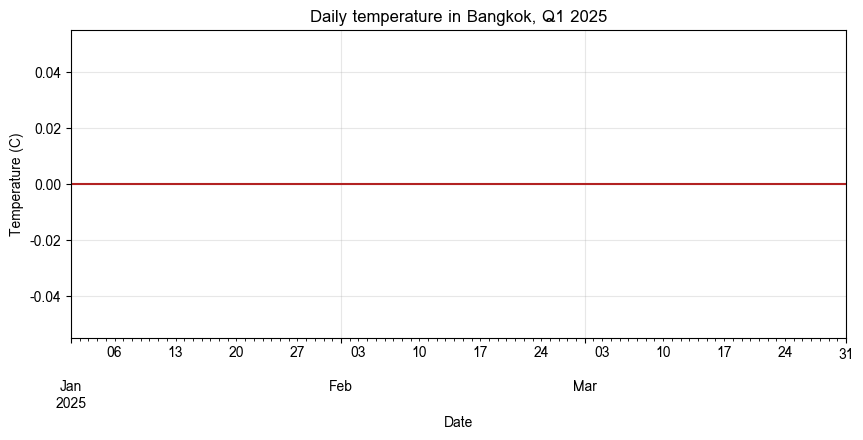

In [219]:
import matplotlib.pyplot as plt
import seaborn as sns

# แนวปฏิบัติที่แนะนำคือสร้าง figure และ axes ขึ้นก่อน แล้วส่ง ax เข้าไปในคำสั่ง plot
bangkok = df[df["city"] == "Bangkok"].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
bangkok.plot(x="date", y="temperature_c", ax=ax, color="firebrick", legend=False)
ax.set_title("Daily temperature in Bangkok, Q1 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.grid(alpha=0.3)
plt.show()

### ตัวอย่างที่ 2 กราฟแท่งแนวตั้งและแนวนอน

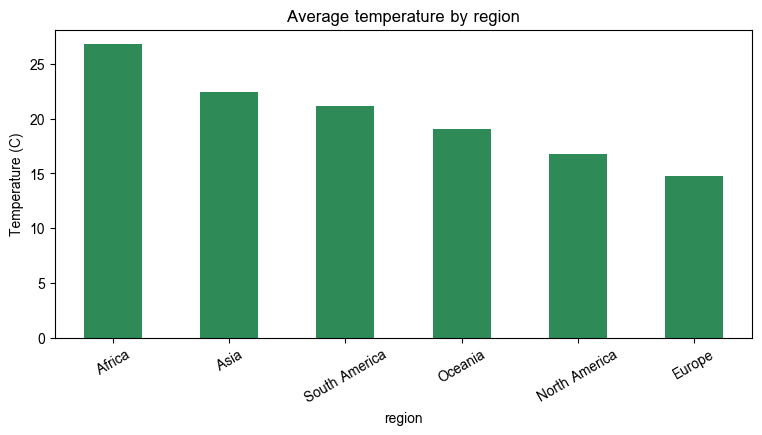

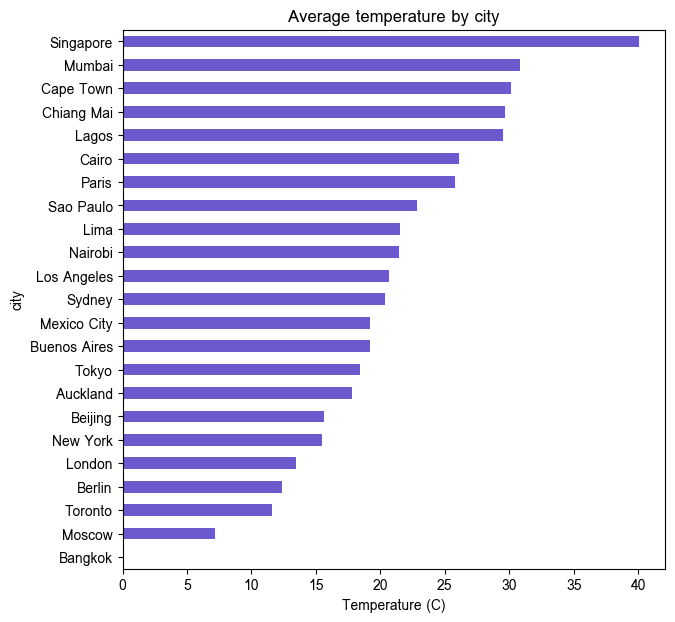

In [220]:
avg_by_region = df.groupby("region")["temperature_c"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
avg_by_region.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Average temperature by region")
ax.set_ylabel("Temperature (C)")
ax.tick_params(axis="x", rotation=30)
plt.show()

avg_by_city = df.groupby("city")["temperature_c"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
avg_by_city.plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Average temperature by city")
ax.set_xlabel("Temperature (C)")
plt.show()

### ตัวอย่างที่ 3 ฮิสโตแกรม กราฟจุด และ boxplot

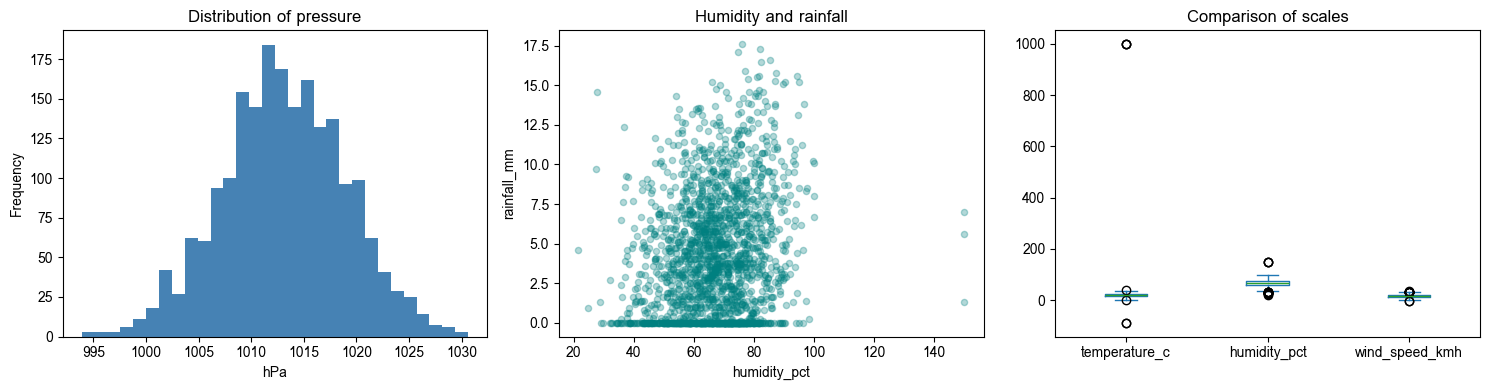

In [221]:
# การวางกราฟหลายรูปในภาพเดียว ให้สร้าง axes เป็นกริดแล้วส่งแต่ละช่องเข้าไปด้วยพารามิเตอร์ ax
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["pressure_hpa"].plot(kind="hist", bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of pressure")
axes[0].set_xlabel("hPa")

df.plot(kind="scatter", x="humidity_pct", y="rainfall_mm", alpha=0.3, ax=axes[1], color="teal")
axes[1].set_title("Humidity and rainfall")

df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].plot(kind="box", ax=axes[2])
axes[2].set_title("Comparison of scales")

plt.tight_layout()
plt.show()

### ตัวอย่างที่ 4 กราฟวงกลมและการนับสัดส่วน

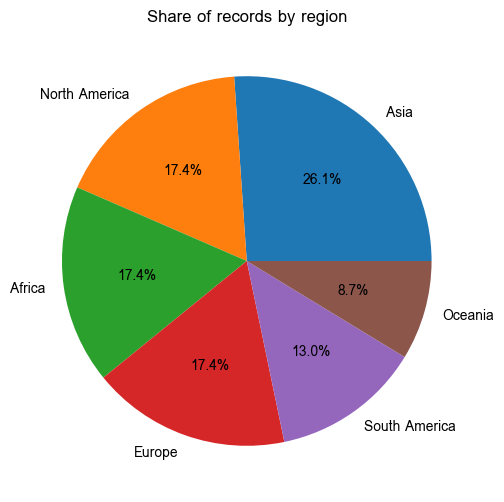

In [222]:
fig, ax = plt.subplots(figsize=(6, 6))
df["region"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%", ylabel="")
ax.set_title("Share of records by region")
plt.show()

### ตัวอย่างที่ 5 การวาดหลายคอลัมน์พร้อมกัน ด้วย `subplots` และ `secondary_y`

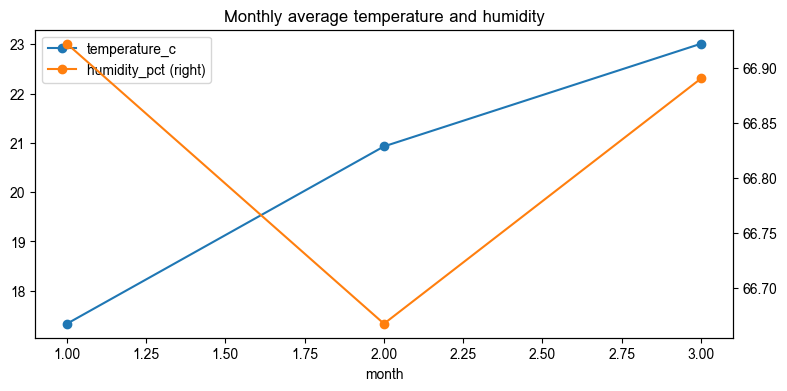

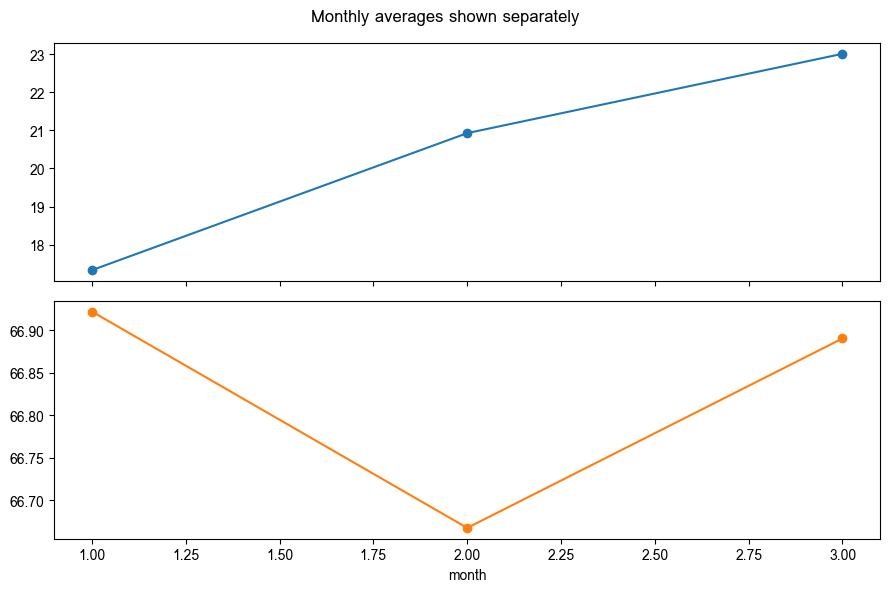

In [223]:
monthly = df.groupby("month")[["temperature_c", "humidity_pct"]].mean()

# secondary_y ใช้แกน y ด้านขวาสำหรับคอลัมน์ที่มีสเกลต่างกันมาก
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o", secondary_y="humidity_pct")
ax.set_title("Monthly average temperature and humidity")
plt.show()

# subplots=True แยกแต่ละคอลัมน์ออกเป็นกราฟย่อย
axes = monthly.plot(subplots=True, layout=(2, 1), figsize=(9, 6), marker="o", legend=False)
plt.suptitle("Monthly averages shown separately")
plt.tight_layout()
plt.show()

### ตัวอย่างที่ 6 กราฟแท่งซ้อนจากตารางไขว้

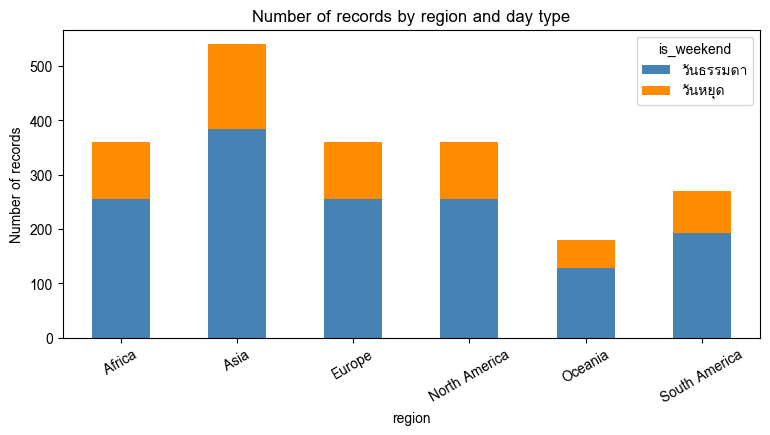

In [224]:
df["is_weekend"] = df["date"].dt.dayofweek >= 5
weekend_by_region = (df.groupby(["region", "is_weekend"]).size()
                       .unstack(fill_value=0)
                       .rename(columns={False: "วันธรรมดา", True: "วันหยุด"}))

fig, ax = plt.subplots(figsize=(9, 4))
weekend_by_region.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Number of records by region and day type")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=30)
plt.show()

### ตัวอย่างที่ 7 กราฟเชิงสถิติด้วย seaborn

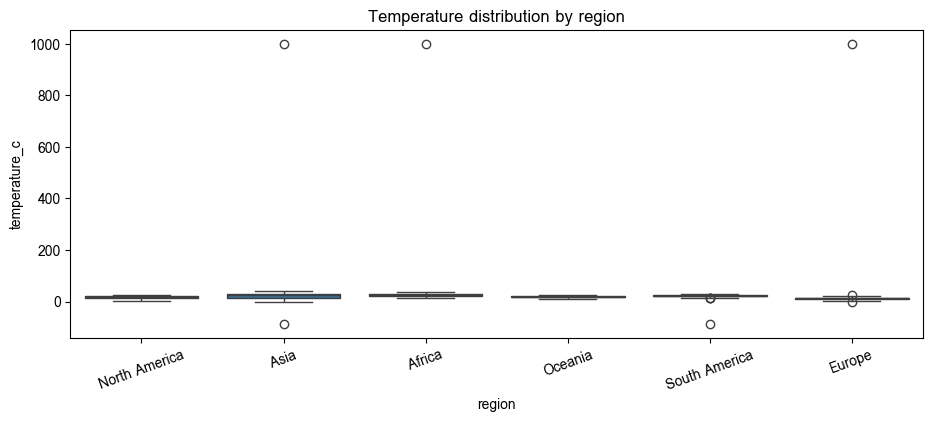

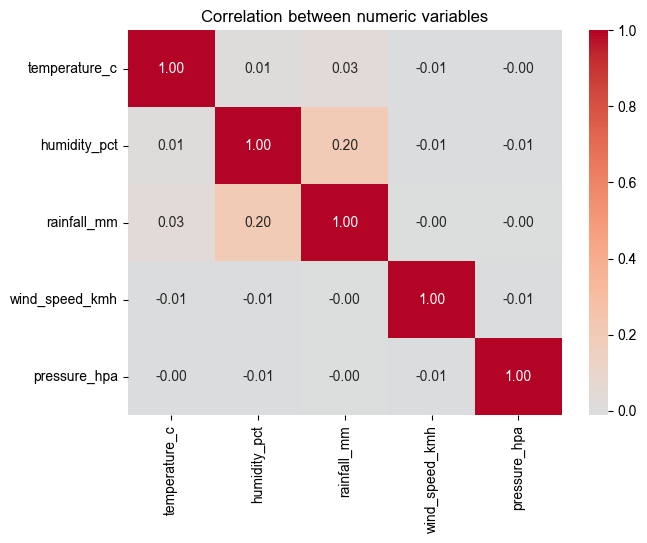

In [225]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df, x="region", y="temperature_c", ax=ax)
ax.set_title("Temperature distribution by region")
ax.tick_params(axis="x", rotation=20)
plt.show()

numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric variables")
plt.show()

### โจทย์ 17.1
สร้างกราฟสี่รูปจาก DataFrame โดยใช้ `.plot()` พร้อมกำหนดชื่อกราฟและชื่อแกนให้ครบทุกรูป

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน พร้อมคำอธิบายสัญลักษณ์
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
3. ฮิสโตแกรมของ `wind_speed_kmh` โดยทดลองกำหนด `bins` สามค่าที่ต่างกันและอธิบายผลของการเลือก `bins`
4. กราฟจุดระหว่าง `population_millions` กับอุณหภูมิเฉลี่ยรายเมือง

Line chart ใช้แสดงแนวโน้มอุณหภูมิตามเวลา

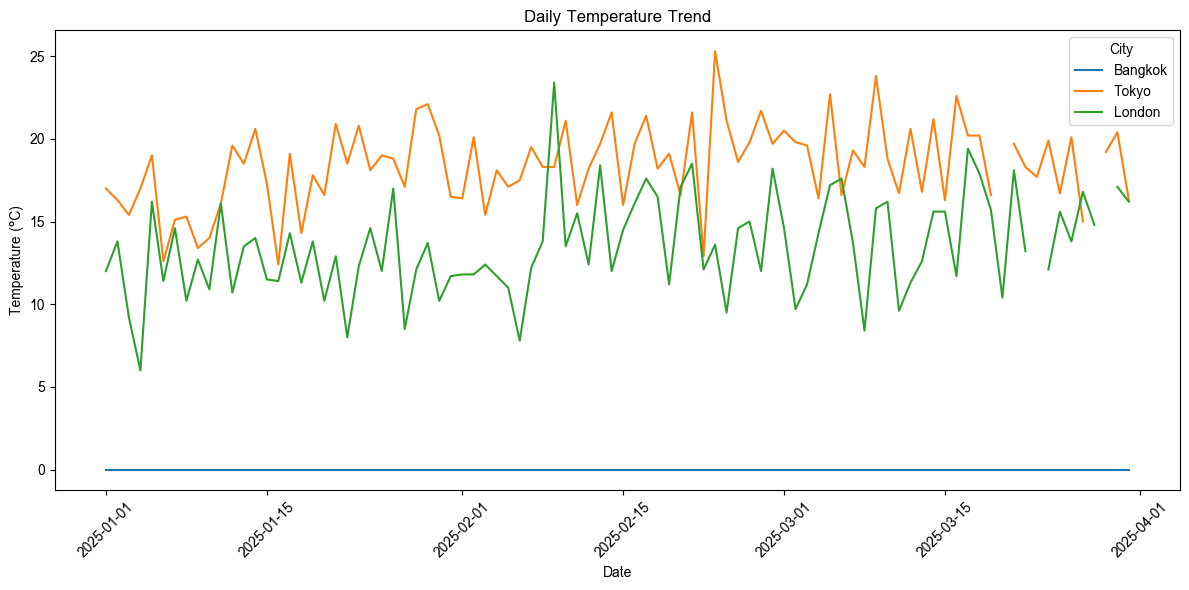

In [226]:
# คำตอบข้อ 17.1
selected_cities = ["Bangkok", "Tokyo", "London"]

line_data = (
    df[df["city"].isin(selected_cities)]
    .sort_values("date")
)

plt.figure(figsize=(12, 6))

for city in selected_cities:
    city_data = line_data[
        line_data["city"] == city
    ]

    plt.plot(
        city_data["date"],
        city_data["temperature_c"],
        label=city
    )

plt.title("Daily Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend(title="City")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Horizontal bar chart ใช้เปรียบเทียบปริมาณฝนรวมของแต่ละเมือง โดย Singapore มีค่าสูงที่สุด

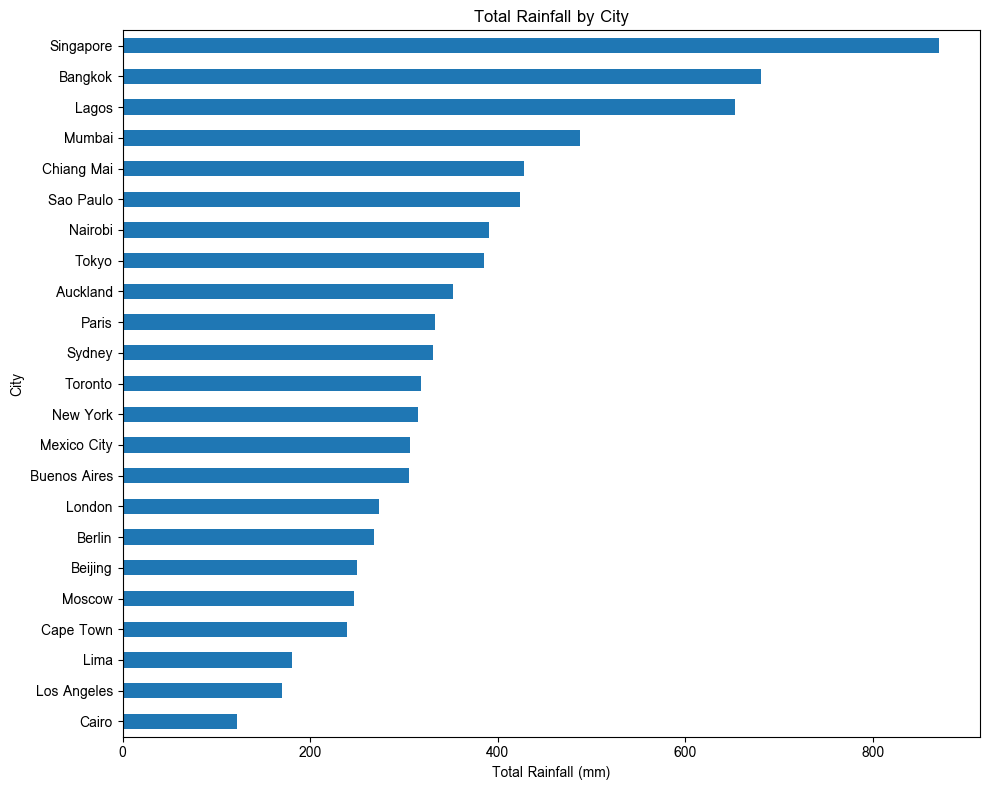

In [227]:
rain_city = (
    df.groupby("city")["rainfall_mm"]
      .sum()
      .sort_values()
)

plt.figure(figsize=(10, 8))

rain_city.plot(
    kind="barh"
)

plt.title("Total Rainfall by City")
plt.xlabel("Total Rainfall (mm)")
plt.ylabel("City")
plt.tight_layout()
plt.show()

Histogram ใช้แสดงการกระจายของ wind speed และจำนวน bins ที่ต่างกันจะทำให้รายละเอียดของ distribution แตกต่างกัน

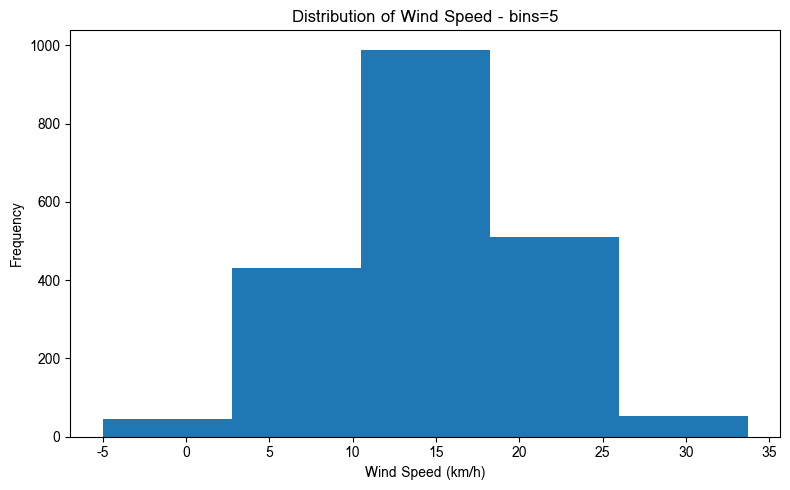

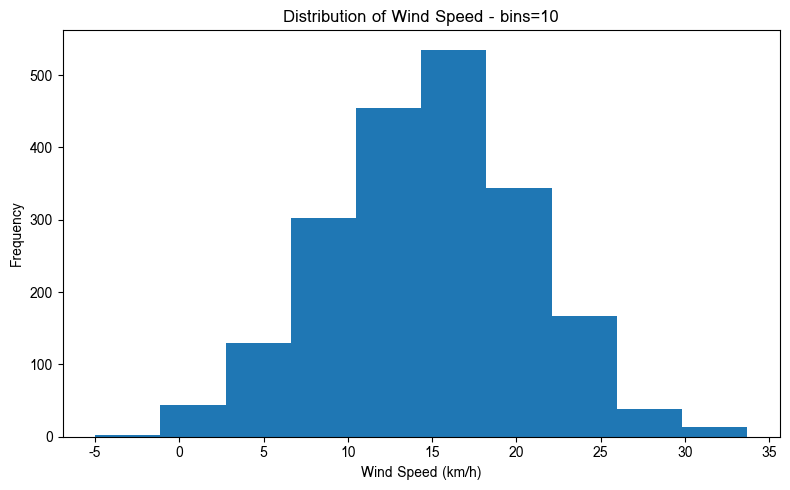

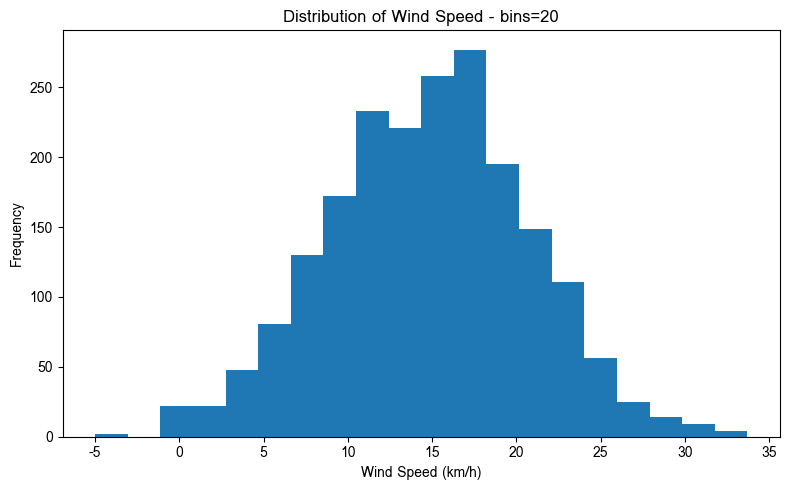

In [228]:
for bins in [5, 10, 20]:

    plt.figure(figsize=(8, 5))

    df["wind_speed_kmh"].plot(
        kind="hist",
        bins=bins
    )

    plt.title(
        f"Distribution of Wind Speed - bins={bins}"
    )

    plt.xlabel("Wind Speed (km/h)")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

Scatter plot ใช้ดูความสัมพันธ์ระหว่าง population และ average temperature

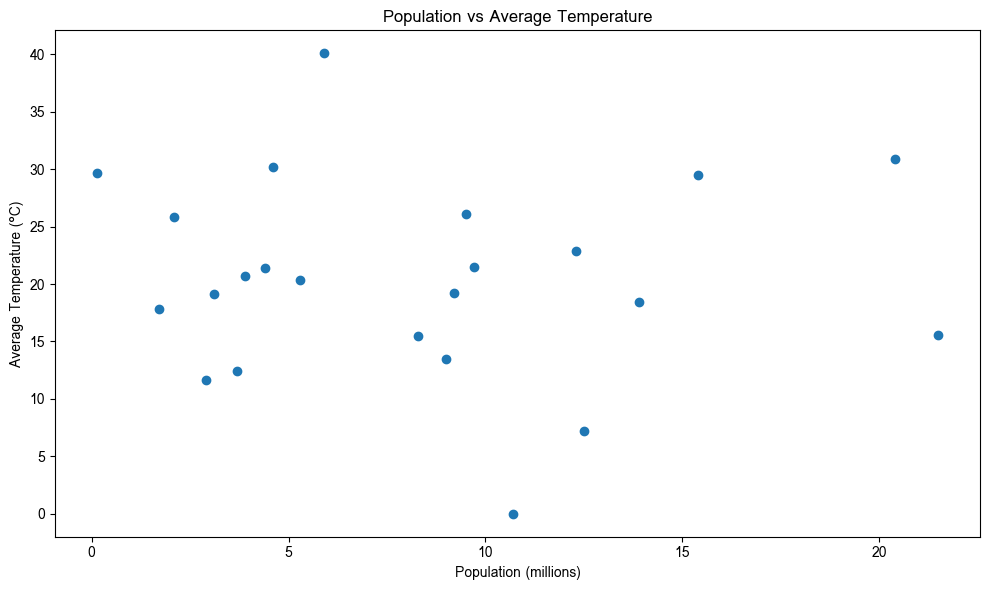

In [229]:
city_plot = (
    df.groupby("city")
      .agg(
          population_millions=(
              "city",
              lambda x: np.nan
          )
      )
)

# นำ population จาก city_info
city_temp = (
    df.groupby("city")["temperature_c"]
      .mean()
      .reset_index(name="avg_temp")
)

city_population = city_info[
    ["city", "population_millions"]
]

scatter_data = city_temp.merge(
    city_population,
    on="city",
    how="left"
)

plt.figure(figsize=(10, 6))

plt.scatter(
    scatter_data["population_millions"],
    scatter_data["avg_temp"]
)

plt.title("Population vs Average Temperature")
plt.xlabel("Population (millions)")
plt.ylabel("Average Temperature (°C)")
plt.tight_layout()
plt.show()

#### ตอบข้อ 17.1
visualization แต่ละประเภทเหมาะกับคำถามต่างกัน ได้แก่ trend, comparison, distribution และ relationship

### โจทย์ 17.2
นำผลลัพธ์ของโจทย์ 17.1 มาจัดวางในภาพเดียวกันด้วย `plt.subplots(2, 2)` พร้อมกำหนดชื่อรวมของภาพด้วย `plt.suptitle()`

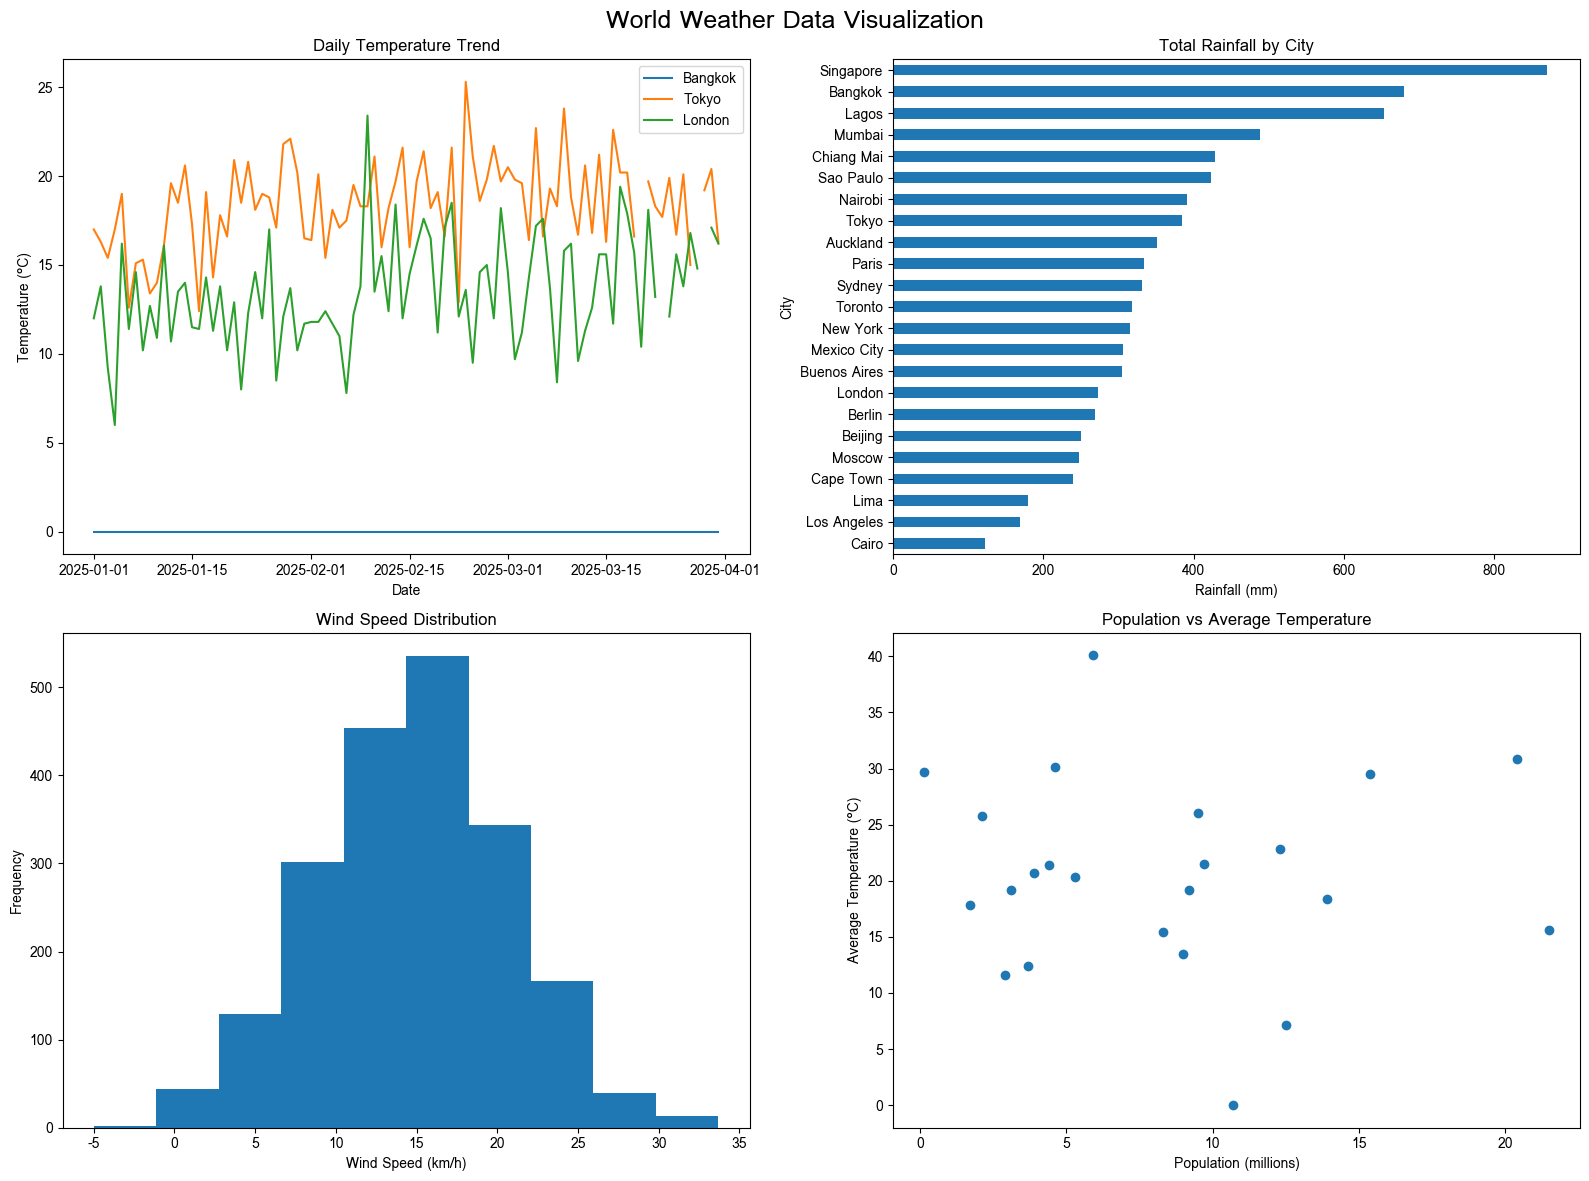

In [230]:
# คำตอบข้อ 17.2
fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 12)
)

# 1 Line
for city in selected_cities:
    city_data = line_data[
        line_data["city"] == city
    ]

    axes[0, 0].plot(
        city_data["date"],
        city_data["temperature_c"],
        label=city
    )

axes[0, 0].set_title("Daily Temperature Trend")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Temperature (°C)")
axes[0, 0].legend()

# 2 Bar
rain_city.plot(
    kind="barh",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Total Rainfall by City")
axes[0, 1].set_xlabel("Rainfall (mm)")
axes[0, 1].set_ylabel("City")

# 3 Histogram
df["wind_speed_kmh"].plot(
    kind="hist",
    bins=10,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Wind Speed Distribution")
axes[1, 0].set_xlabel("Wind Speed (km/h)")
axes[1, 0].set_ylabel("Frequency")

# 4 Scatter
axes[1, 1].scatter(
    scatter_data["population_millions"],
    scatter_data["avg_temp"]
)

axes[1, 1].set_title(
    "Population vs Average Temperature"
)
axes[1, 1].set_xlabel("Population (millions)")
axes[1, 1].set_ylabel("Average Temperature (°C)")

plt.suptitle(
    "World Weather Data Visualization",
    fontsize=18
)

plt.tight_layout()
plt.show()

#### ตอบข้อ 17.2
เมื่อนำกราฟทั้ง 4 มารวมในรูปแบบ 2×2 จะสามารถดูข้อมูลทั้งแนวโน้ม การเปรียบเทียบ การกระจาย และความสัมพันธ์ได้ในภาพเดียว

สรุป: subplots ช่วยรวบรวมหลาย visualization ไว้ในภาพเดียว เหมาะสำหรับการนำเสนอภาพรวมของข้อมูล

### โจทย์ 17.3
สร้างกราฟแท่งซ้อนแสดงจำนวนวันในแต่ละช่วงปริมาณฝน โดยแบ่งช่วงด้วย `pd.cut()` และจำแนกตามภูมิภาค
จากนั้นสร้างกราฟแบบ `stacked=False` เปรียบเทียบ
**อธิบาย:** กราฟแท่งซ้อนเหมาะสมกว่าในกรณีใด และกราฟแท่งเรียงข้างกันเหมาะสมกว่าในกรณีใด

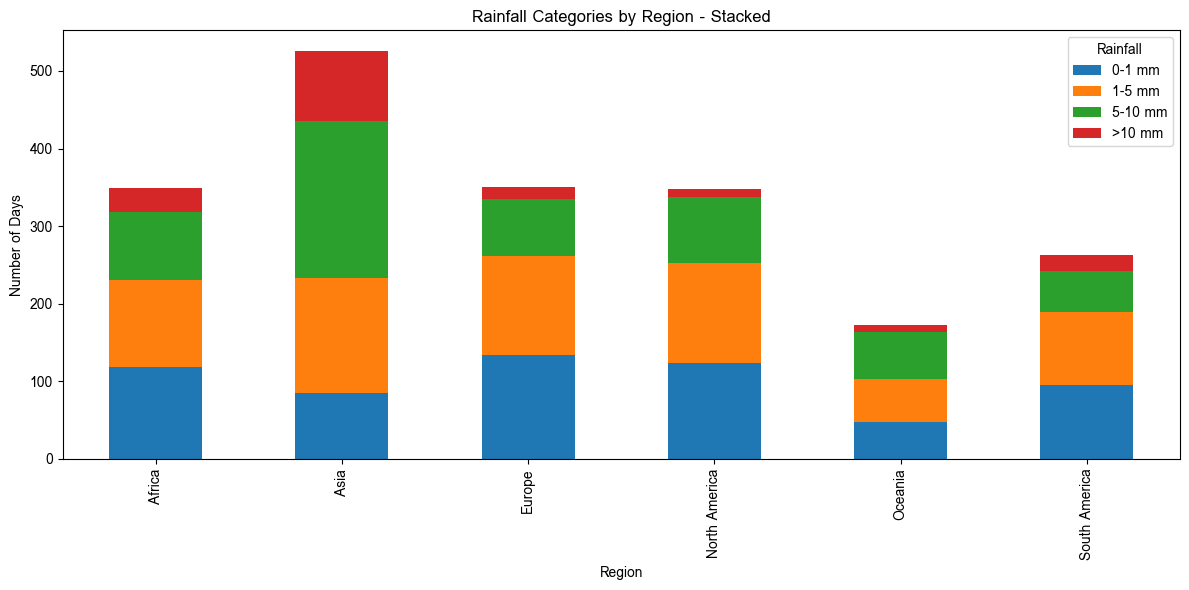

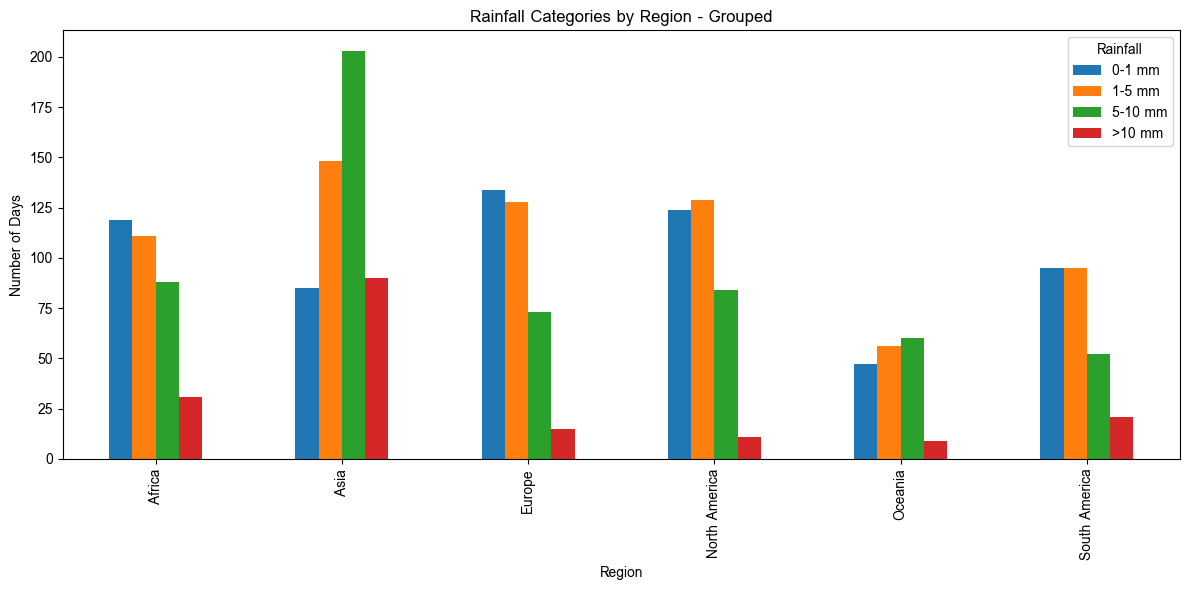

In [231]:
# คำตอบข้อ 17.3
rain_bins = [-0.01, 1, 5, 10, np.inf]

rain_labels = [
    "0-1 mm",
    "1-5 mm",
    "5-10 mm",
    ">10 mm"
]

df["rain_group"] = pd.cut(
    df["rainfall_mm"],
    bins=rain_bins,
    labels=rain_labels
)

rain_region = pd.crosstab(
    df["region"],
    df["rain_group"]
)

# Stacked
rain_region.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Rainfall Categories by Region - Stacked")
plt.xlabel("Region")
plt.ylabel("Number of Days")
plt.legend(title="Rainfall")
plt.tight_layout()
plt.show()


# Side-by-side
rain_region.plot(
    kind="bar",
    stacked=False,
    figsize=(12, 6)
)

plt.title("Rainfall Categories by Region - Grouped")
plt.xlabel("Region")
plt.ylabel("Number of Days")
plt.legend(title="Rainfall")
plt.tight_layout()
plt.show()

#### ตอบข้อ 17.3
Stacked bar เหมาะสำหรับดูทั้งจำนวนรวมและองค์ประกอบของแต่ละกลุ่มในเวลาเดียวกัน

Grouped bar เหมาะสำหรับเปรียบเทียบแต่ละ category ระหว่าง region โดยตรง

สรุป: หากต้องการเห็นองค์ประกอบรวมควรใช้ stacked bar แต่ถ้าต้องการเปรียบเทียบแต่ละ category ควรใช้ grouped bar

### โจทย์ 17.4
สร้างกราฟด้วย seaborn สองรูป ได้แก่ boxplot ของ `rainfall_mm` จำแนกตามภูมิภาคและแยกสีตาม `is_weekend`
และ heatmap ของสหสัมพันธ์ระหว่าง `temperature_c`, `humidity_pct`, `rainfall_mm` และ `population_millions`
พร้อมตีความผลที่ได้เป็นข้อความ

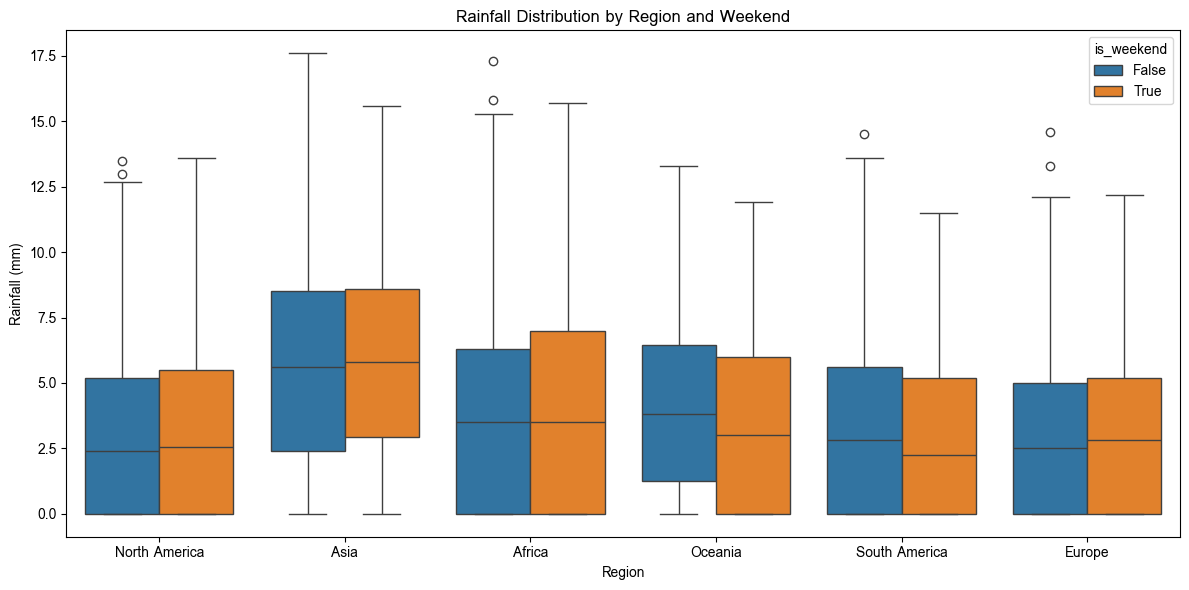

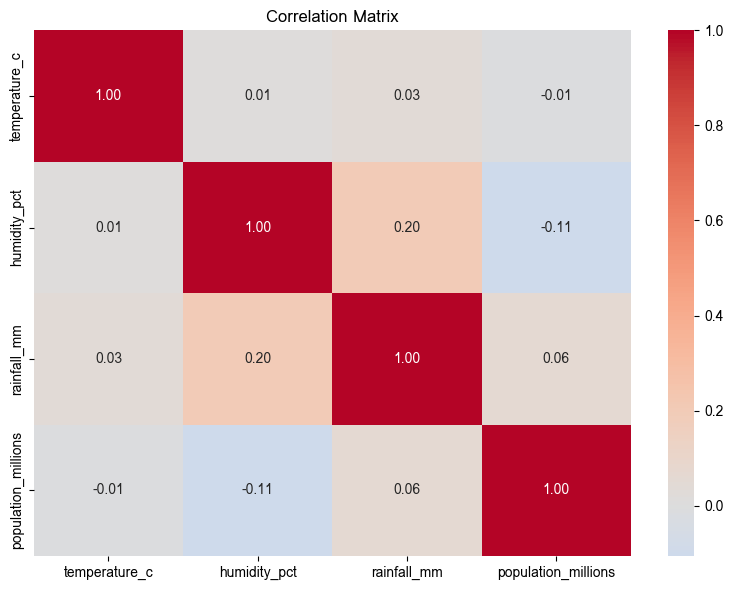

                     temperature_c  humidity_pct  rainfall_mm  \
temperature_c                 1.00          0.01         0.03   
humidity_pct                  0.01          1.00         0.20   
rainfall_mm                   0.03          0.20         1.00   
population_millions          -0.01         -0.11         0.06   

                     population_millions  
temperature_c                      -0.01  
humidity_pct                       -0.11  
rainfall_mm                         0.06  
population_millions                 1.00  


In [232]:
# คำตอบข้อ 17.4
# สร้าง is_weekend หากยังไม่มี
df["is_weekend"] = df["date"].dt.dayofweek >= 5

# Boxplot
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="region",
    y="rainfall_mm",
    hue="is_weekend"
)

plt.title(
    "Rainfall Distribution by Region and Weekend"
)

plt.xlabel("Region")
plt.ylabel("Rainfall (mm)")
plt.tight_layout()
plt.show()


# Heatmap correlation
corr_cols = [
    "temperature_c",
    "humidity_pct",
    "rainfall_mm",
    "population_millions"
]

heatmap_data = (
    df.merge(
        city_info[
            ["city", "population_millions"]
        ],
        on="city",
        how="left"
    )
)

corr = heatmap_data[corr_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

print(corr.round(2))

#### ตอบข้อ 17.4
Boxplot ช่วยเปรียบเทียบการกระจายของ rainfall ระหว่าง region และแยกตาม weekend/weekday รวมถึงช่วยตรวจสอบ outlier

Correlation พบว่า

Temperature กับ Humidity ≈ 0.01
Temperature กับ Rainfall ≈ 0.03
Humidity กับ Rainfall ≈ 0.20
Population กับ Temperature ≈ -0.01
Population กับ Rainfall ≈ 0.06

สรุป: ความสัมพันธ์ระหว่างตัวแปรส่วนใหญ่ค่อนข้างต่ำ โดยเฉพาะ population กับ temperature และ rainfall จึงยังไม่พบความสัมพันธ์เชิงเส้นที่ชัดเจน

---
## ข้อ 18 โจทย์ประยุกต์รวม

ให้ใช้ตารางที่รวมข้อมูลจากทั้ง 3 แหล่งและผ่านการทำความสะอาดแล้ว ตอบคำถามต่อไปนี้
แต่ละข้อต้องประกอบด้วย **ตารางหรือกราฟหนึ่งชิ้น** และ **ข้อสรุปเป็นข้อความสั้น ๆ**

**ข้อกำหนดเพิ่มเติม**

- ให้เขียนโปรแกรมในรูปแบบลำดับต่อเนื่องที่อ่านเข้าใจได้ ไม่ใช้ตัวแปรชั่วคราวจำนวนมากโดยไม่จำเป็น
- ห้ามใช้การวนซ้ำทีละแถว
- หากข้อสรุปขึ้นอยู่กับวิธีจัดการค่าว่างหรือค่าผิดปกติ ให้ระบุวิธีที่เลือกใช้ไว้ด้วย

1. ภูมิภาคใดมีสภาพอากาศแปรปรวนมากที่สุดในไตรมาสแรก เมื่อวัดจากส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวัน
   และความแปรปรวนดังกล่าวเกิดจากทุกเมืองในภูมิภาคนั้นเท่ากันหรือเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

In [233]:
# รวมข้อมูล
final_df = (
    df
    .merge(
        city_info,
        on="city",
        how="left",
        suffixes=("", "_city")
    )
    .merge(
        region_info,
        on="region",
        how="left",
        suffixes=("", "_region")
    )
)

# ตรวจสอบข้อมูล
print(final_df.shape)
print(final_df.head())

(2070, 33)
   record_id       date         city       country         region  \
0        983 2025-03-24     New York           USA  North America   
1        220 2025-02-09        Tokyo         Japan           Asia   
2       1022 2025-02-01  Los Angeles           USA  North America   
3        469 2025-01-19       Mumbai         India           Asia   
4       1834 2025-02-03    Cape Town  South Africa         Africa   

   temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa  \
0           15.7          72.6          6.3            15.9        1005.4   
1           18.3          60.6          0.0            20.5        1015.1   
2           20.6          46.8          1.2             8.6        1013.5   
3           31.0          73.4          8.0            11.8        1000.1   
4           19.1          55.0          0.0            16.6        1015.1   

   ... region_code  heat_index_apply  heat_index_vectorized  rain_group  \
0  ...          NA             22.96

=== ความแปรปรวนรายภูมิภาค ===
region
Europe           52.544961
Africa           52.122025
Asia             43.985154
South America     7.356485
North America     4.521662
Oceania           3.078532
Name: temperature_sd, dtype: float64

ภูมิภาคที่แปรปรวนมากที่สุด: Europe

SD รายเมืองในภูมิภาคดังกล่าว:
city
Paris     104.373645
London      3.018131
Moscow      2.877271
Berlin      2.595986
Name: temperature_c, dtype: float64


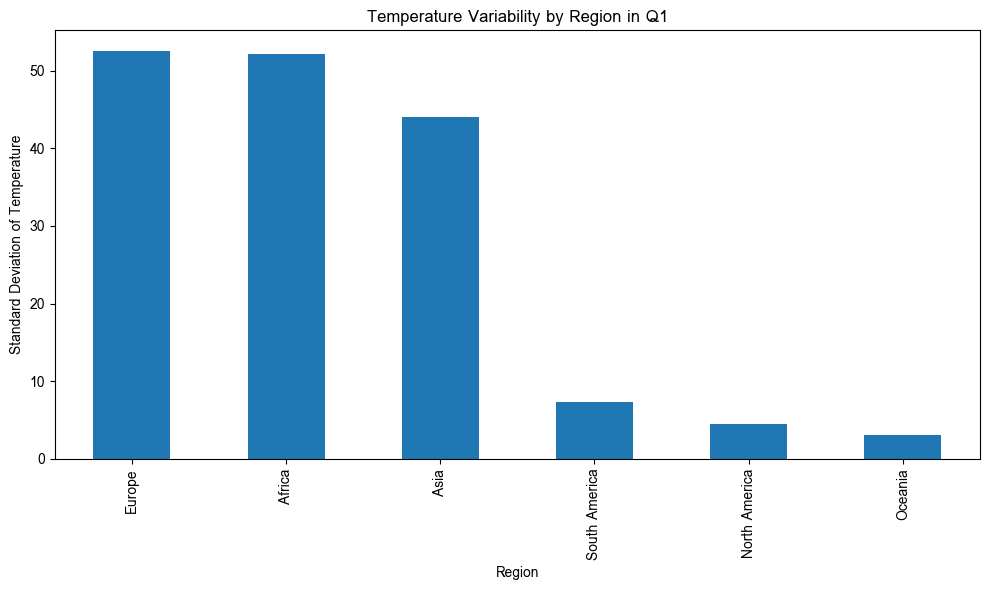

In [234]:
# คำตอบข้อ 18.1
q18_1 = final_df.copy()

# เลือกไตรมาสแรก
q18_1["month"] = q18_1["date"].dt.month

q1 = q18_1[
    q18_1["month"].between(1, 3)
]

# SD ของอุณหภูมิรายวันตาม region
region_sd = (
    q1.groupby("region")["temperature_c"]
      .std()
      .sort_values(ascending=False)
      .rename("temperature_sd")
)

print("=== ความแปรปรวนรายภูมิภาค ===")
print(region_sd)

# ภูมิภาคที่ SD สูงสุด
top_region = region_sd.idxmax()

print("\nภูมิภาคที่แปรปรวนมากที่สุด:",
      top_region)

# ตรวจสอบว่าเกิดจากเมืองใด
city_sd_in_region = (
    q1[q1["region"] == top_region]
    .groupby("city")["temperature_c"]
    .std()
    .sort_values(ascending=False)
)

print("\nSD รายเมืองในภูมิภาคดังกล่าว:")
print(city_sd_in_region)

# กราฟ
region_sd.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Temperature Variability by Region in Q1"
)

plt.xlabel("Region")
plt.ylabel("Standard Deviation of Temperature")
plt.tight_layout()
plt.show()

#### ตอบข้อ 18.1
ผล SD แสดงว่า Europe มีความแปรปรวนสูงที่สุดประมาณ 52.54 รองลงมาคือ Africa 52.12 และ Asia 43.99

อย่างไรก็ตาม เมื่อดูรายเมืองพบว่า Paris มี SD สูงถึงประมาณ 104.37 ขณะที่เมืองอื่นใน Europe เช่น London, Moscow และ Berlin มี SD ต่ำกว่ามาก

สรุป: ความแปรปรวนสูงของ Europe ไม่ได้เกิดจากทุกเมือง แต่เกิดจาก Paris เป็นหลัก และมีสาเหตุสำคัญจากค่าผิดปกติ 999°C ดังนั้นไม่ควรตีความว่า Europe มีสภาพอากาศจริงแปรปรวนในระดับดังกล่าว

2. เมืองที่มีฝนตกหนักบ่อยที่สุด 5 อันดับแรกเมื่อวัดด้วยสัดส่วน ให้เปรียบเทียบกับผลที่ได้เมื่อวัดด้วยจำนวนวัน
   และอธิบายว่าเหตุใดจึงให้ผลต่างกัน

In [235]:
# คำตอบข้อ 18.2
heavy_city = (
    final_df.groupby("city")
    .agg(
        heavy_days=(
            "rainfall_mm",
            lambda x: (x > 10).sum()
        ),
        observed_days=(
            "rainfall_mm",
            "count"
        )
    )
)

heavy_city["heavy_share"] = (
    heavy_city["heavy_days"]
    / heavy_city["observed_days"]
)

print("=== Top 5 ตามสัดส่วน ===")
top_share = heavy_city.sort_values(
    "heavy_share",
    ascending=False
).head(5)

print(top_share)

print("\n=== Top 5 ตามจำนวนวัน ===")
top_count = heavy_city.sort_values(
    "heavy_days",
    ascending=False
).head(5)

print(top_count)

# เปรียบเทียบรายชื่อ
comparison = pd.DataFrame({
    "rank_by_share": top_share.index,
    "rank_by_count": top_count.index
})

print("\n=== เปรียบเทียบ ===")
print(comparison)

=== Top 5 ตามสัดส่วน ===
            heavy_days  observed_days  heavy_share
city                                              
Singapore           44             90     0.488889
Bangkok             23             87     0.264368
Lagos               22             88     0.250000
Sao Paulo           11             88     0.125000
Chiang Mai           9             85     0.105882

=== Top 5 ตามจำนวนวัน ===
            heavy_days  observed_days  heavy_share
city                                              
Singapore           44             90     0.488889
Bangkok             23             87     0.264368
Lagos               22             88     0.250000
Sao Paulo           11             88     0.125000
Chiang Mai           9             85     0.105882

=== เปรียบเทียบ ===
  rank_by_share rank_by_count
0     Singapore     Singapore
1       Bangkok       Bangkok
2         Lagos         Lagos
3     Sao Paulo     Sao Paulo
4    Chiang Mai    Chiang Mai


#### ตอบข้อ 18.2
เมื่อใช้เกณฑ์ rainfall มากกว่า 10 mm เมืองที่มีสัดส่วนวันฝนหนักสูงสุด 5 อันดับ ได้แก่

Singapore = 48.89%
Bangkok = 26.44%
Lagos = 25.00%
Sao Paulo = 12.50%
Chiang Mai = 10.59%

ผลการจัดอันดับตามจำนวนวันและตามสัดส่วนให้ผลเหมือนกันในชุดข้อมูลนี้

สรุป: Singapore มีความถี่ของวันฝนหนักสูงที่สุด และหากต้องการเปรียบเทียบเมืองที่มีจำนวนข้อมูลแตกต่างกัน ควรใช้สัดส่วนมากกว่าจำนวนวัน

3. จำนวนประชากรของเมืองมีความสัมพันธ์กับอุณหภูมิหรือปริมาณฝนหรือไม่
   ให้คำนวณค่าสหสัมพันธ์ประกอบ พร้อมระบุข้อควรระวังในการตีความอย่างน้อยหนึ่งประการ

                     population_millions  temperature_c  rainfall_mm
population_millions             1.000000      -0.013440     0.061099
temperature_c                  -0.013440       1.000000     0.032908
rainfall_mm                     0.061099       0.032908     1.000000

Population vs Temperature: -0.013
Population vs Rainfall: 0.061


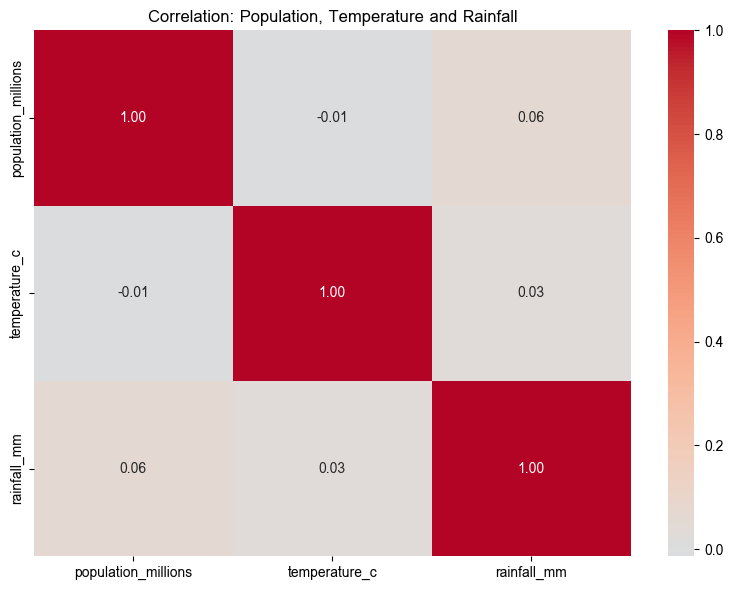

In [236]:
# คำตอบข้อ 18.3
corr_data = final_df[
    [
        "population_millions",
        "temperature_c",
        "rainfall_mm"
    ]
].corr()

print(corr_data)

print("\nPopulation vs Temperature:",
      round(
          corr_data.loc[
              "population_millions",
              "temperature_c"
          ],
          3
      ))

print("Population vs Rainfall:",
      round(
          corr_data.loc[
              "population_millions",
              "rainfall_mm"
          ],
          3
      ))

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation: Population, Temperature and Rainfall"
)

plt.tight_layout()
plt.show()

#### ตอบข้อ 18.3
Correlation ระหว่าง population กับ temperature เท่ากับประมาณ -0.013 และ population กับ rainfall เท่ากับประมาณ 0.061

ทั้งสองค่ามีค่าใกล้ศูนย์มาก

สรุป: จากข้อมูลชุดนี้ยังไม่พบความสัมพันธ์เชิงเส้นที่ชัดเจนระหว่างจำนวนประชากรกับอุณหภูมิหรือปริมาณฝน อย่างไรก็ตาม correlation ไม่ได้หมายถึงความสัมพันธ์เชิงเหตุและผล และจำนวนเมืองที่ใช้วิเคราะห์มีจำกัด จึงไม่ควรสรุปเชิงสาเหตุจากข้อมูลนี้เพียงอย่างเดียว

4. เดือนใดของแต่ละภูมิภาคที่ควรหลีกเลี่ยงการเดินทางมากที่สุด
   ให้กำหนดเกณฑ์การตัดสินใจจากข้อมูลที่มีอยู่ และอธิบายเหตุผลของการเลือกเกณฑ์ดังกล่าว

In [237]:
# คำตอบข้อ 18.4
travel_data = final_df.copy()

travel_data["month"] = travel_data["date"].dt.month

monthly_region = (
    travel_data
    .groupby(["region", "month"])
    .agg(
        avg_rain=("rainfall_mm", "mean"),
        heavy_rain_days=(
            "rainfall_mm",
            lambda x: (x > 10).sum()
        ),
        avg_temp=("temperature_c", "mean")
    )
    .reset_index()
)

# ทำคะแนนมาตรฐานเพื่อให้แต่ละตัวแปรเปรียบเทียบกันได้
monthly_region["rain_score"] = (
    monthly_region["avg_rain"]
    .rank(pct=True)
)

monthly_region["heavy_score"] = (
    monthly_region["heavy_rain_days"]
    .rank(pct=True)
)

monthly_region["travel_risk_score"] = (
    monthly_region["rain_score"]
    + monthly_region["heavy_score"]
) / 2

print(
    monthly_region.sort_values(
        "travel_risk_score",
        ascending=False
    )
)

# เดือนที่ควรหลีกเลี่ยงที่สุดของแต่ละภูมิภาค
avoid_month = (
    monthly_region
    .sort_values(
        ["region", "travel_risk_score"],
        ascending=[True, False]
    )
    .groupby("region")
    .head(1)
)

print("\n=== เดือนที่ควรหลีกเลี่ยง ===")
print(
    avoid_month[
        [
            "region",
            "month",
            "avg_rain",
            "heavy_rain_days",
            "avg_temp",
            "travel_risk_score"
        ]
    ]
)

           region  month  avg_rain  heavy_rain_days   avg_temp  rain_score  \
4            Asia      2  6.400000               38  21.283234    1.000000   
3            Asia      1  5.681319               29  18.993011    0.944444   
5            Asia      3  5.659669               23  27.045109    0.888889   
0          Africa      1  4.223333               12  22.641667    0.777778   
1          Africa      2  4.096364                9  32.741441    0.722222   
2          Africa      3  3.765546               10  25.414754    0.611111   
14        Oceania      3  4.376364                6  20.201613    0.833333   
16  South America      2  3.677778                7  22.102381    0.555556   
15  South America      1  3.335165                8  19.193478    0.333333   
17  South America      3  3.375824                6  22.292391    0.388889   
9   North America      1  3.518333                4  15.167480    0.444444   
12        Oceania      1  3.940984                1  17.362903  

#### ตอบข้อ 18.4
จาก travel risk score พบว่าเดือนที่ควรหลีกเลี่ยงในแต่ละภูมิภาคคือ

Africa → เดือน 1
Asia → เดือน 2
Europe → เดือน 3
North America → เดือน 1
Oceania → เดือน 3
South America → เดือน 2

Asia ในเดือน 2 มี risk score สูงที่สุดประมาณ 1.000 โดยมีฝนเฉลี่ยประมาณ 6.40 mm และมีวันฝนหนักจำนวนมาก

สรุป: เดือนที่ควรหลีกเลี่ยงแตกต่างกันตามภูมิภาค โดย Asia เดือน 2 มีความเสี่ยงจากสภาพอากาศสูงที่สุดตามเกณฑ์ที่กำหนดจากข้อมูลชุดนี้

# สรุปผลโดยรวม
ข้อมูลสภาพอากาศชุดนี้มีทั้งหมด 23 เมือง ครอบคลุม 90 วัน และหลังจัดการ duplicate แล้วมี 2,070 แถว

ผลการวิเคราะห์พบว่า Singapore มีปริมาณฝนรวมสูงที่สุด ขณะที่รูปแบบอุณหภูมิและฝนแตกต่างกันตามเมืองและภูมิภาค

อย่างไรก็ตาม พบค่าผิดปกติ เช่น `999°C และ -88°C` ซึ่งมีผลต่อค่าเฉลี่ย ส่วนเบี่ยงเบนมาตรฐาน และ z-score อย่างมาก ดังนั้นก่อนนำผลไปตีความเชิงสภาพอากาศจริง ควรทำความสะอาด anomaly และ missing values ให้เรียบร้อยก่อน

นอกจากนี้ การวิเคราะห์ยังแสดงให้เห็นว่า pandas สามารถใช้สำหรับ `data cleaning`, `filtering`, `grouping`, `aggregation`, `ranking`, `merging`, `reshaping` และ `visualization` ได้อย่างมีประสิทธิภาพ

---

<center>จบแล้ว ขอแสดงความยินดีกับทุกคน

<center>> เขียนเองหนึ่งบรรทัด ได้ความเข้าใจมากกว่าอ่านผ่านตาสิบบรรทัด
> One line you write yourself teaches more than ten you only read.

> คนที่จัดการข้อมูลสองพันแถวได้อย่างสะอาดหมดจด คือคนเดียวกับที่จะจัดการข้อมูลสองล้านแถวได้อย่างมั่นใจ
> Whoever handles two thousand rows with care will handle two million with confidence.

<center>❤️❤️❤️❤️❤️ Keep Learning ❤️❤️❤️❤️❤️